# Figure out what color space cuts can be used to remove the different spectral types, or rather how to separate them out from each other.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
#import scipy.interpolate as scinterp
import time

sys.path.append('../')
sys.path.append('/Users/BenKaiser/Desktop/radial_velocity_calculations/')

In [2]:
import cal_params as cp
import spec_plot_tools as spt

In [3]:
input_path='/Users/BenKaiser/Desktop/MORDOR_Survey_paper/MORDOR_Survey_forPaper/Goodman_spectra_copy/'
input_file='full_MORDOR_survey_1681141339_fullphotometry_fitparams_massadd.csv'
input_table=Table.read(input_path+input_file)

In [4]:
input_table.pprint()

       name       ...
----------------- ...
MORDOR J0008-2404 ...
  SDSS J0049+2244 ...
MORDOR J0110-5926 ...
MORDOR J0110-5600 ...
MORDOR J0126-4707 ...
  SDSS J0132+1823 ...
MORDOR J0135-6306 ...
       LEHPM 1774 ...
  LSPM J0211+0835 ...
MORDOR J0225-3312 ...
              ... ...
MORDOR J2126-7502 ...
MORDOR J2158+4243 ...
MORDOR J2236-3635 ...
MORDOR J2238-5558 ...
MORDOR J2244+4204 ...
  SDSS J2309+0959 ...
  SDSS J2314+2717 ...
MORDOR J2320-6637 ...
MORDOR J2324-5942 ...
MORDOR J2339+3728 ...
     WD J2356-209 ...
Length = 120 rows


In [5]:
def get_sp_type_table(sp_type=''):
    inds=np.where(input_table['sp_type']==sp_type)
    out_table=input_table[inds]
    return out_table

In [6]:
dc_table=get_sp_type_table(sp_type='DC')
wddm_table=get_sp_type_table(sp_type='WDdM')
dq_table=get_sp_type_table(sp_type='DQpec')
dz_table=get_sp_type_table(sp_type='DZ')
unknown_table=get_sp_type_table(sp_type='??')

In [7]:
table_list=[dc_table,wddm_table,dq_table,dz_table,unknown_table]
sp_type_list=['DC','WDdM','DQpec','DZ','??']

In [8]:
def get_mag(table,band,survey='ps1'):
    try:
        mags=table[survey+'_'+band+'_mag']
    except KeyError:
        mags=table[survey+'_'+band+'_mean_psf_mag']
    
    return mags

In [9]:
def plot_color_color(table,colorlist1,colorlist2,plot_color='k',label=''):
    """
    plot band1-band2 on x , band3-band4 on y
    colorlist1: [[band1,survey1],[band2,survey2]]
    colorlist2:[[band3,survey3],[band4,survey4]]
    """
    def get_color(colorlist):
        mag_list=[]
        for item in colorlist:
            mag=get_mag(table,item[0],survey=item[1])
            mag_list.append(mag)
        return mag_list
    mag_list1=get_color(colorlist1)
    mag_list2=get_color(colorlist2)
    plt.scatter(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],color=plot_color,label=label)
    #plt.annotate(str(table['name']),xy=(np.copy(mag_list1[0]-mag_list1[1]), np.copy(mag_list2[0]-mag_list2[1])), xycoords='data', xytext=(np.copy(mag_list1[0]-mag_list1[1]), np.copy(mag_list2[0]-mag_list2[1])), textcoords= 'data' , fontsize=8, color =plot_color)
    def make_axis_label(colorlist):
        axis_label=colorlist[0][1]+'_'+colorlist[0][0]+' - '+colorlist[1][1]+'_'+colorlist[1][0]
        return axis_label
    #for x,y,s in zip(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],table['name']):
        #plt.text(x,y,s,color=plot_color)
    #plt.text(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],table['name'],color=plot_color)
    stringx=make_axis_label(colorlist1)
    stringy=make_axis_label(colorlist2)
    plt.xlabel(stringx)
    plt.ylabel(stringy)

    
    return

## Based on testing of PanSTARRS color indices, it appears that i-y vs. r-i separates out the WD+dM binaries and the DQpecs/DZs. However, it is is redundant to have i on both axes, isn't it?

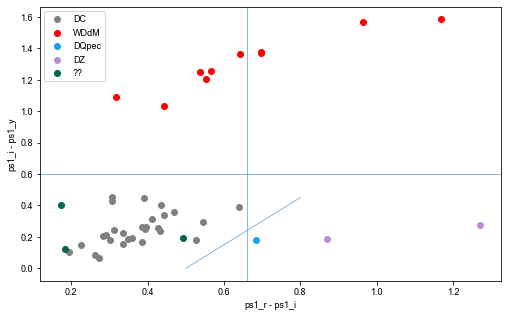

In [10]:
spt.start_mnras_fig(width_cols=2)
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.axvline(x=0.66)
plt.axhline(y=0.6)

plt.plot([0.5,0.8],[0.00,0.45])

plt.legend()
plt.show()

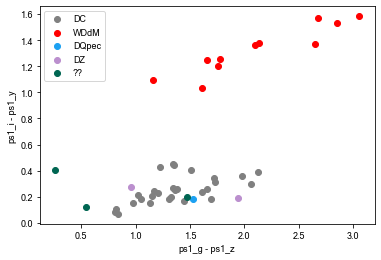

In [11]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['g','ps1'],['z','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

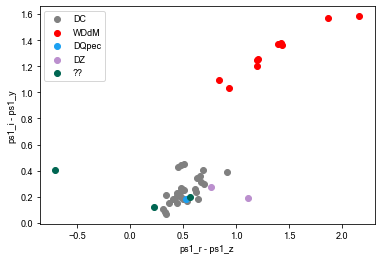

In [12]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['z','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

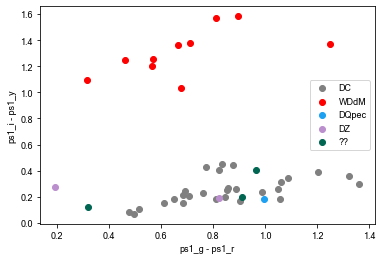

In [13]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['g','ps1'],['r','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

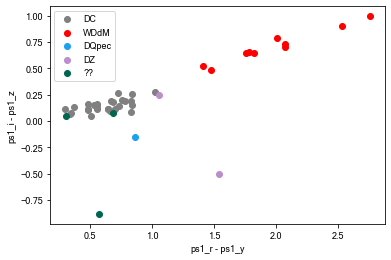

In [14]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['y','ps1']],[['i','ps1'],['z','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

## i-z would also work for separating out the WD+dM binaries, but they are closer to the DCs and other isolated white dwarfs


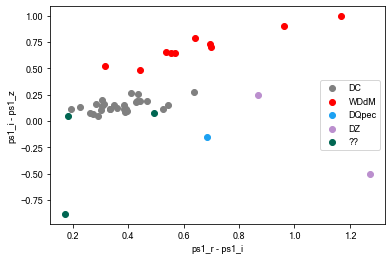

In [15]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['z','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

In [16]:
def make_super_list(survey,band_list):
    ps1_bandlist_list=[]
    ps1_band_list=band_list
    for band in ps1_band_list:
        ps1_bandlist_list.append([band,survey])
    print(ps1_bandlist_list)
    ps1_super_list=[]
    for thing in ps1_bandlist_list:
        for otherthing in ps1_bandlist_list:
            ps1_super_list.append([thing,otherthing])
    print(ps1_super_list)
    for thing in ps1_super_list:
        print(thing)
    return ps1_super_list

In [17]:
ps1_band_list=['g','r','i','z','y']
ps1_super_list=make_super_list('ps1',ps1_band_list)

[['g', 'ps1'], ['r', 'ps1'], ['i', 'ps1'], ['z', 'ps1'], ['y', 'ps1']]
[[['g', 'ps1'], ['g', 'ps1']], [['g', 'ps1'], ['r', 'ps1']], [['g', 'ps1'], ['i', 'ps1']], [['g', 'ps1'], ['z', 'ps1']], [['g', 'ps1'], ['y', 'ps1']], [['r', 'ps1'], ['g', 'ps1']], [['r', 'ps1'], ['r', 'ps1']], [['r', 'ps1'], ['i', 'ps1']], [['r', 'ps1'], ['z', 'ps1']], [['r', 'ps1'], ['y', 'ps1']], [['i', 'ps1'], ['g', 'ps1']], [['i', 'ps1'], ['r', 'ps1']], [['i', 'ps1'], ['i', 'ps1']], [['i', 'ps1'], ['z', 'ps1']], [['i', 'ps1'], ['y', 'ps1']], [['z', 'ps1'], ['g', 'ps1']], [['z', 'ps1'], ['r', 'ps1']], [['z', 'ps1'], ['i', 'ps1']], [['z', 'ps1'], ['z', 'ps1']], [['z', 'ps1'], ['y', 'ps1']], [['y', 'ps1'], ['g', 'ps1']], [['y', 'ps1'], ['r', 'ps1']], [['y', 'ps1'], ['i', 'ps1']], [['y', 'ps1'], ['z', 'ps1']], [['y', 'ps1'], ['y', 'ps1']]]
[['g', 'ps1'], ['g', 'ps1']]
[['g', 'ps1'], ['r', 'ps1']]
[['g', 'ps1'], ['i', 'ps1']]
[['g', 'ps1'], ['z', 'ps1']]
[['g', 'ps1'], ['y', 'ps1']]
[['r', 'ps1'], ['g', 'ps1']]
[['r

In [18]:
def plot_sp_types(colorlist1,colorlist2):
    for sp_type in sp_type_list:
        sp_type_table=get_sp_type_table(sp_type=sp_type)
        plot_color_color(sp_type_table,colorlist1,colorlist2,plot_color=cp.sp_type_colors[sp_type],label=sp_type)
    #plt.legend()
    plt.show()
    return

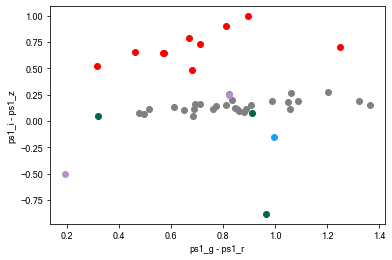

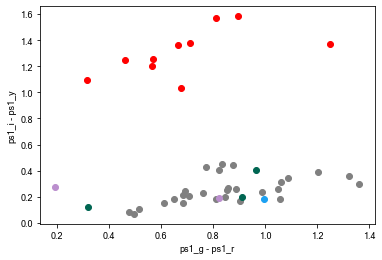

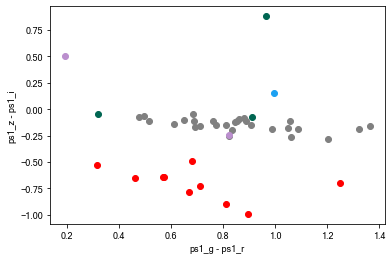

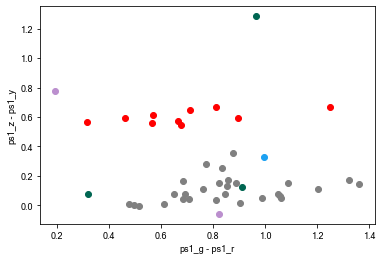

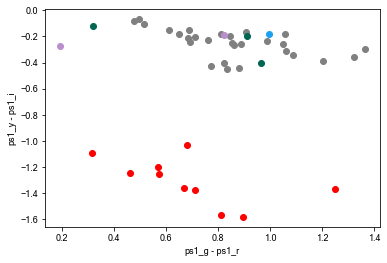

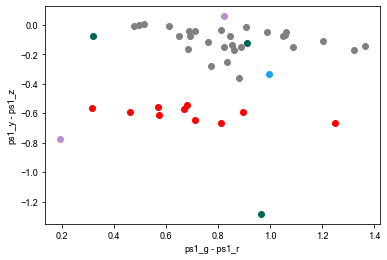

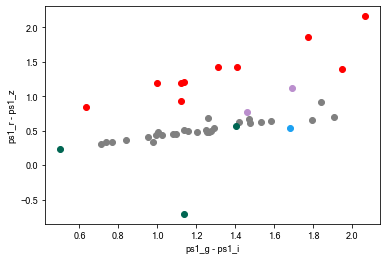

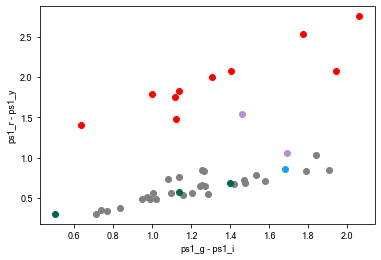

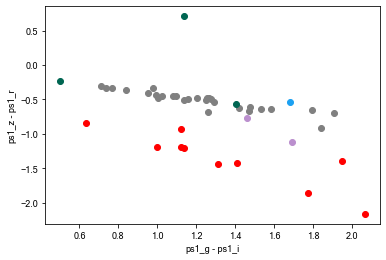

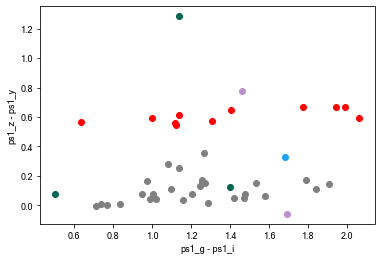

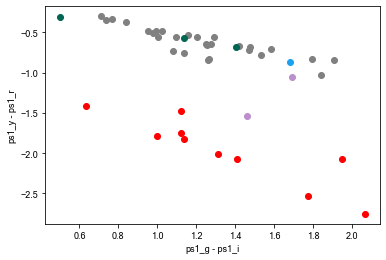

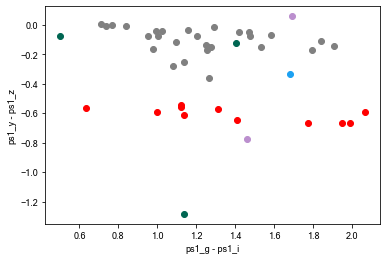

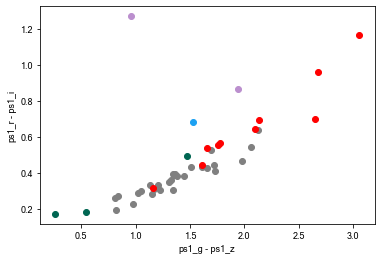

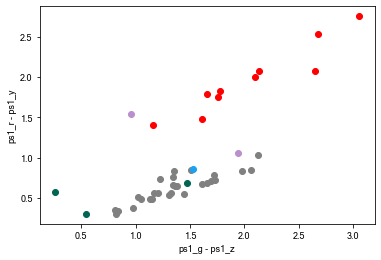

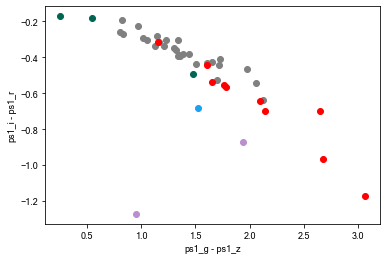

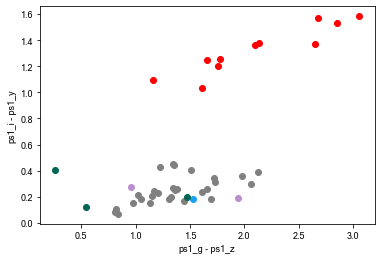

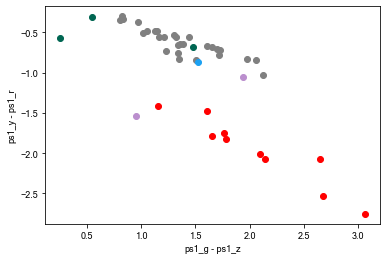

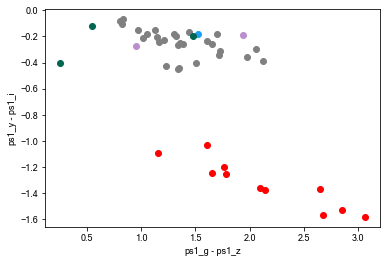

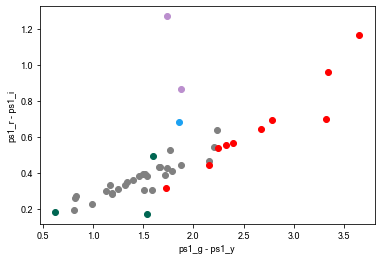

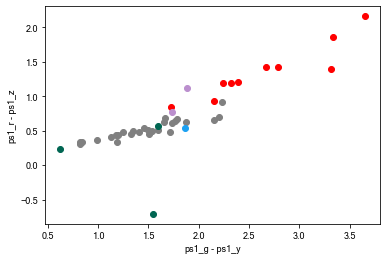

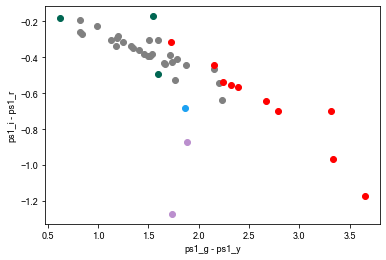

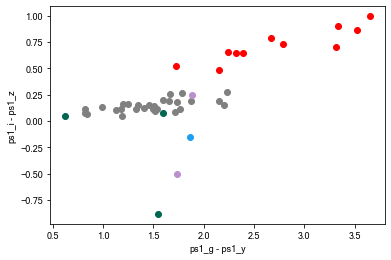

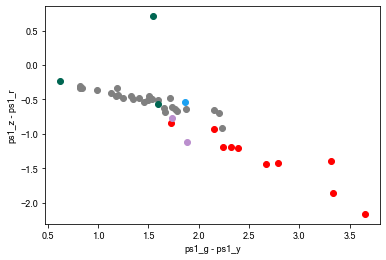

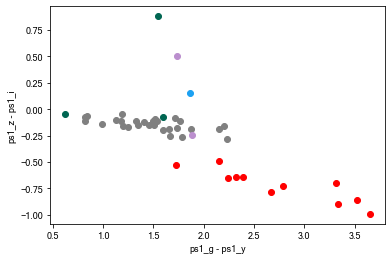

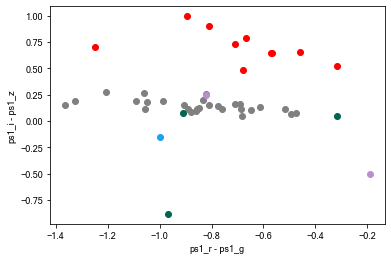

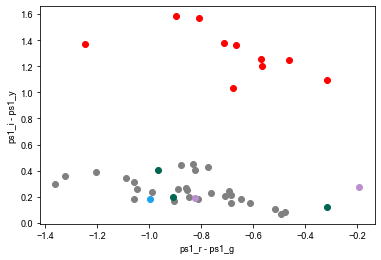

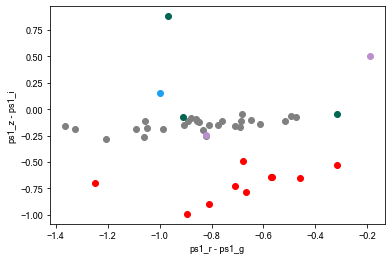

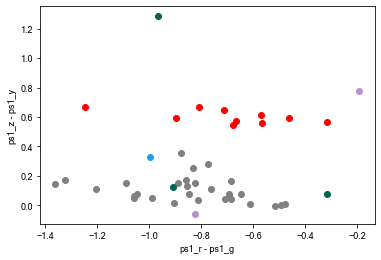

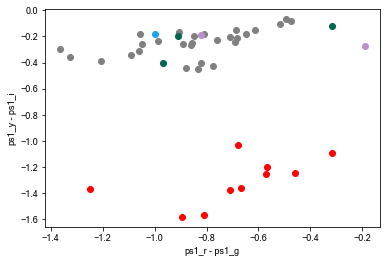

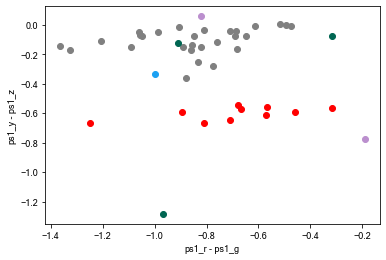

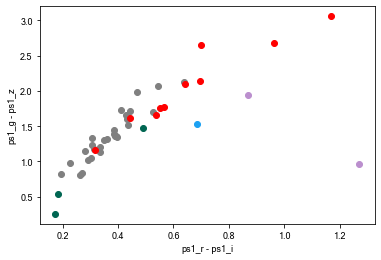

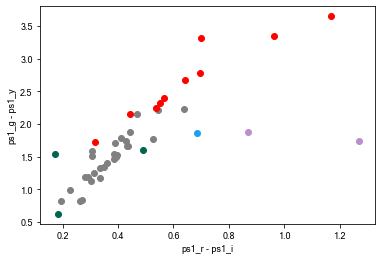

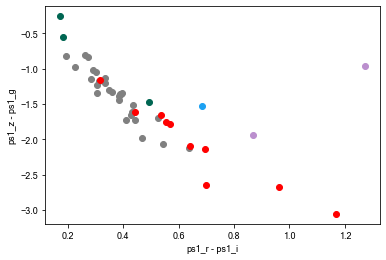

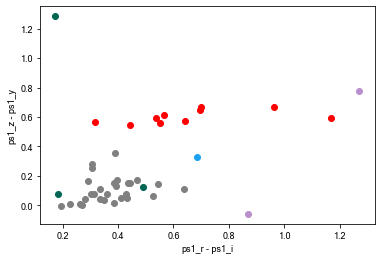

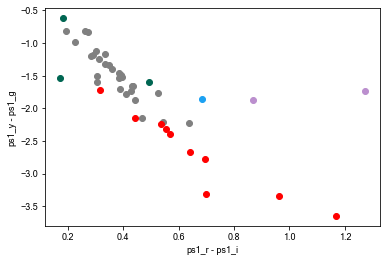

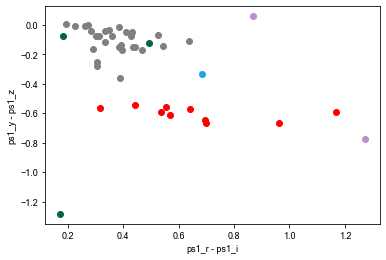

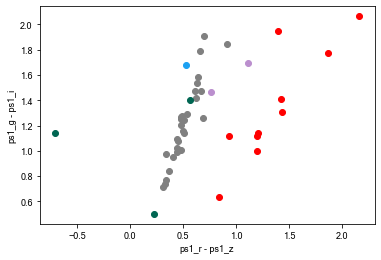

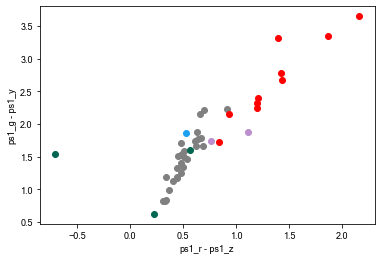

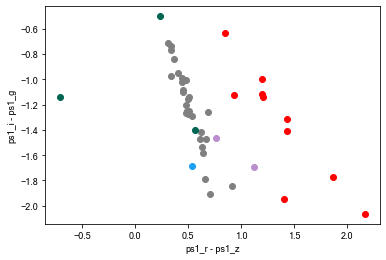

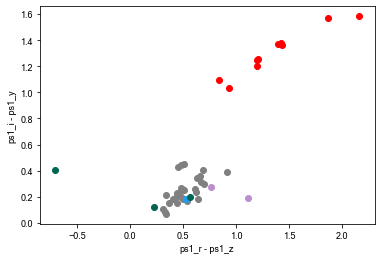

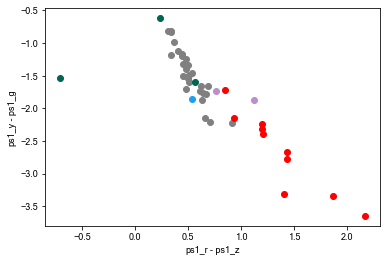

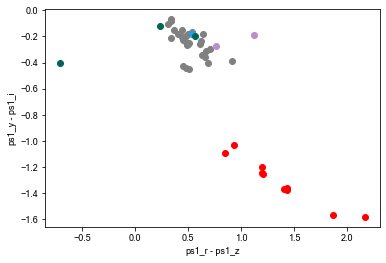

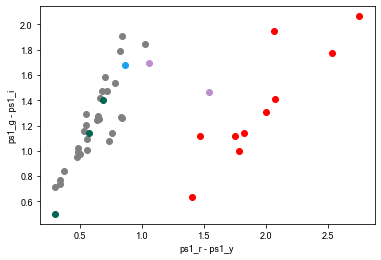

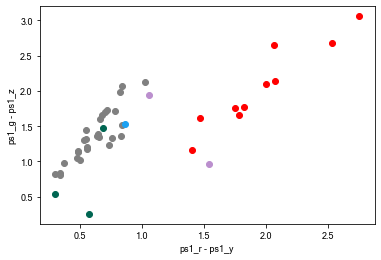

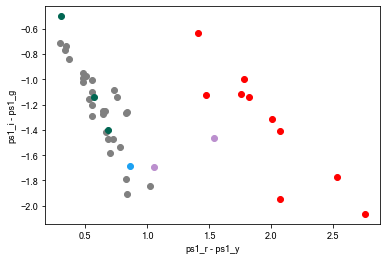

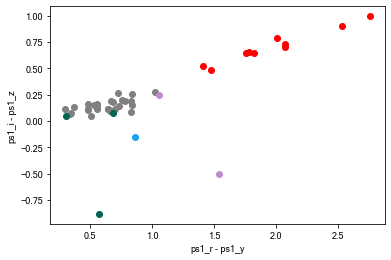

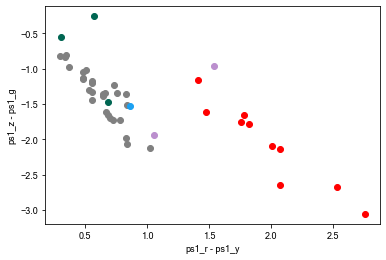

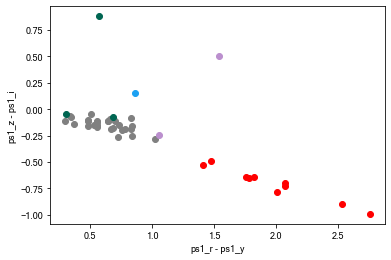

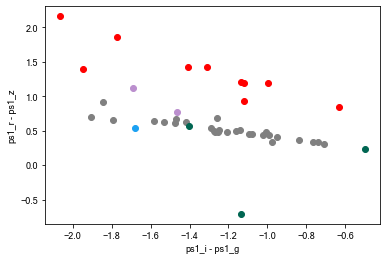

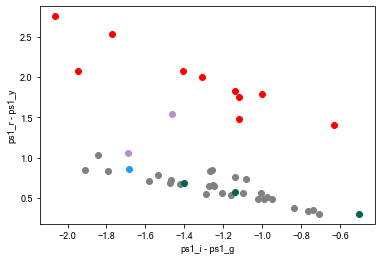

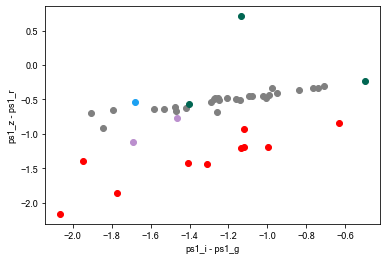

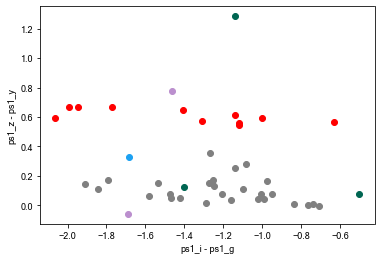

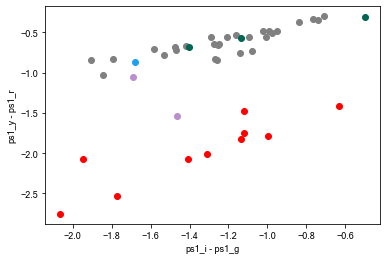

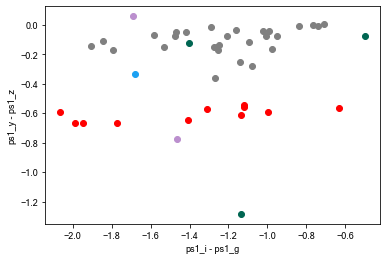

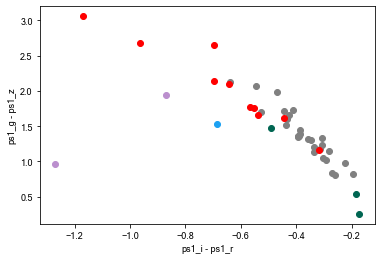

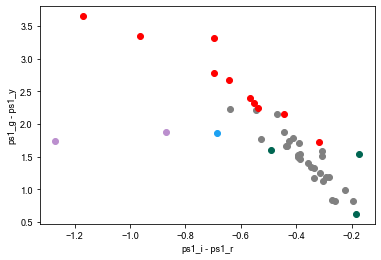

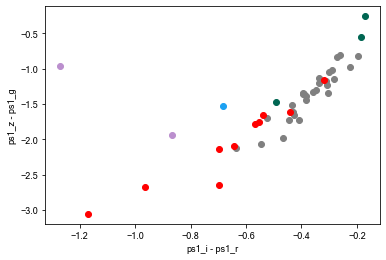

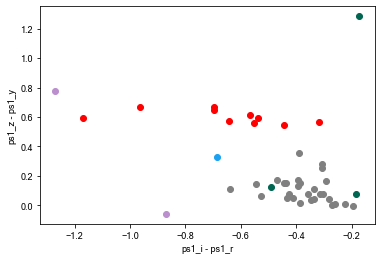

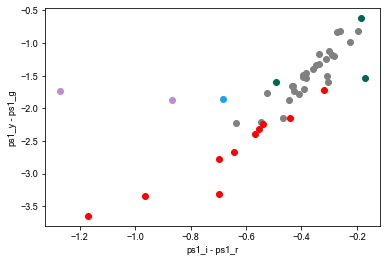

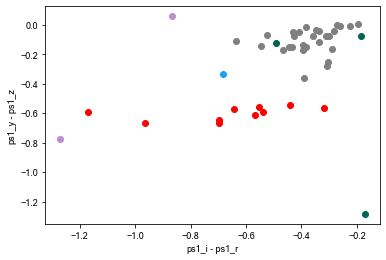

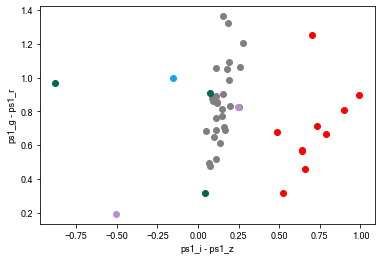

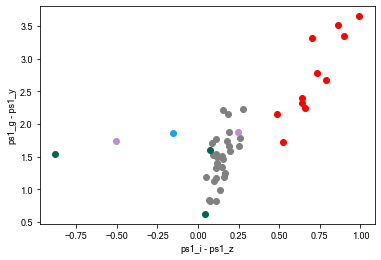

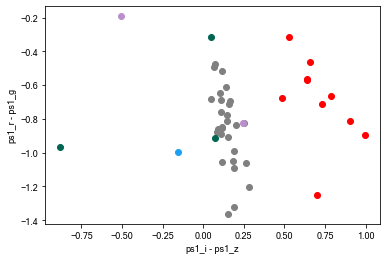

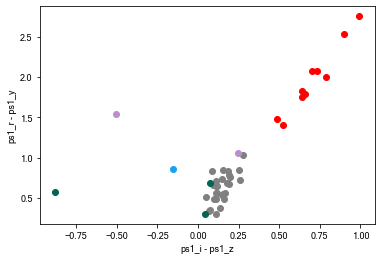

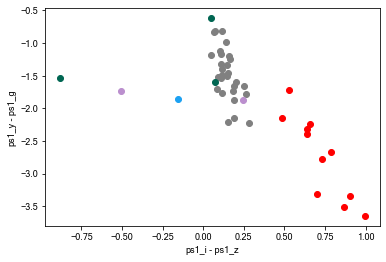

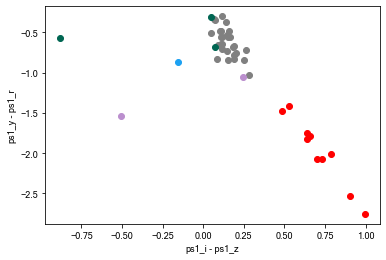

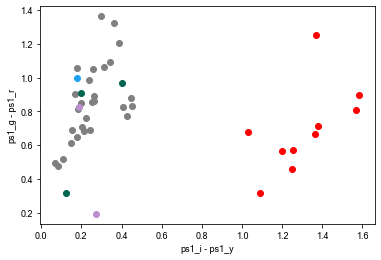

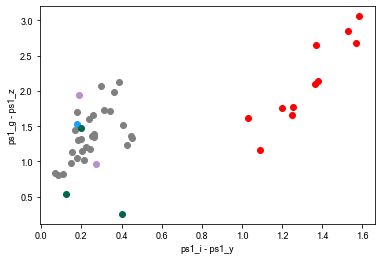

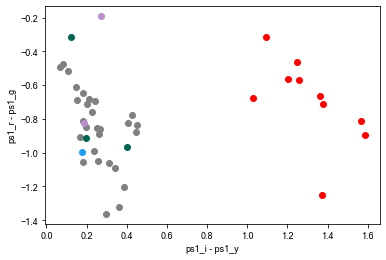

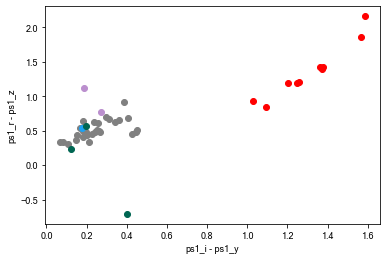

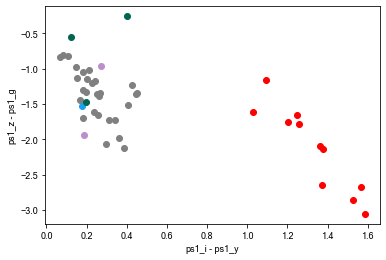

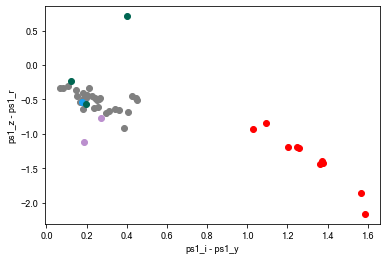

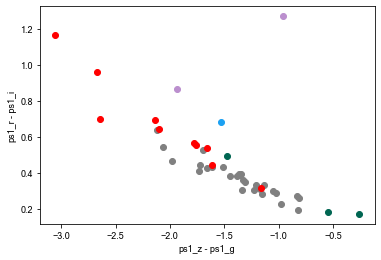

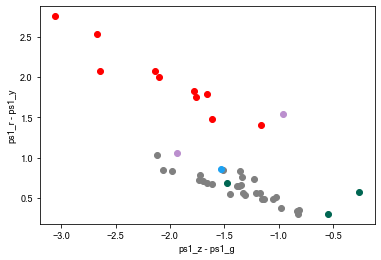

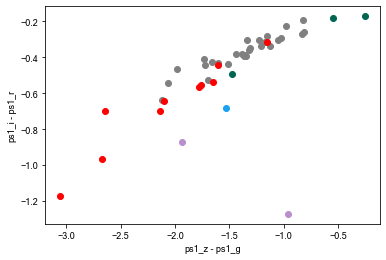

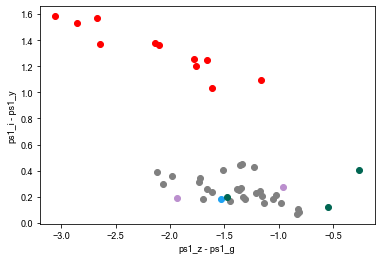

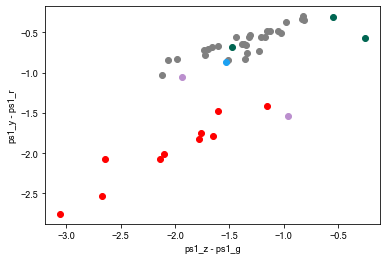

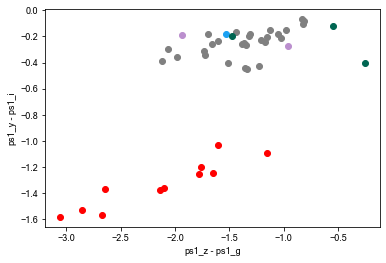

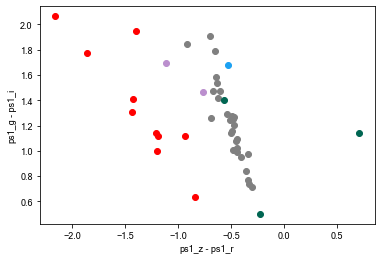

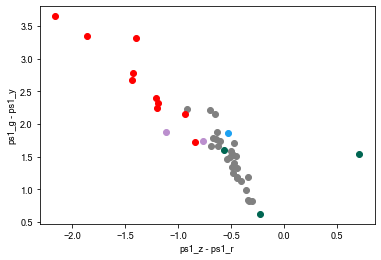

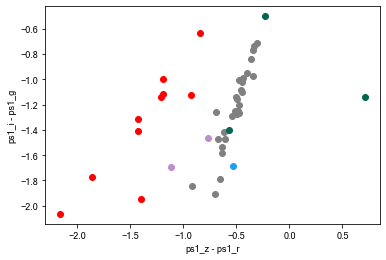

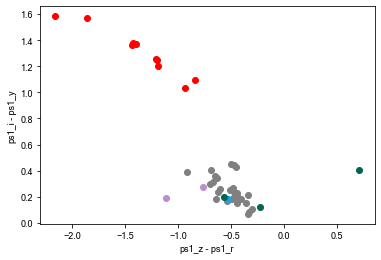

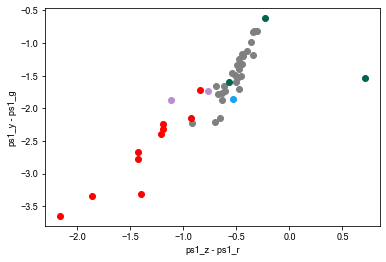

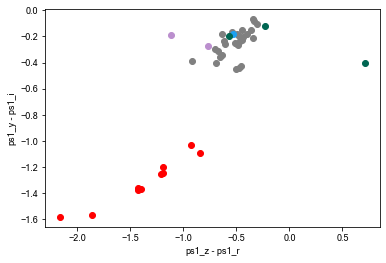

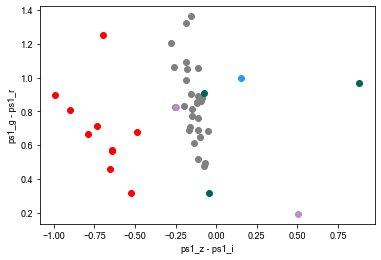

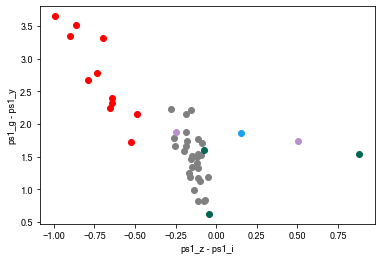

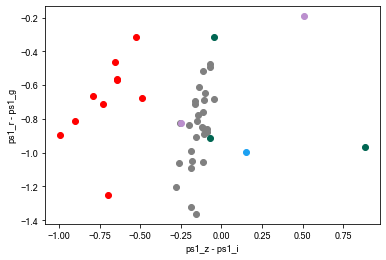

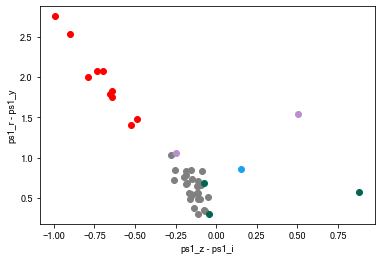

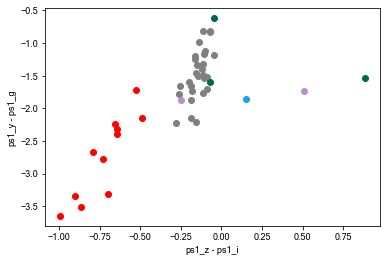

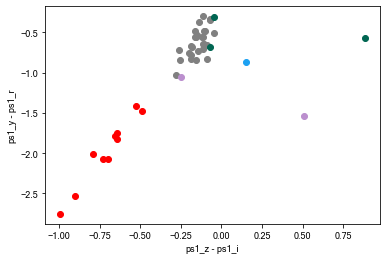

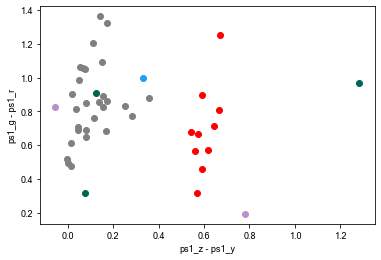

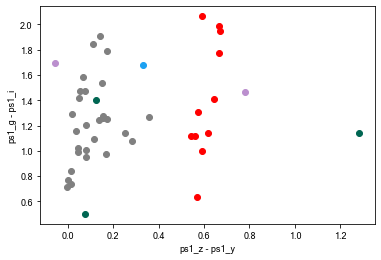

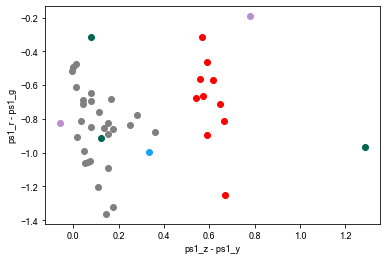

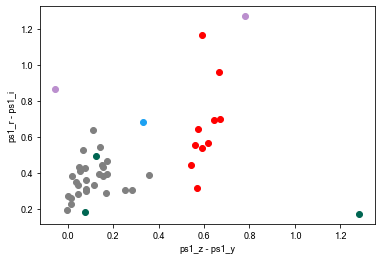

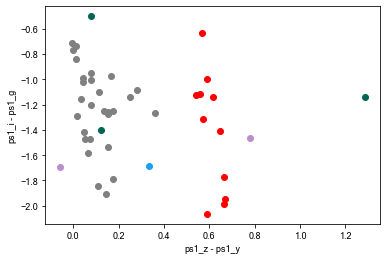

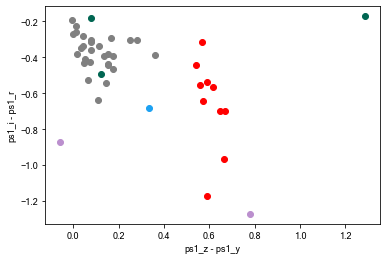

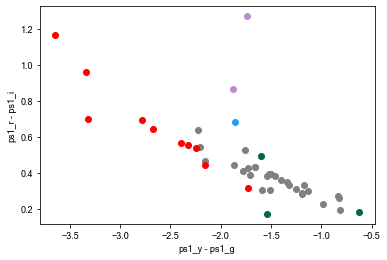

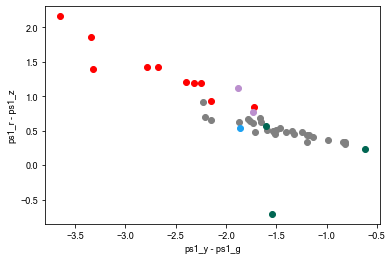

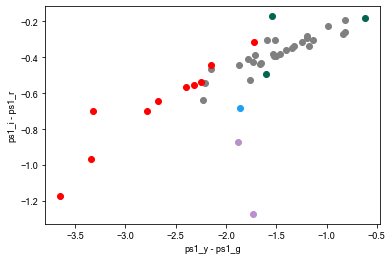

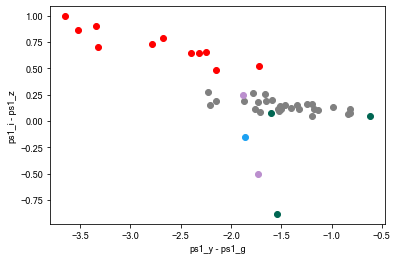

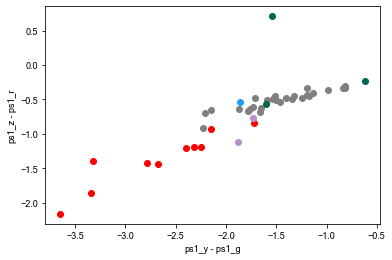

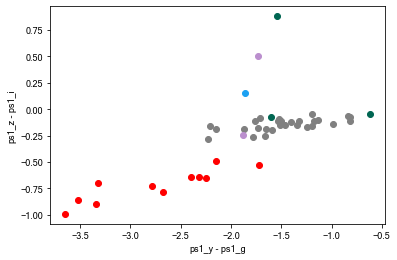

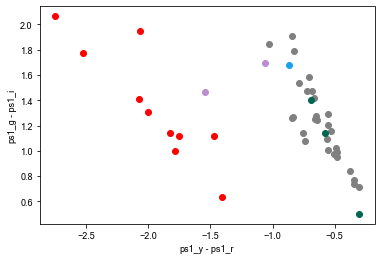

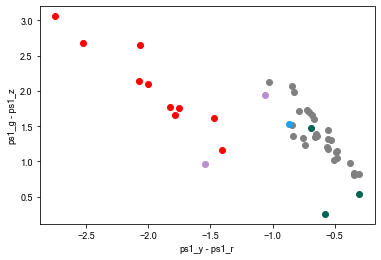

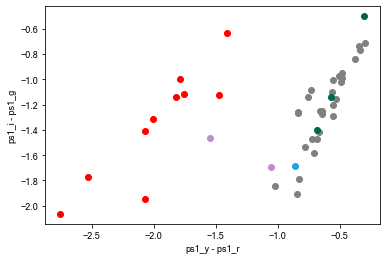

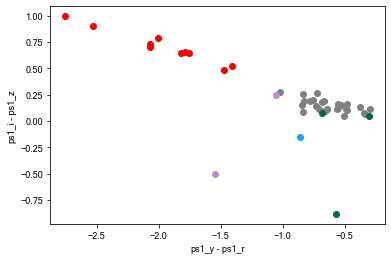

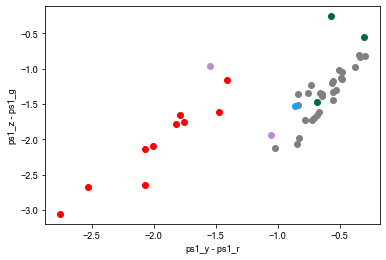

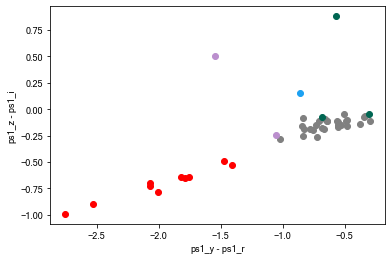

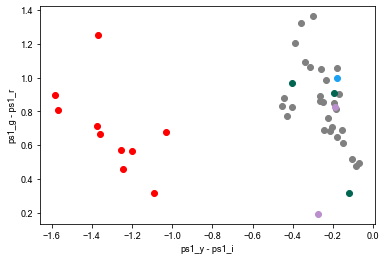

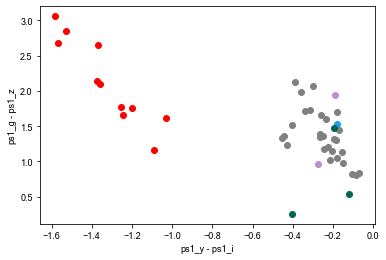

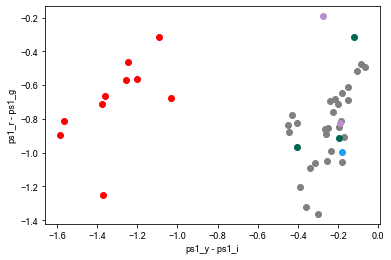

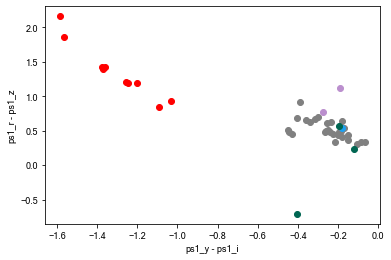

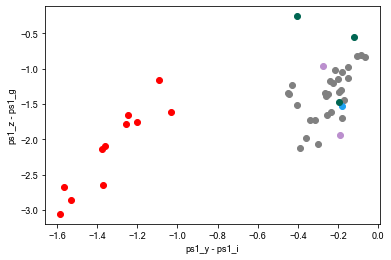

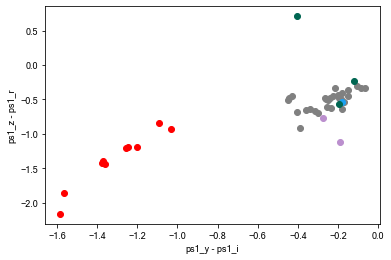

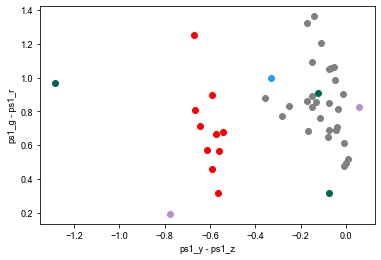

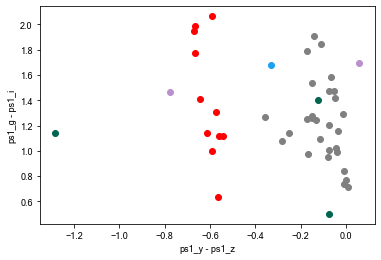

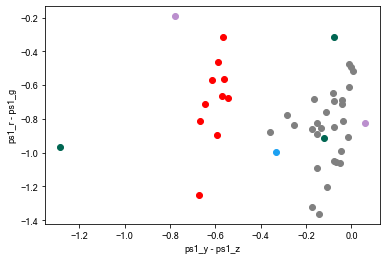

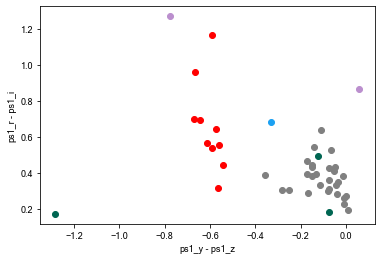

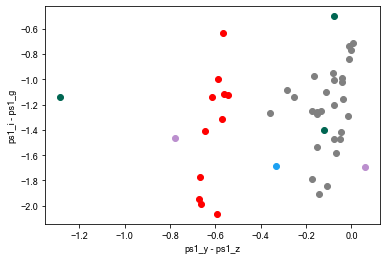

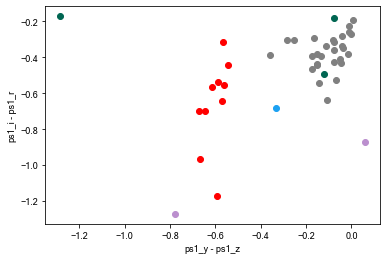

In [19]:
for thing in ps1_super_list:
    for otherthing in ps1_super_list:
        if ((thing[0]==thing[1])or (otherthing[0]==otherthing[1])or (thing==otherthing) or (thing[0]in otherthing) or (thing[1] in otherthing)):
            pass
        else:
            plot_sp_types(thing,otherthing)

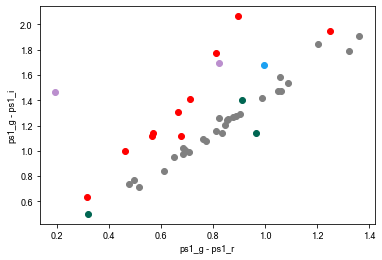

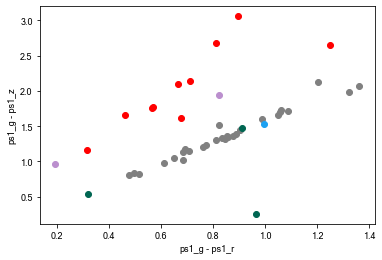

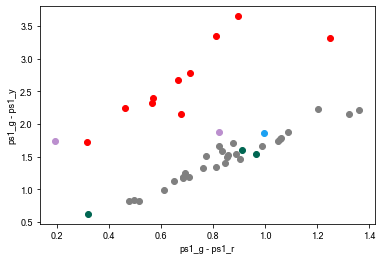

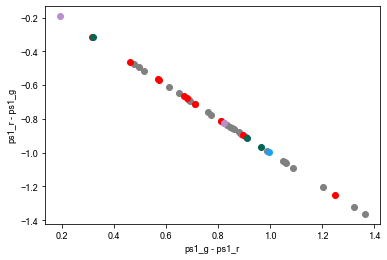

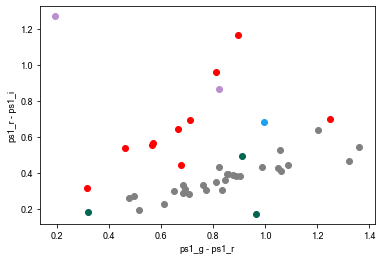

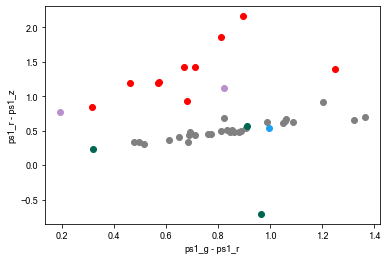

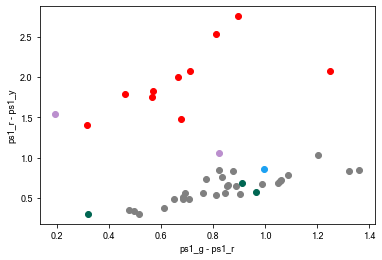

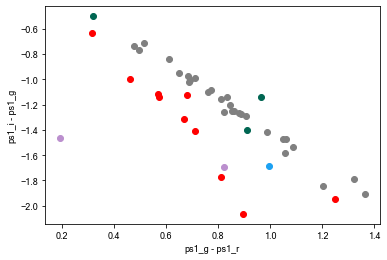

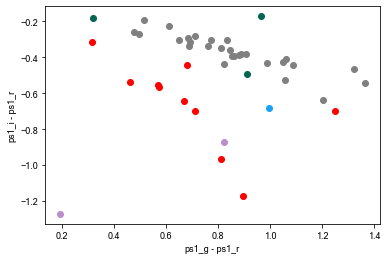

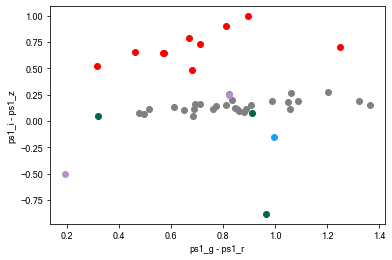

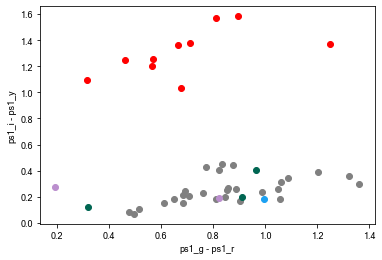

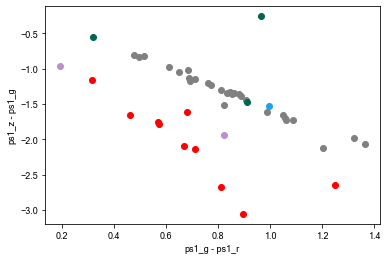

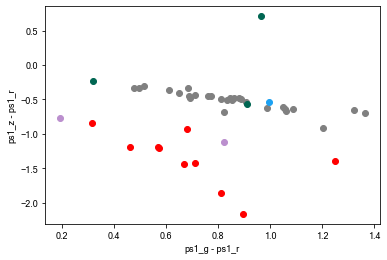

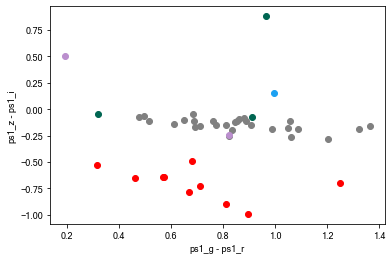

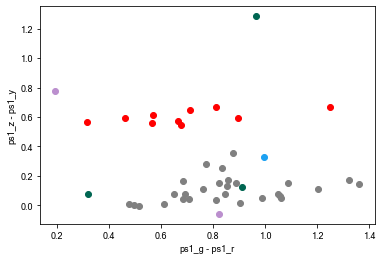

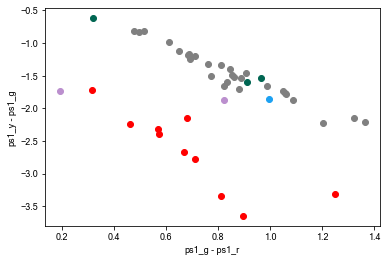

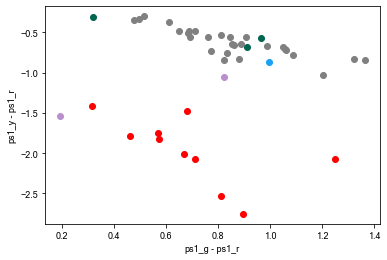

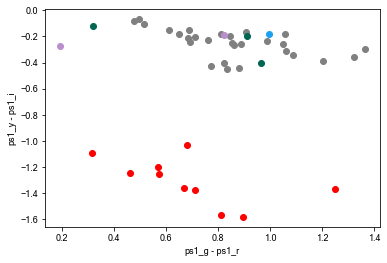

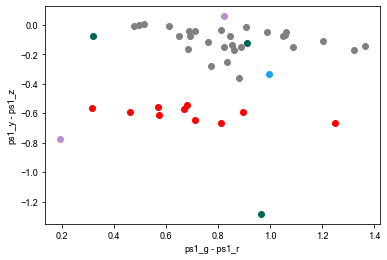

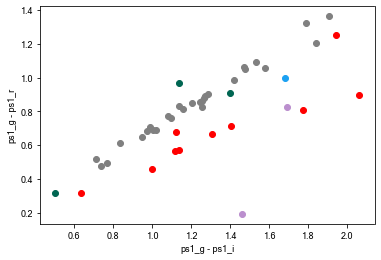

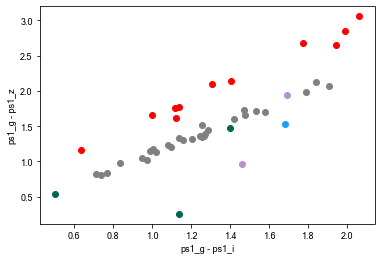

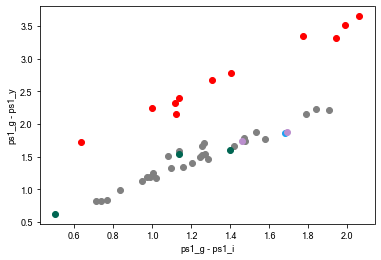

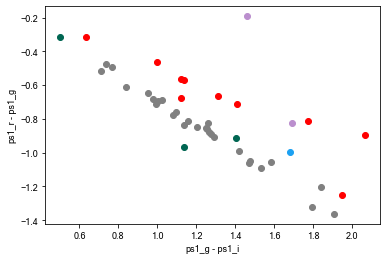

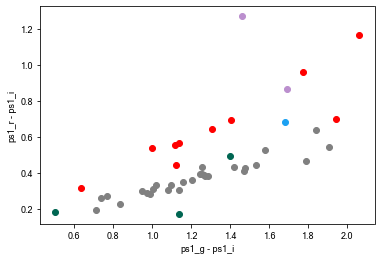

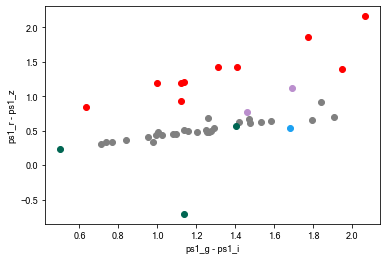

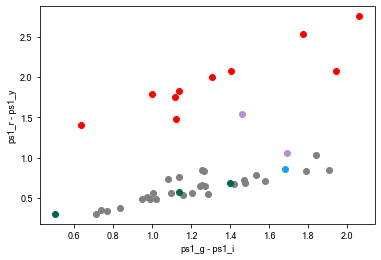

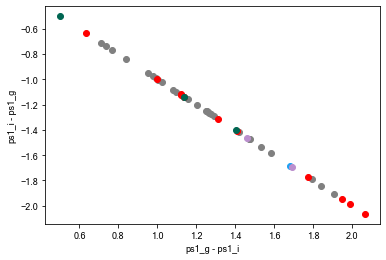

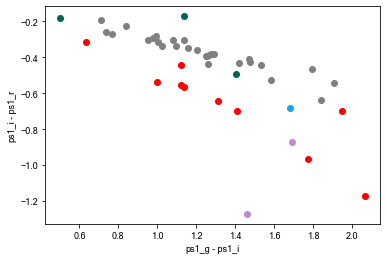

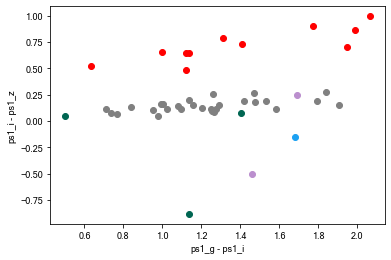

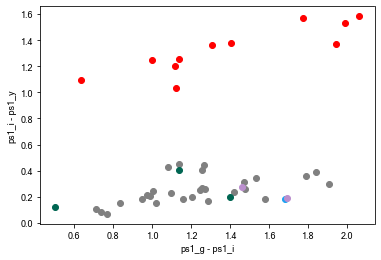

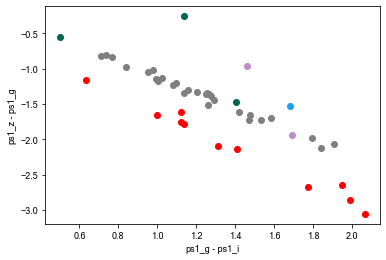

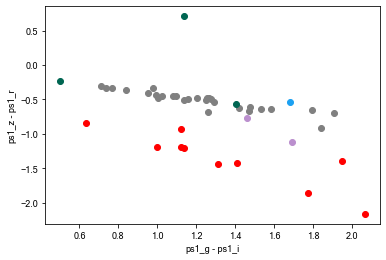

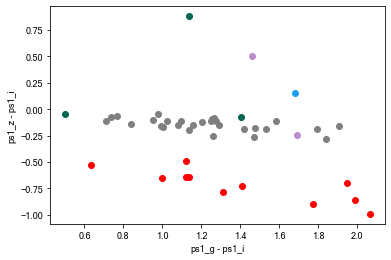

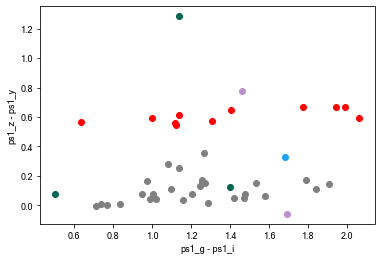

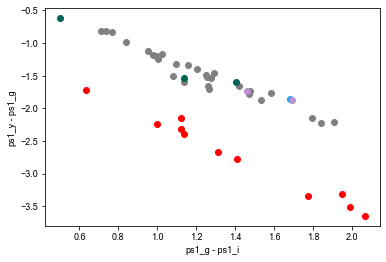

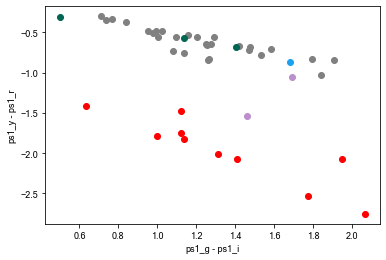

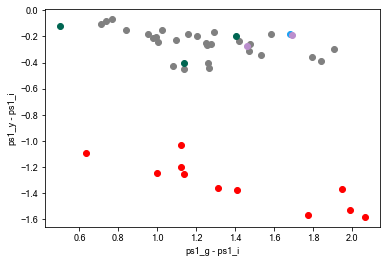

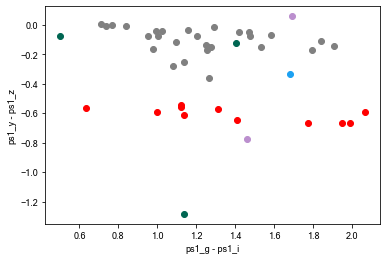

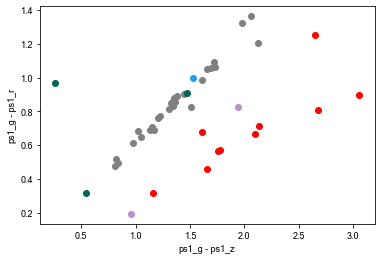

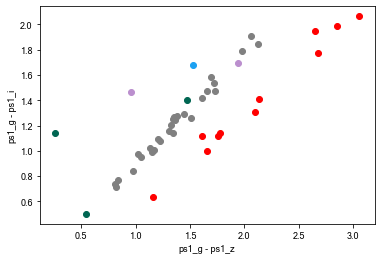

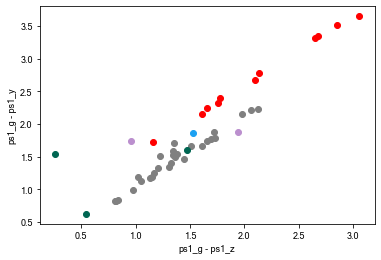

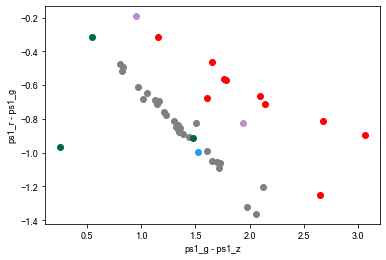

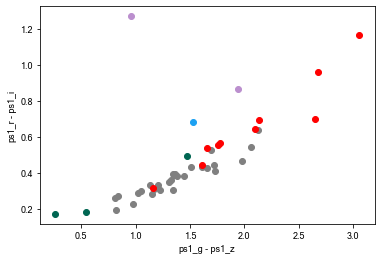

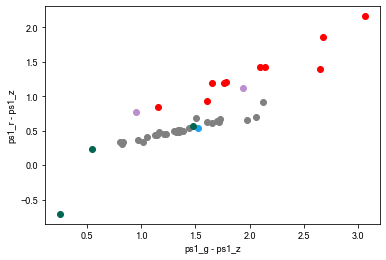

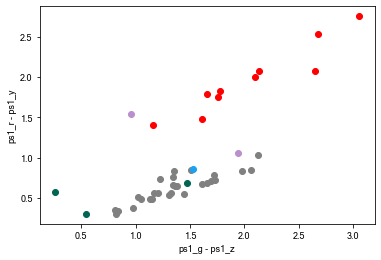

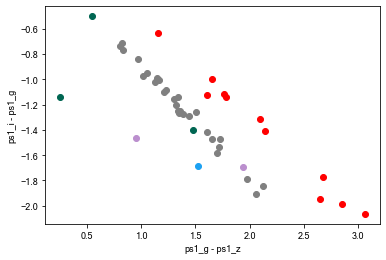

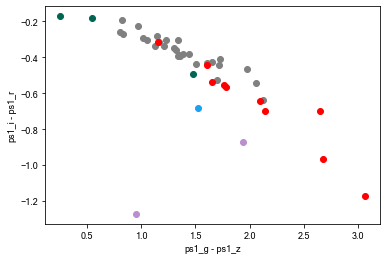

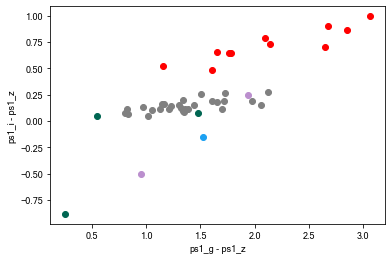

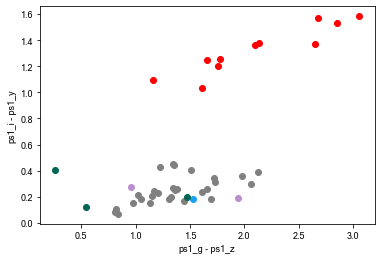

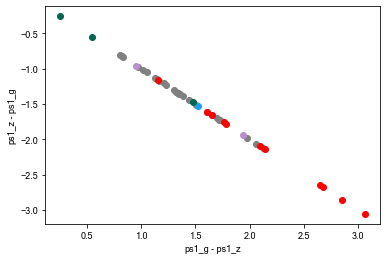

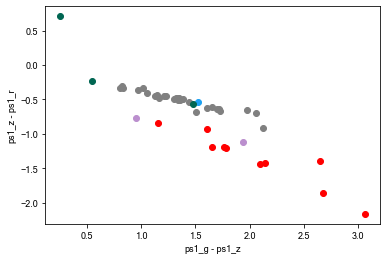

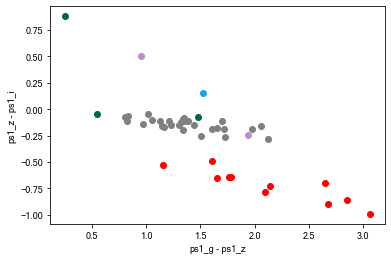

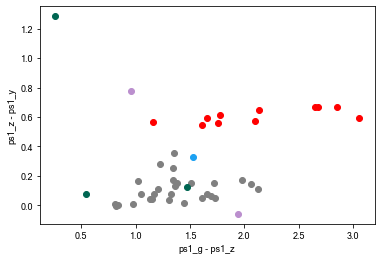

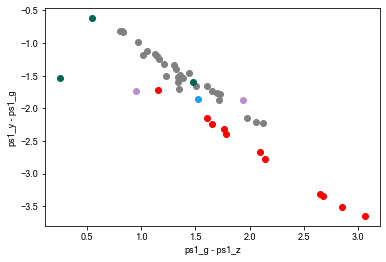

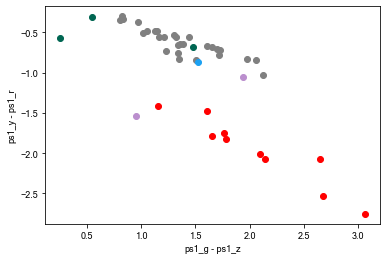

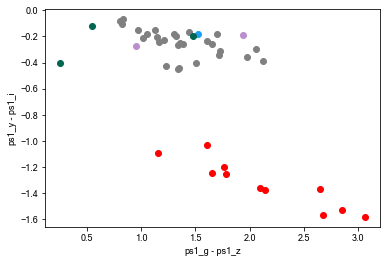

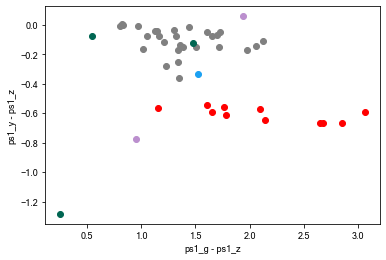

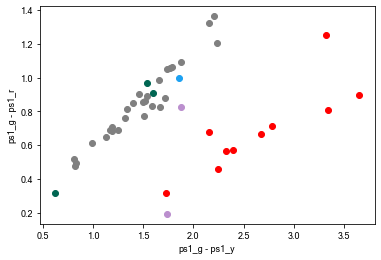

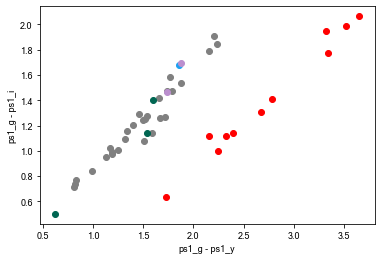

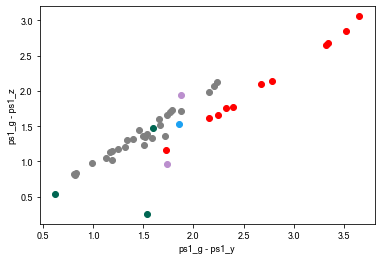

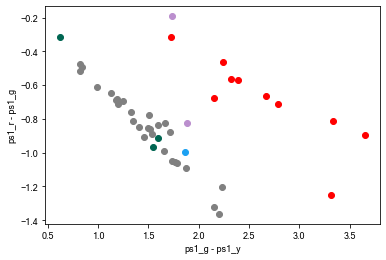

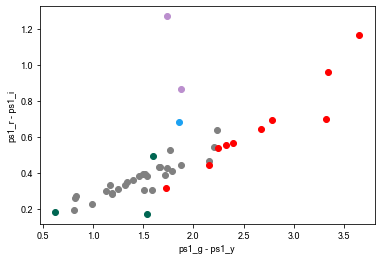

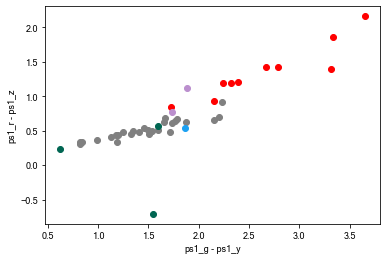

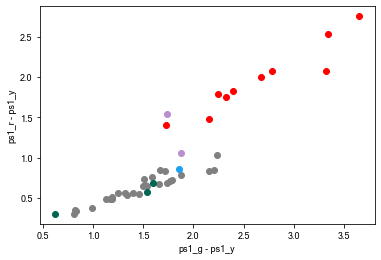

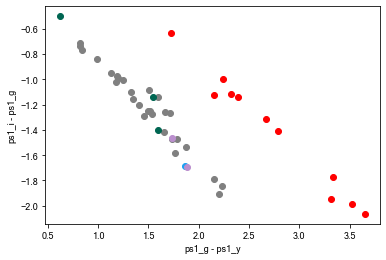

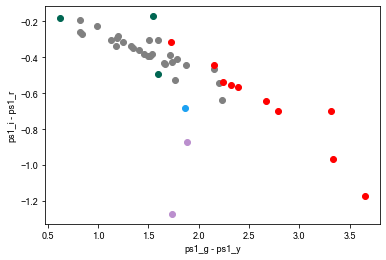

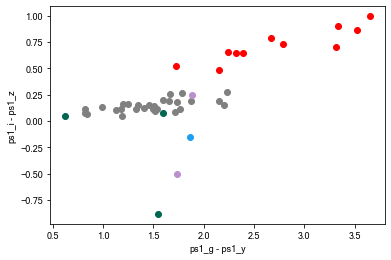

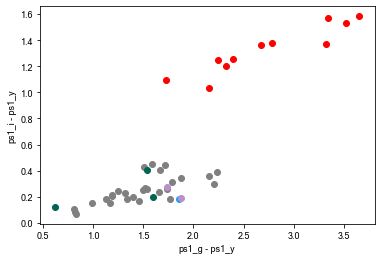

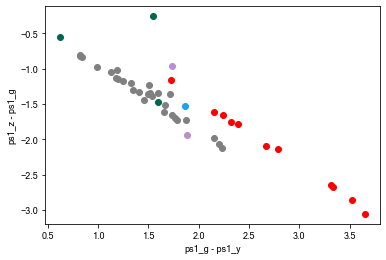

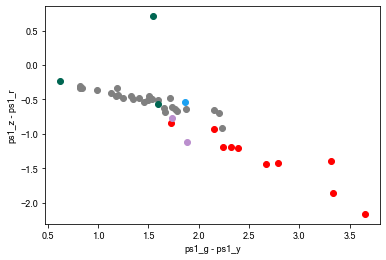

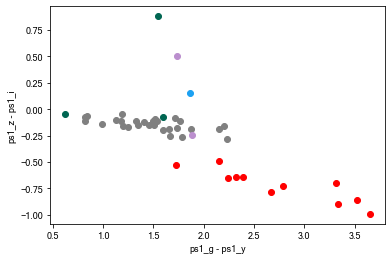

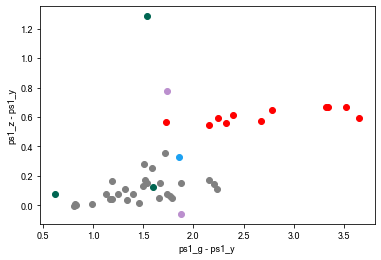

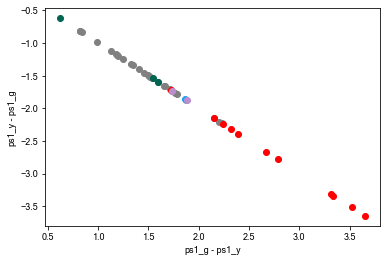

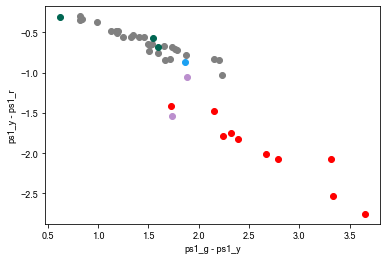

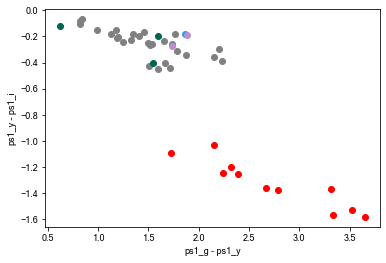

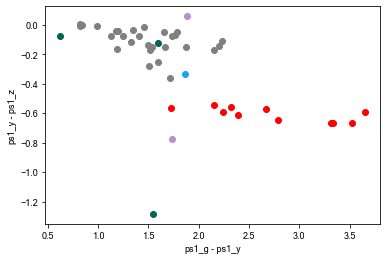

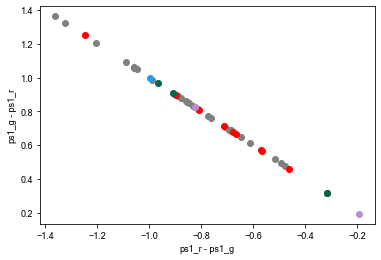

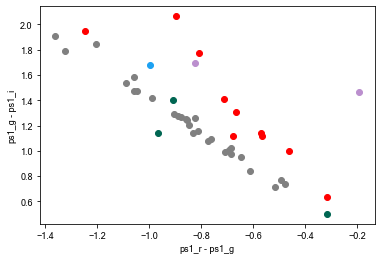

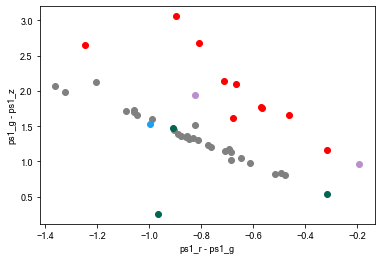

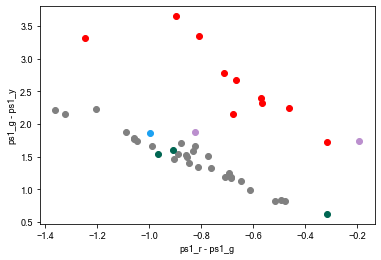

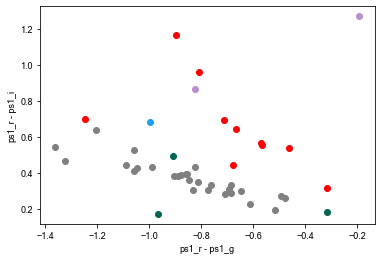

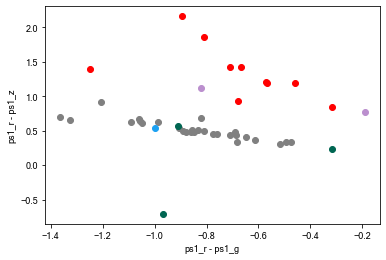

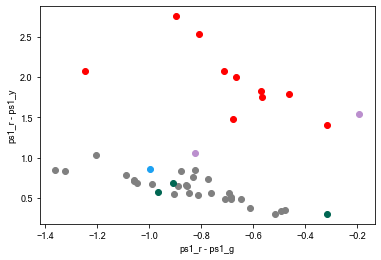

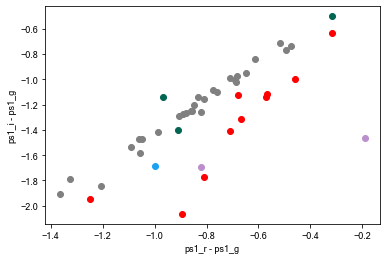

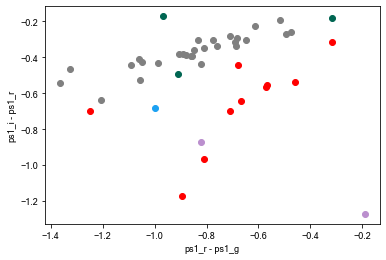

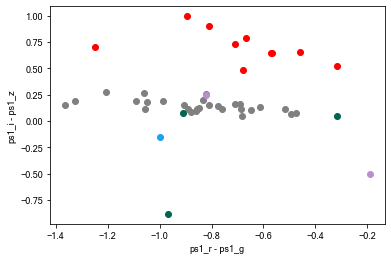

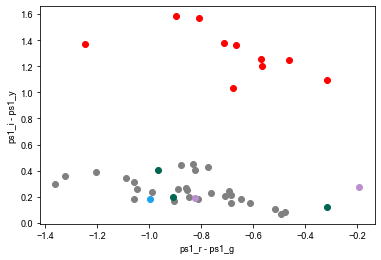

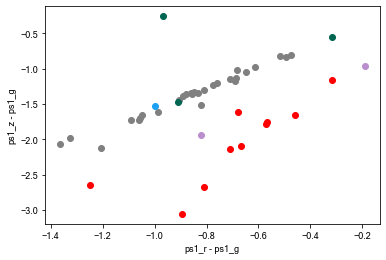

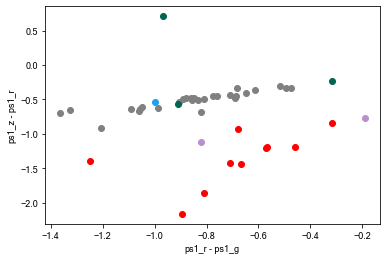

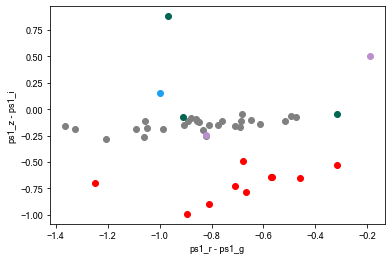

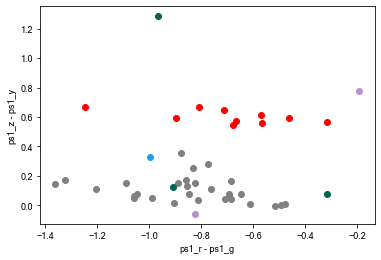

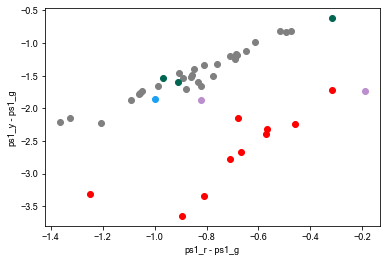

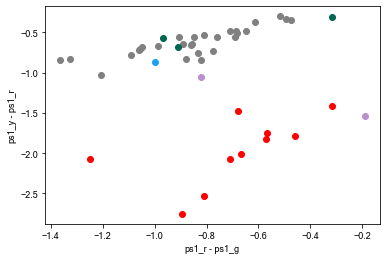

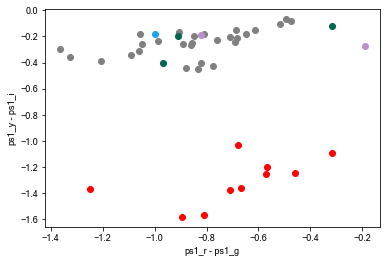

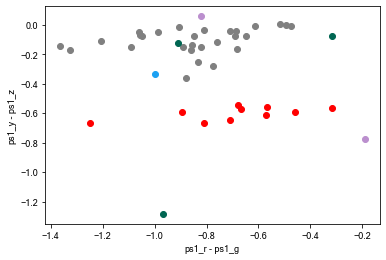

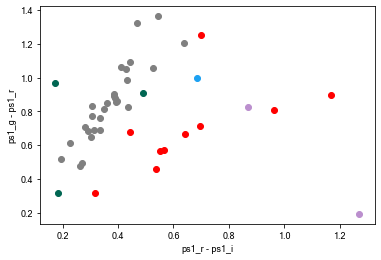

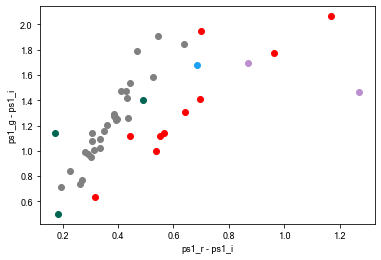

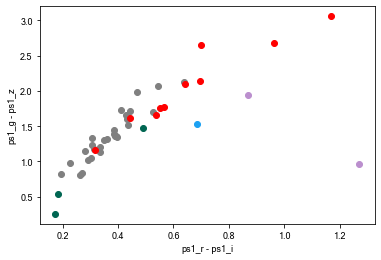

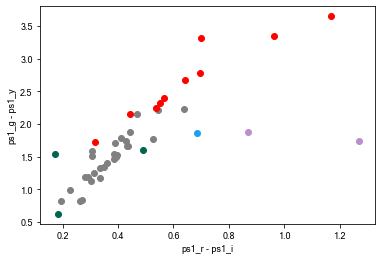

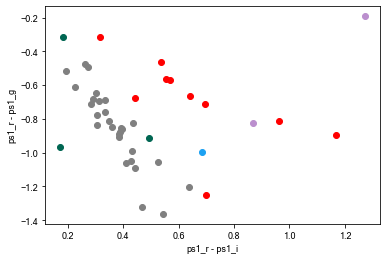

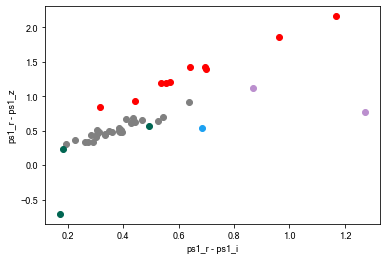

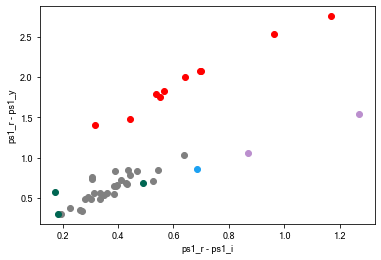

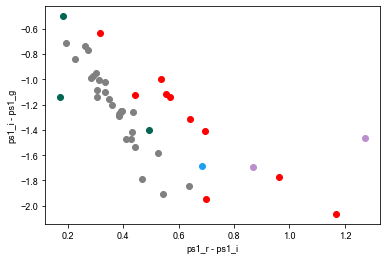

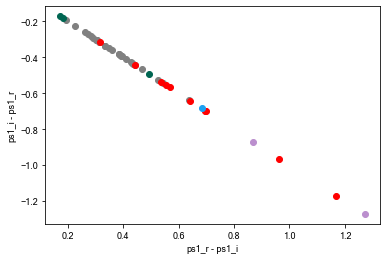

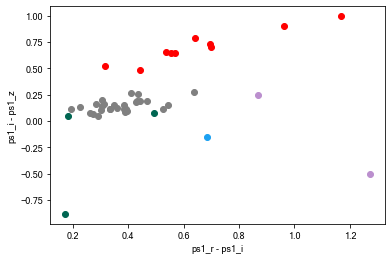

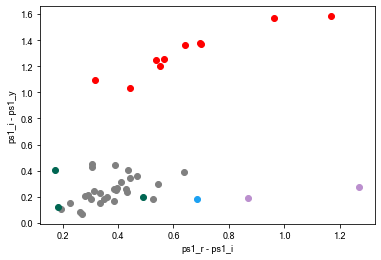

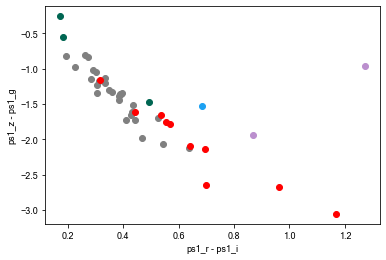

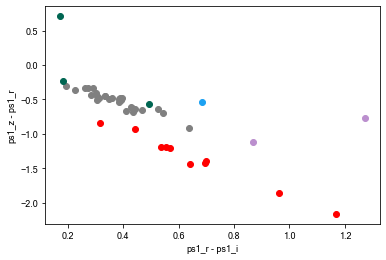

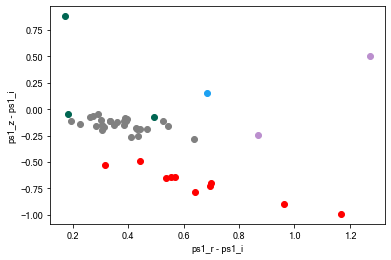

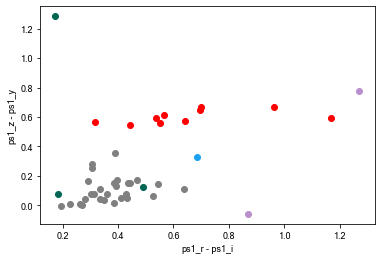

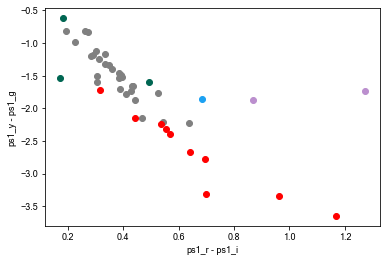

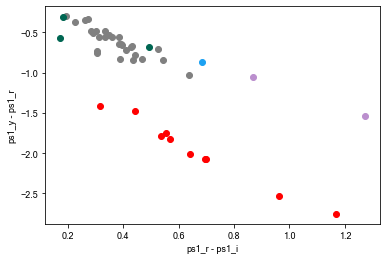

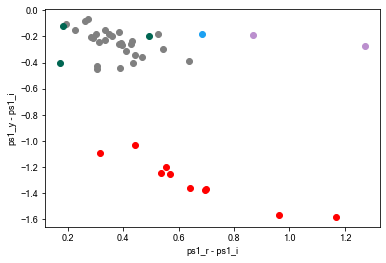

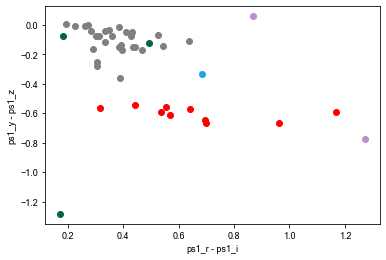

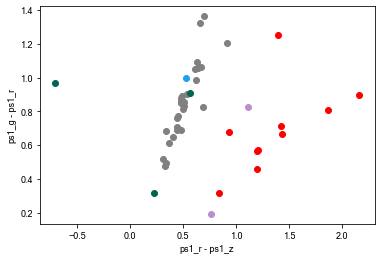

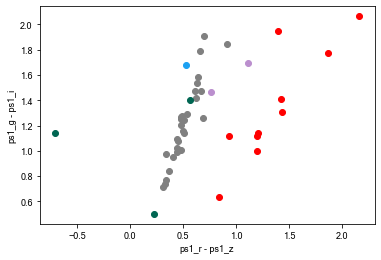

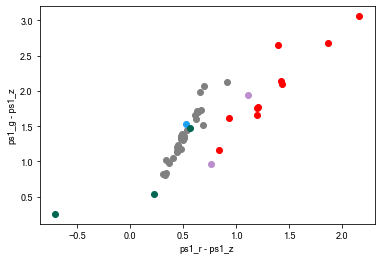

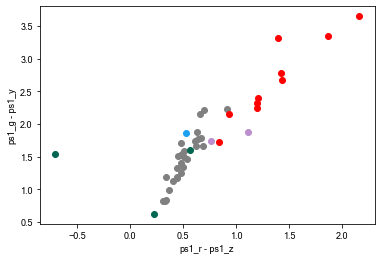

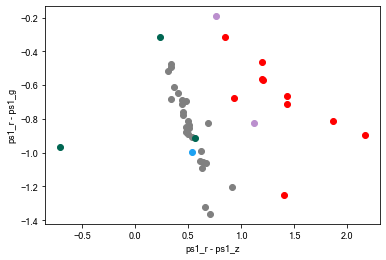

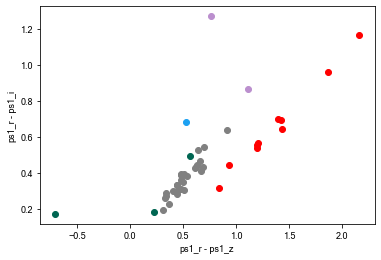

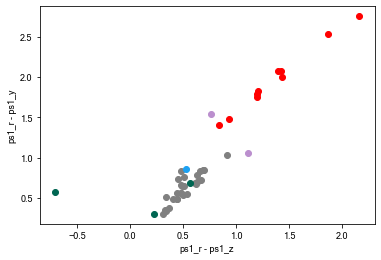

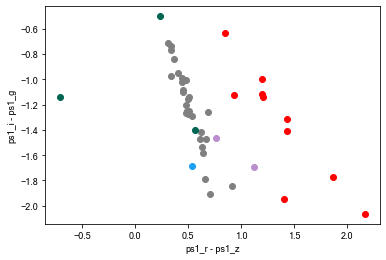

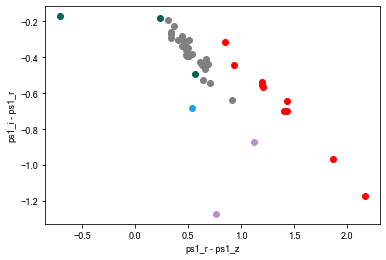

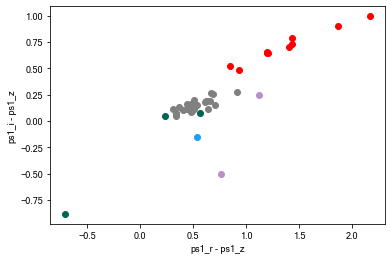

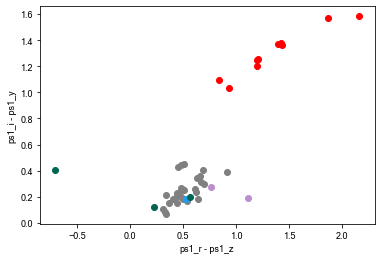

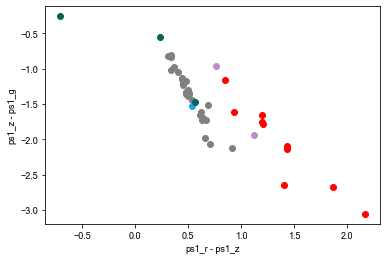

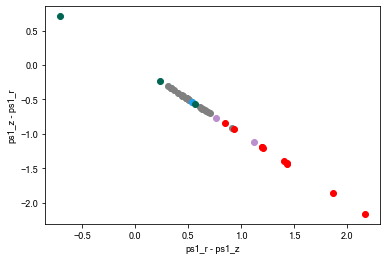

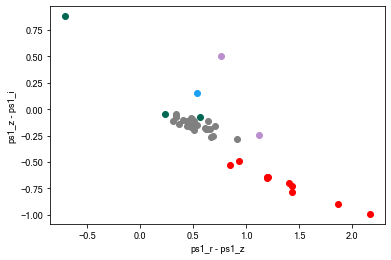

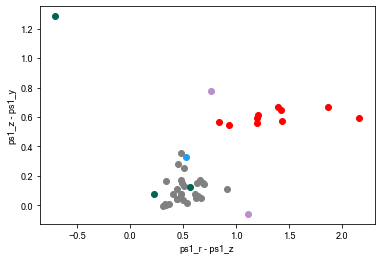

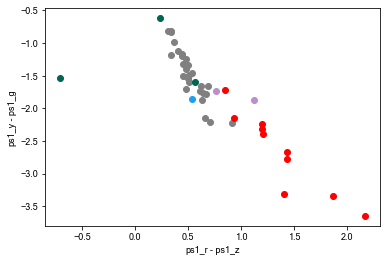

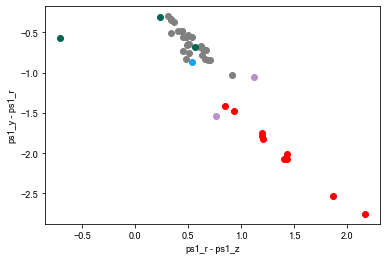

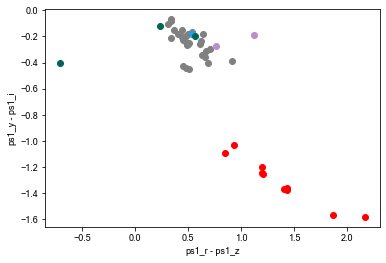

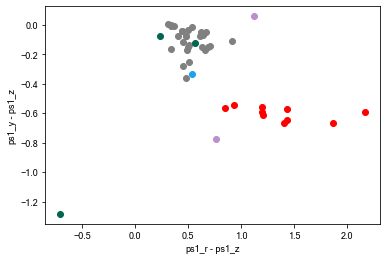

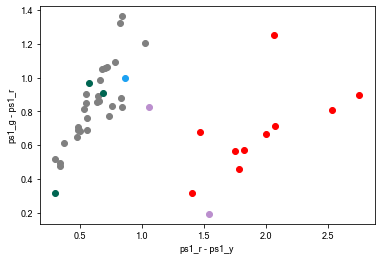

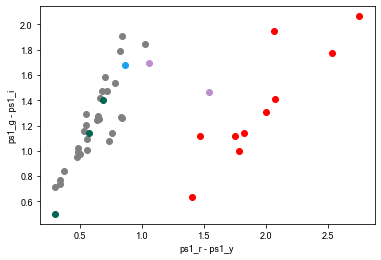

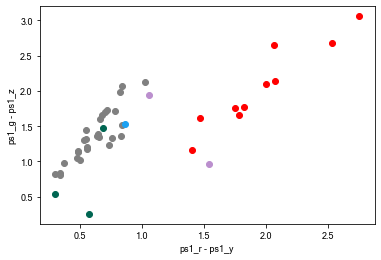

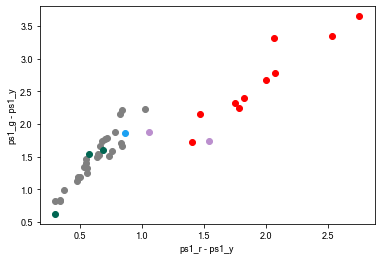

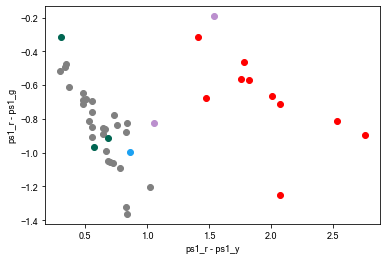

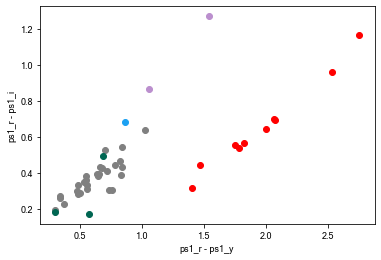

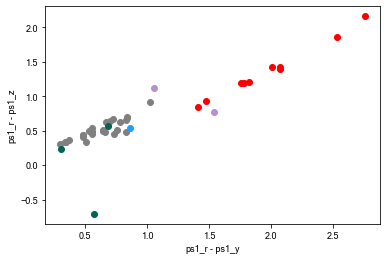

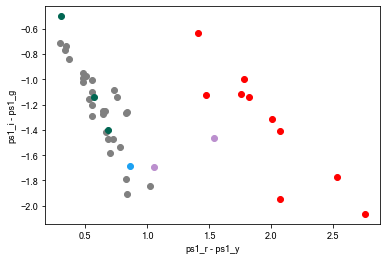

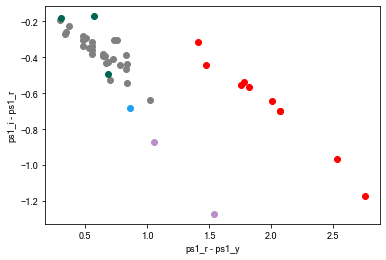

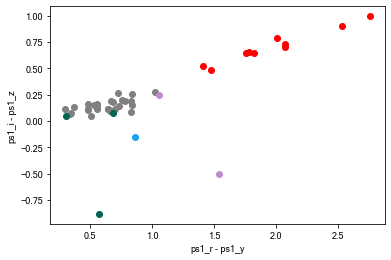

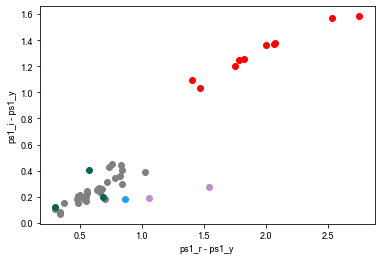

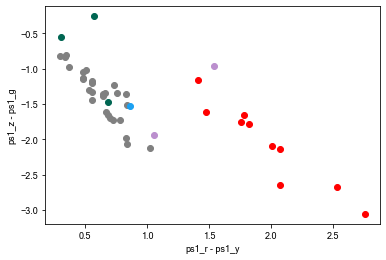

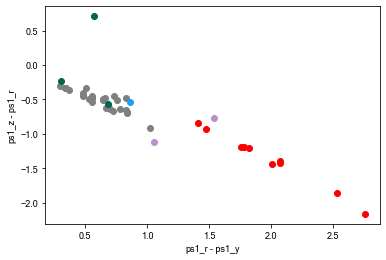

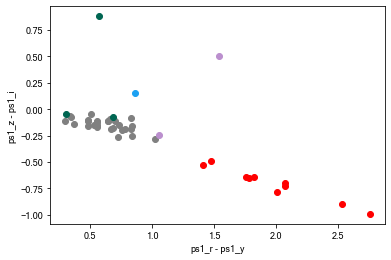

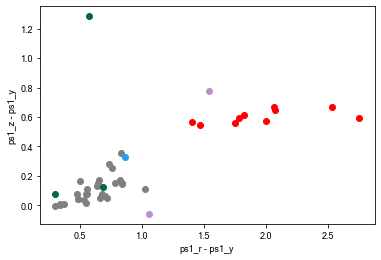

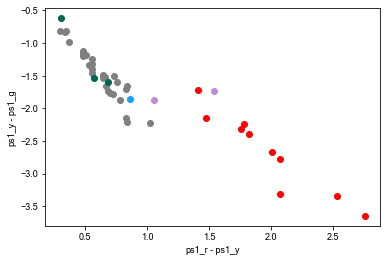

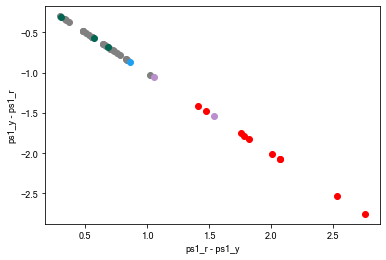

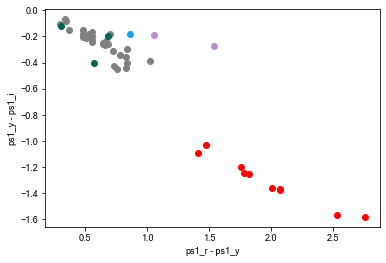

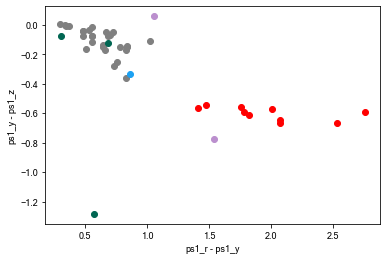

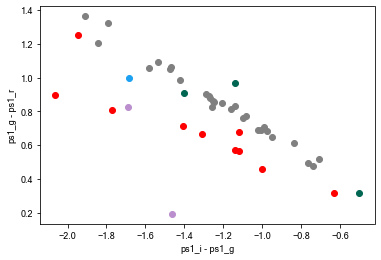

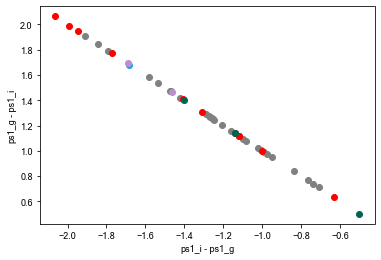

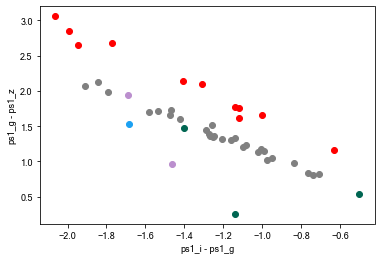

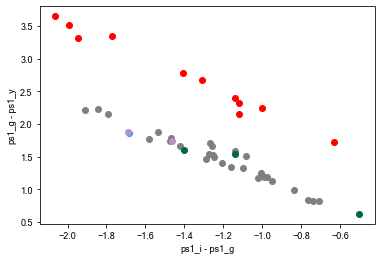

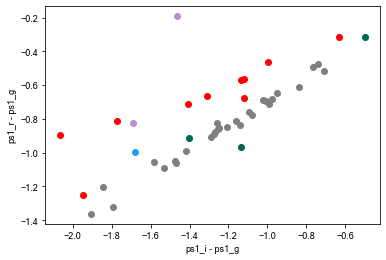

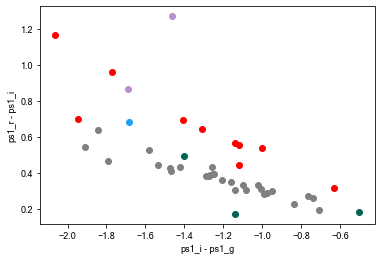

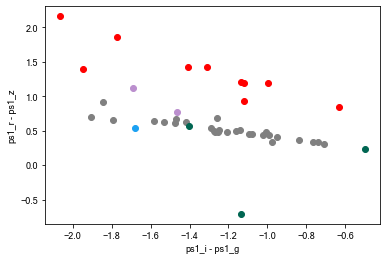

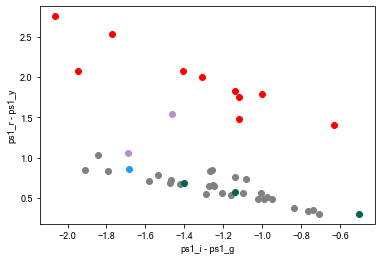

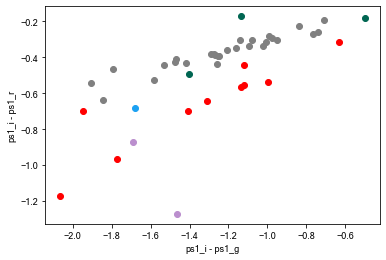

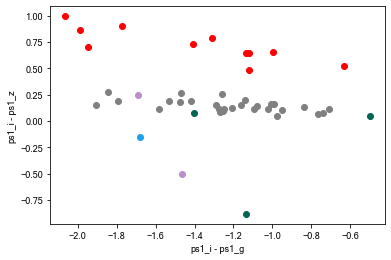

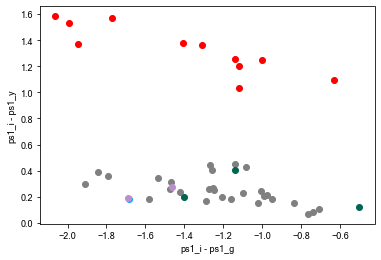

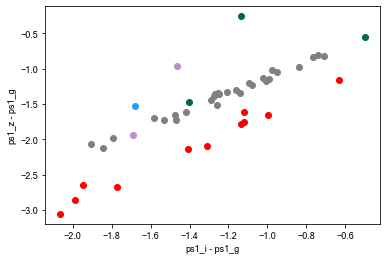

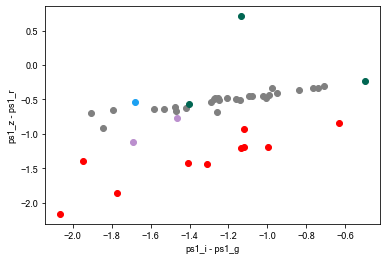

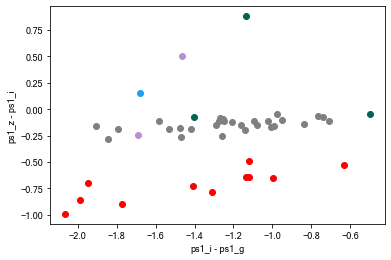

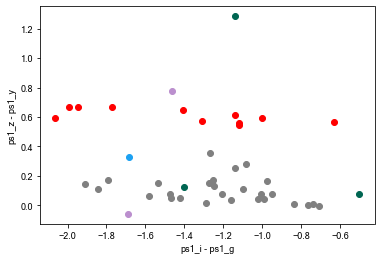

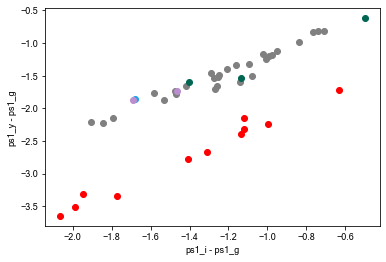

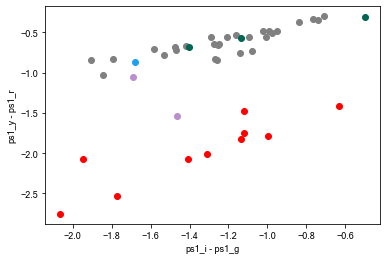

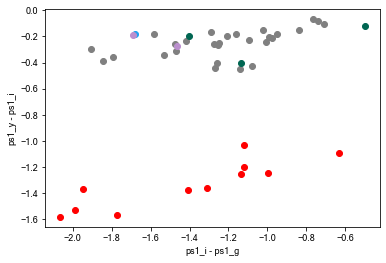

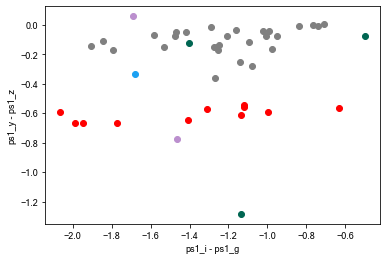

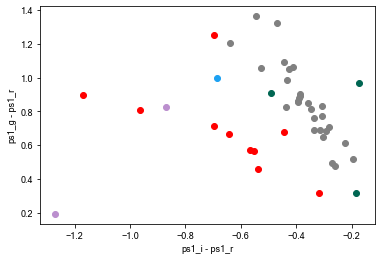

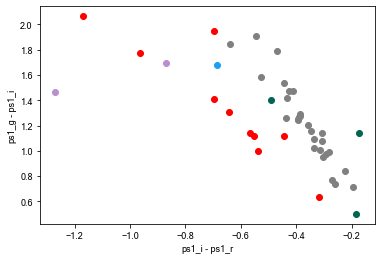

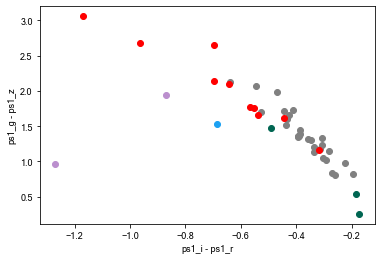

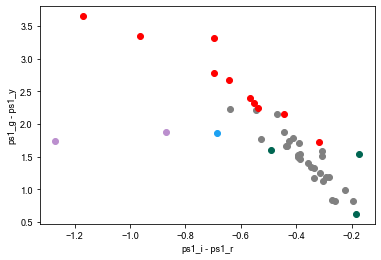

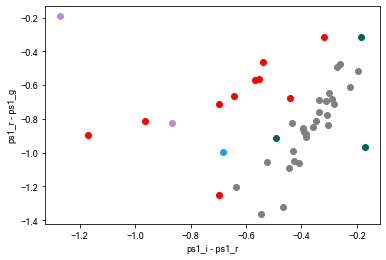

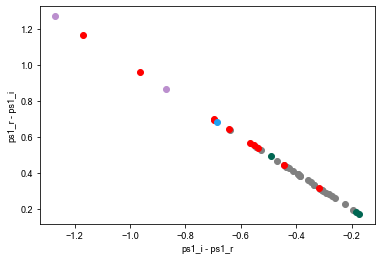

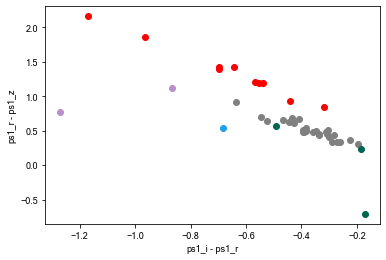

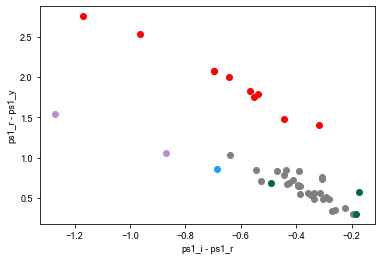

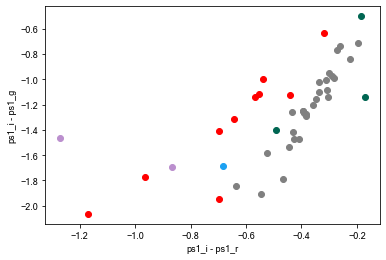

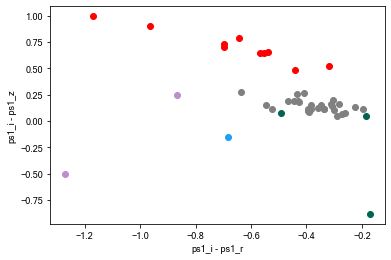

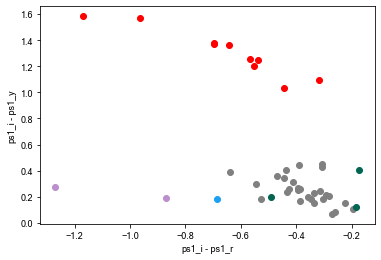

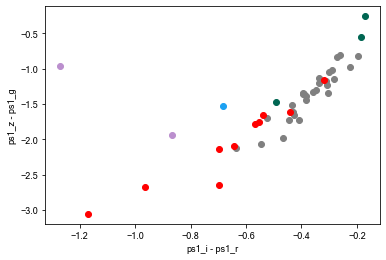

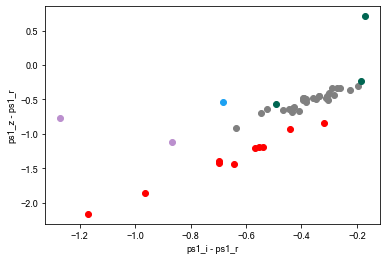

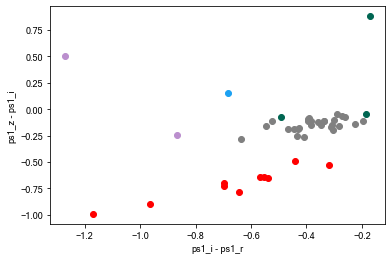

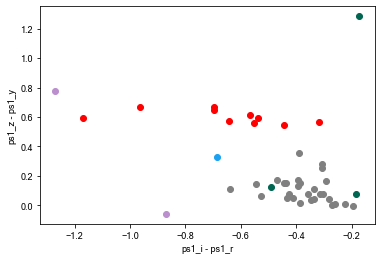

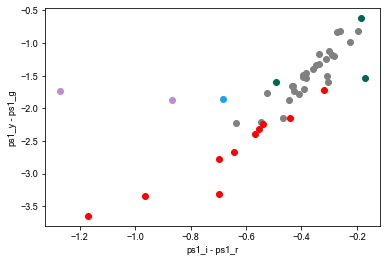

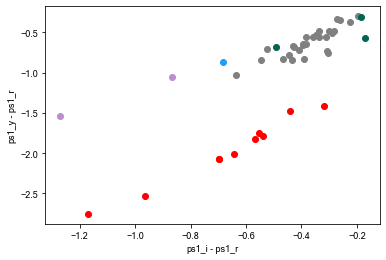

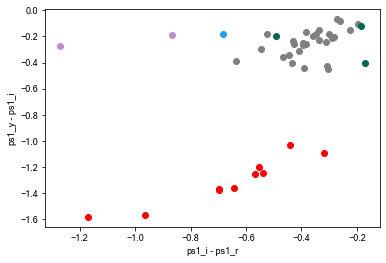

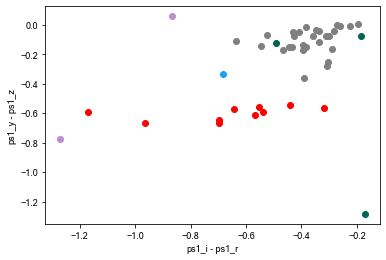

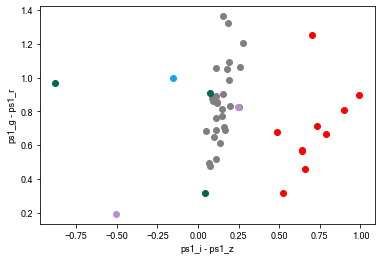

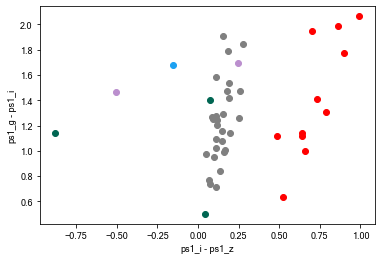

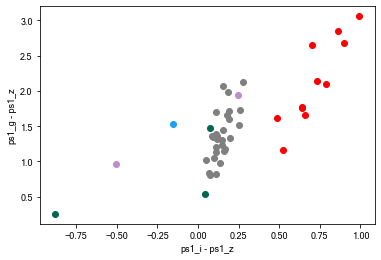

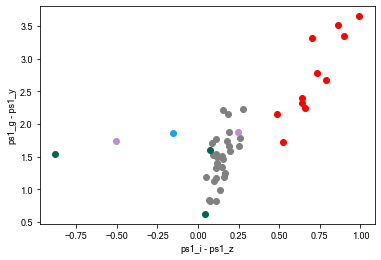

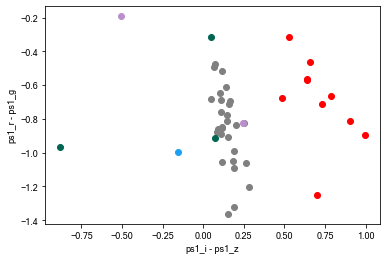

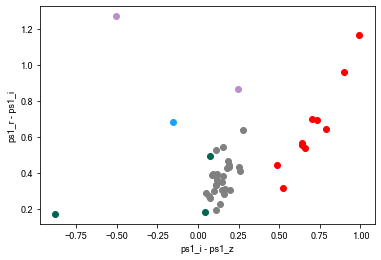

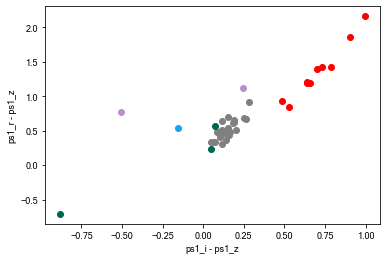

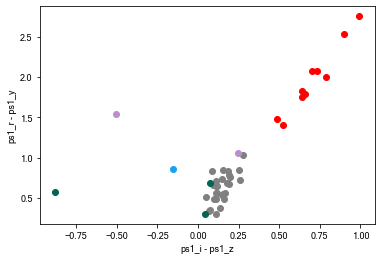

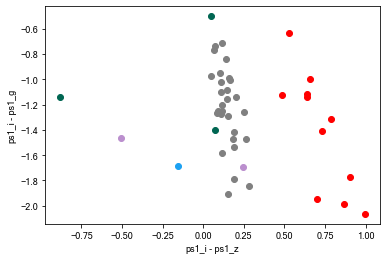

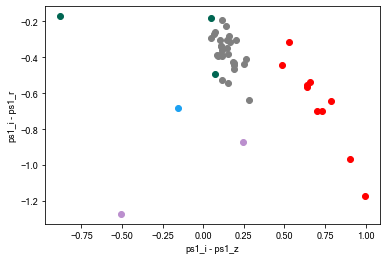

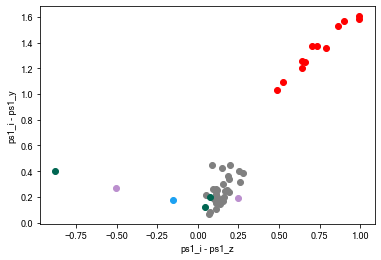

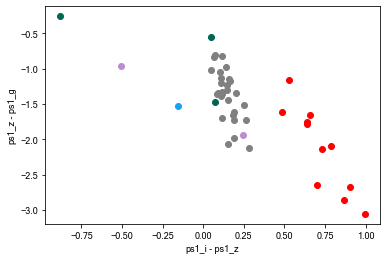

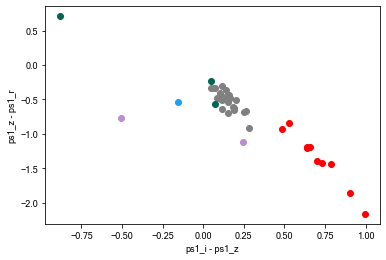

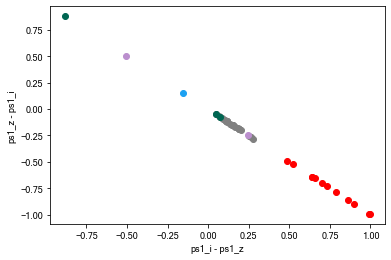

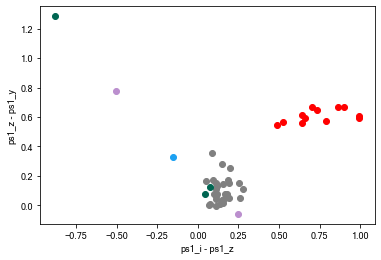

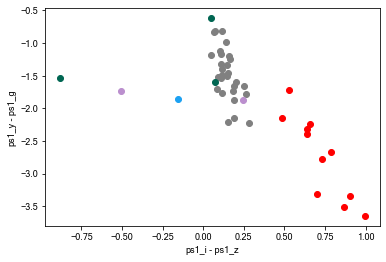

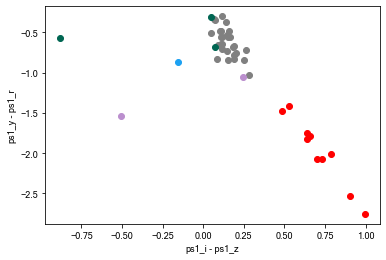

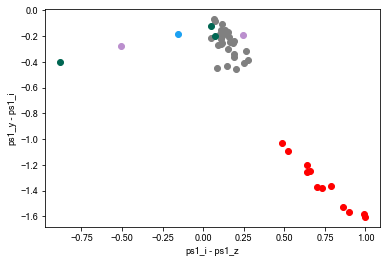

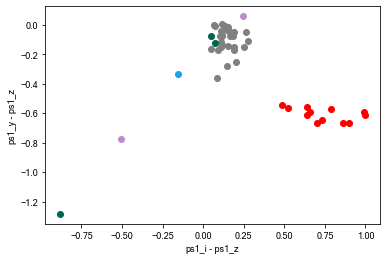

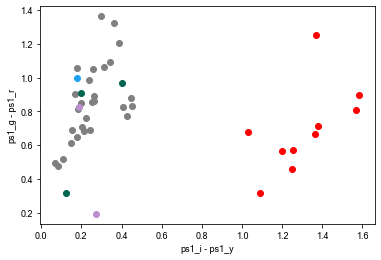

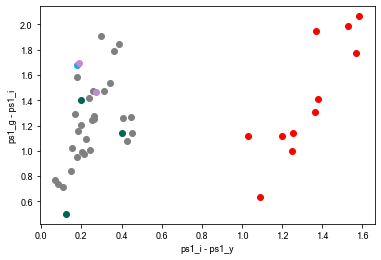

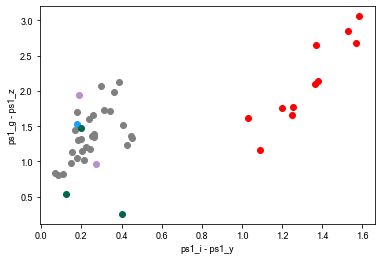

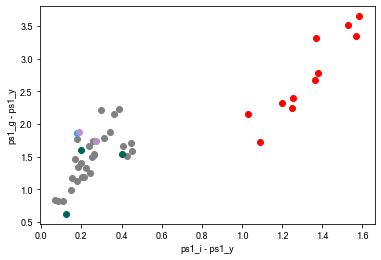

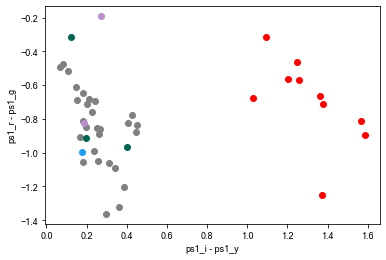

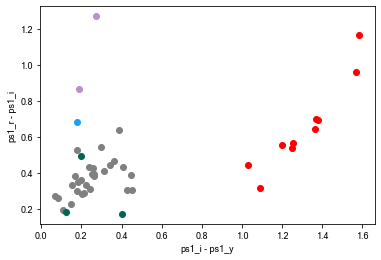

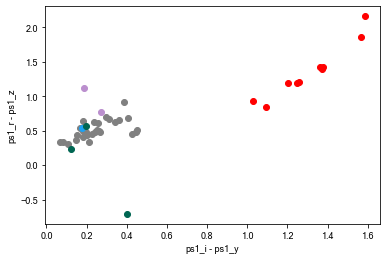

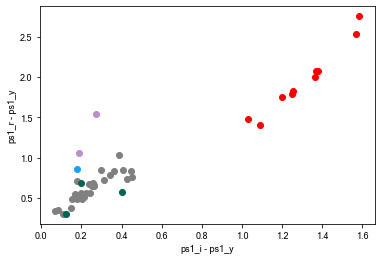

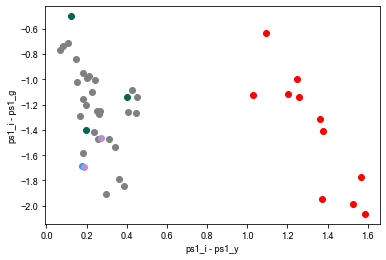

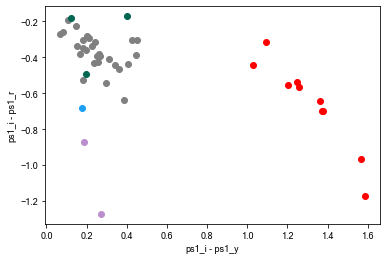

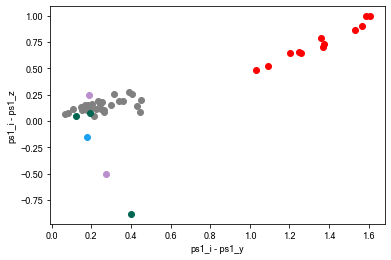

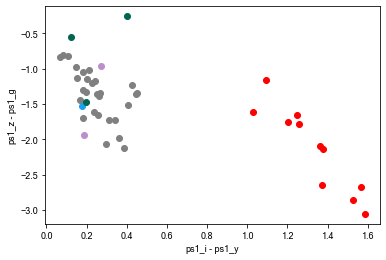

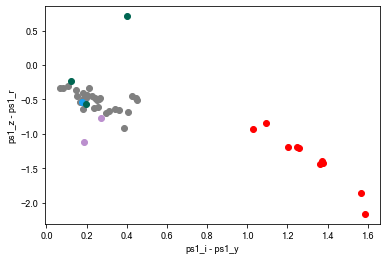

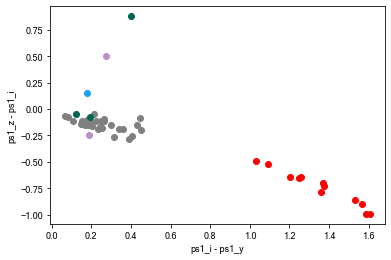

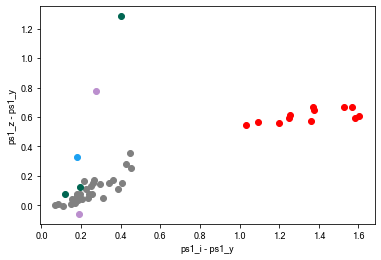

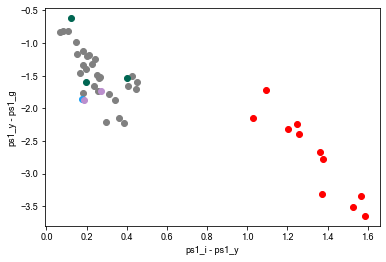

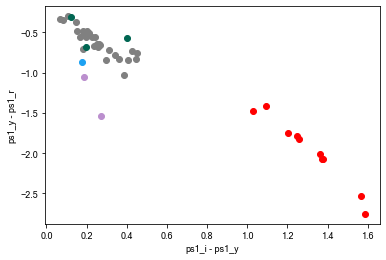

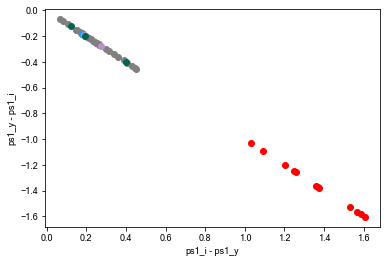

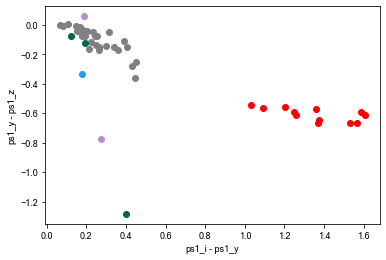

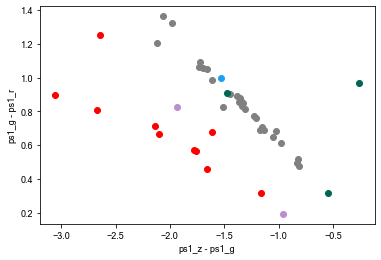

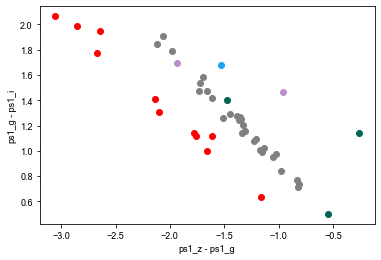

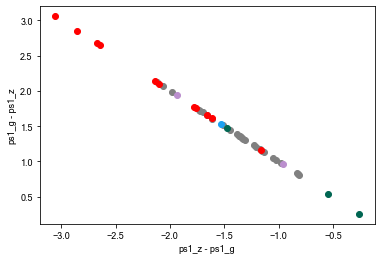

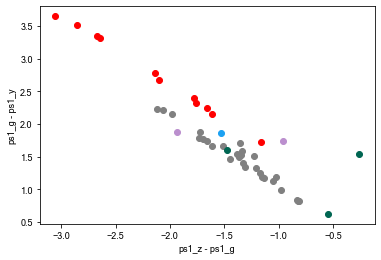

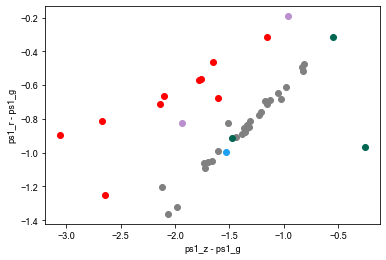

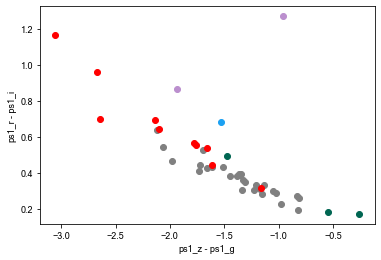

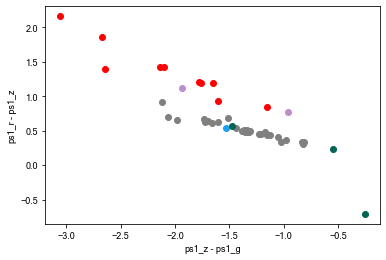

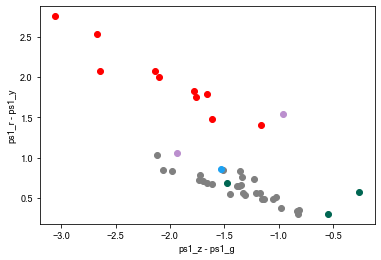

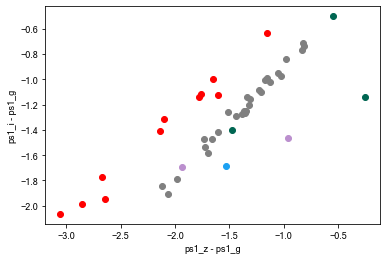

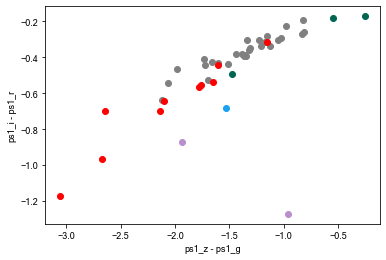

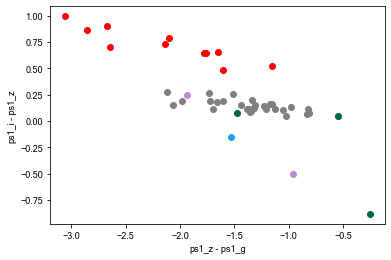

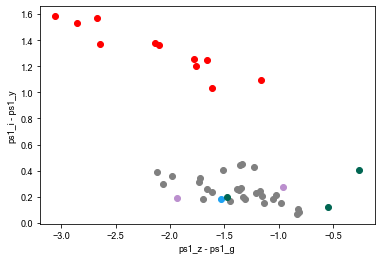

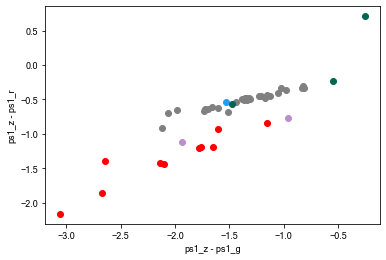

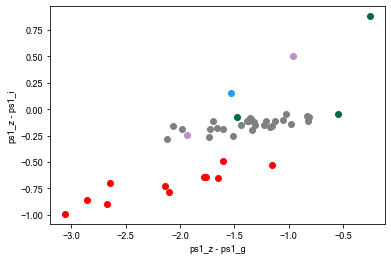

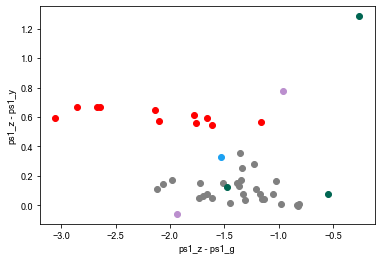

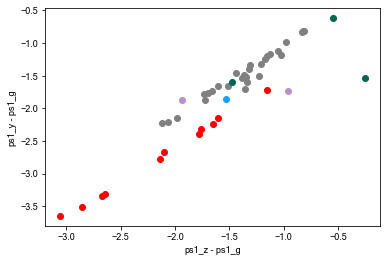

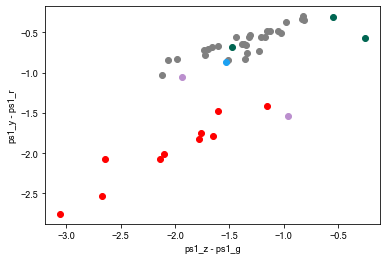

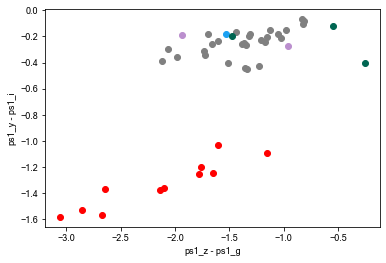

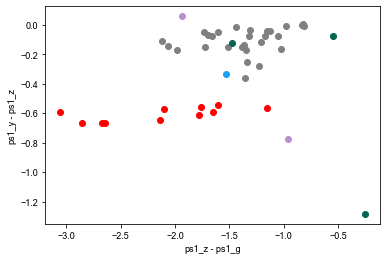

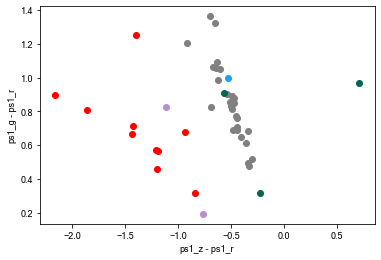

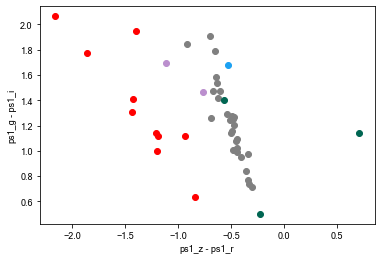

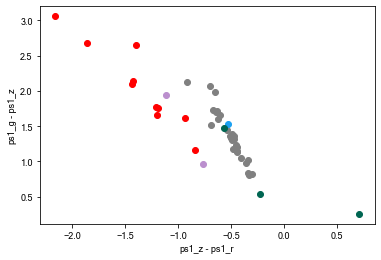

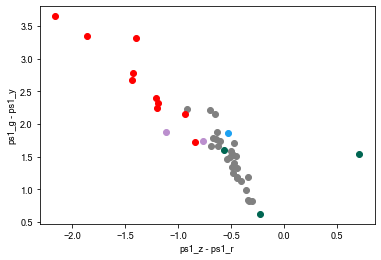

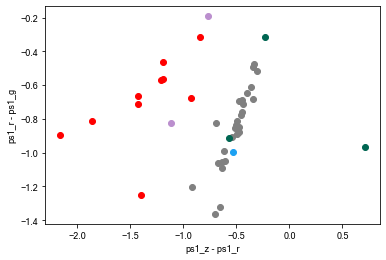

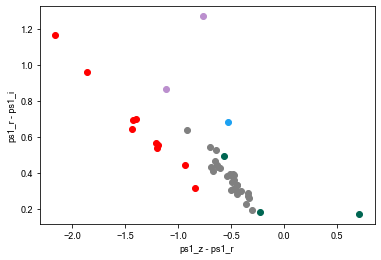

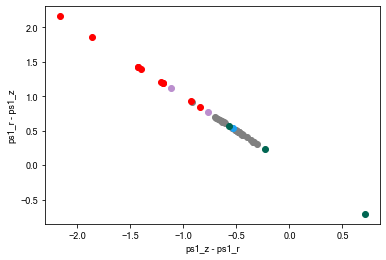

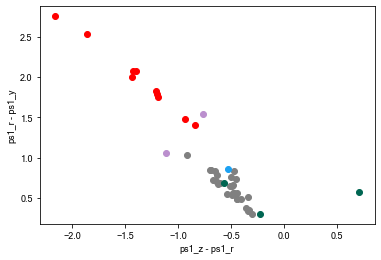

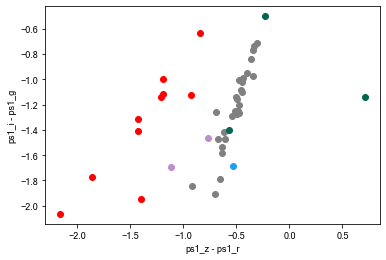

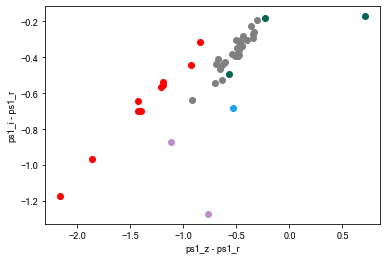

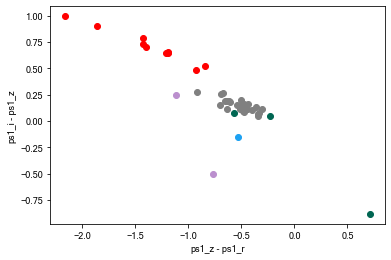

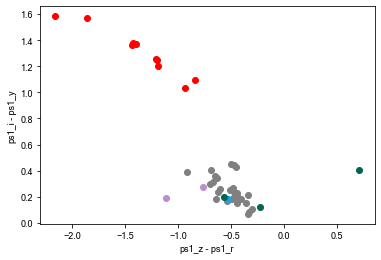

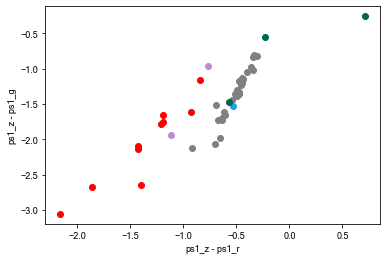

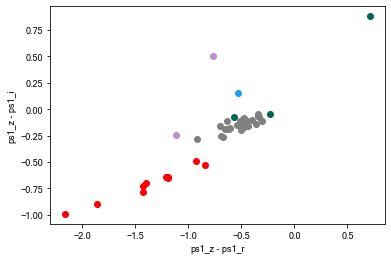

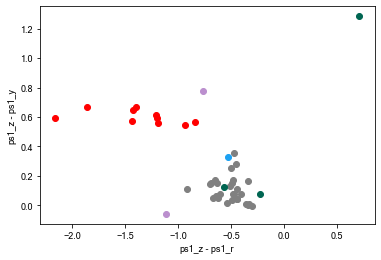

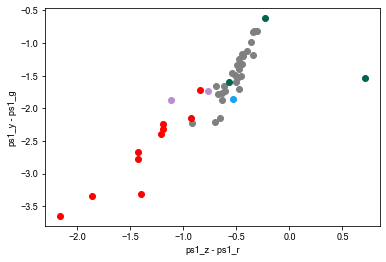

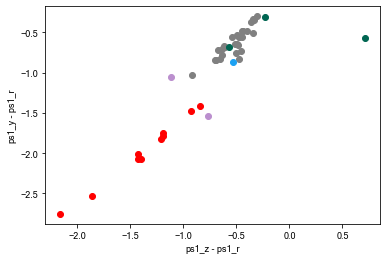

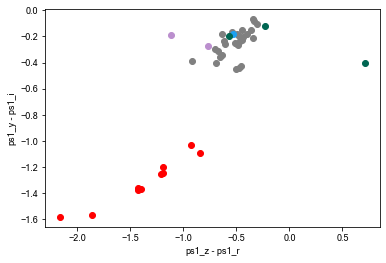

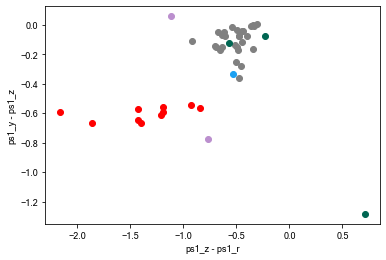

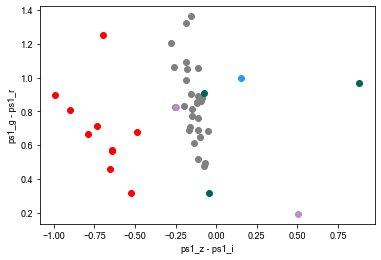

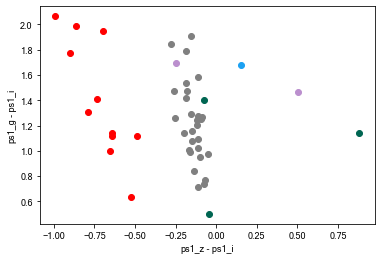

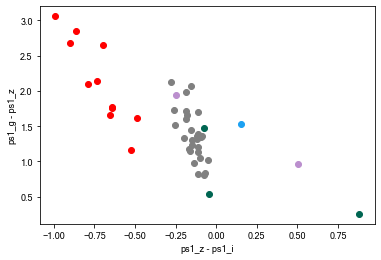

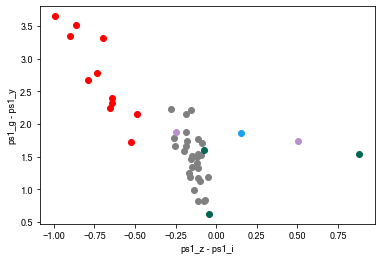

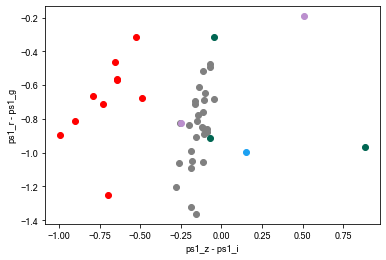

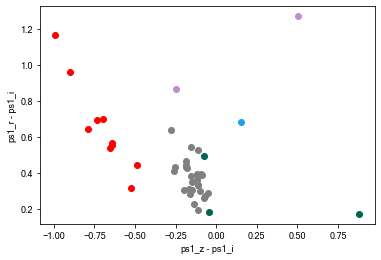

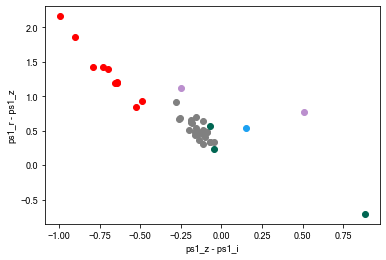

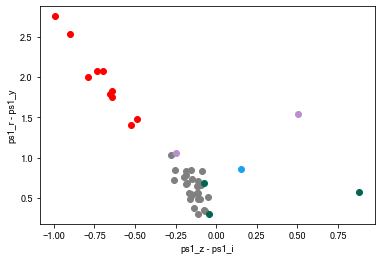

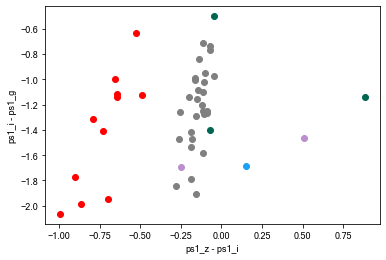

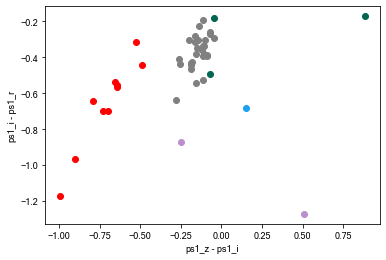

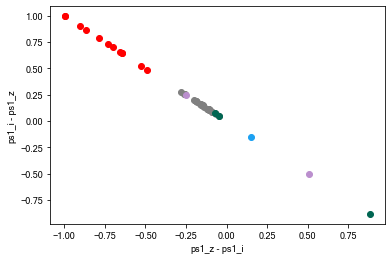

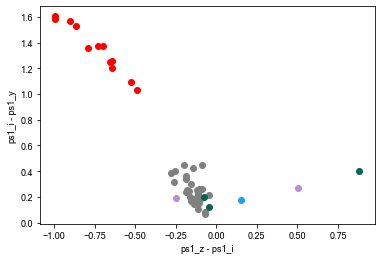

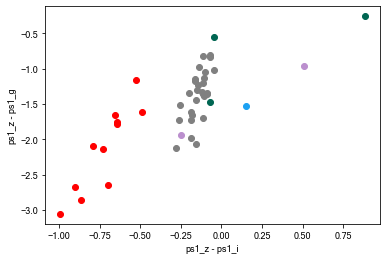

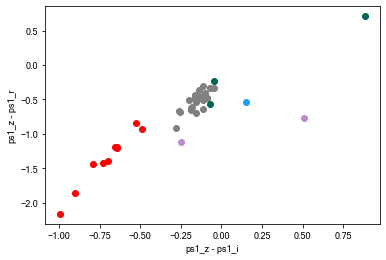

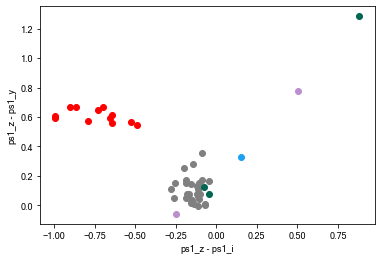

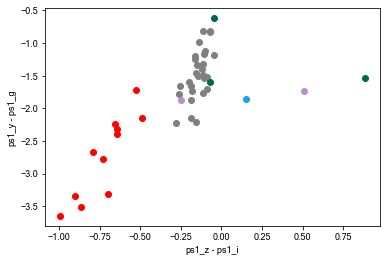

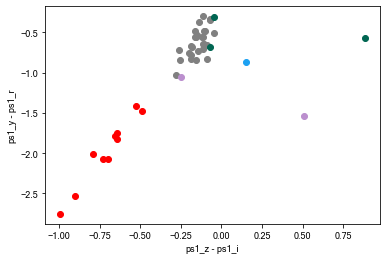

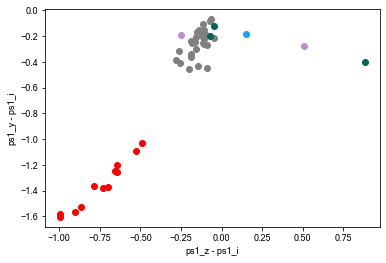

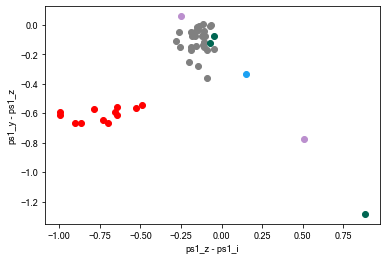

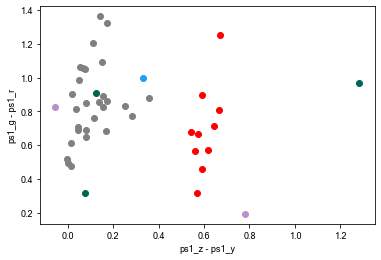

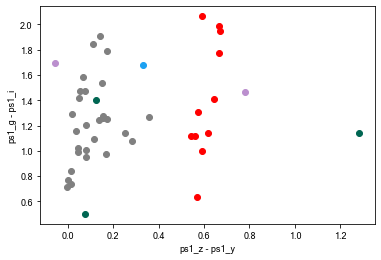

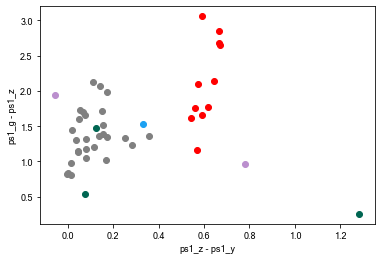

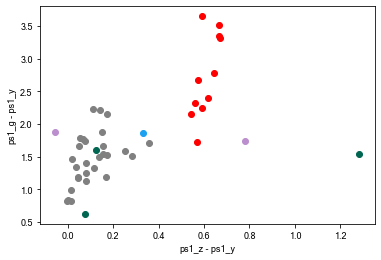

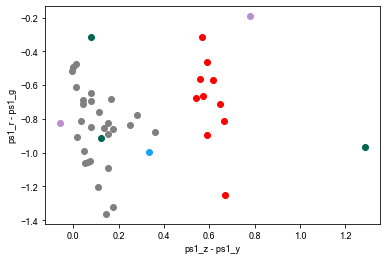

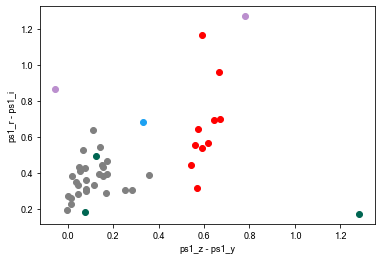

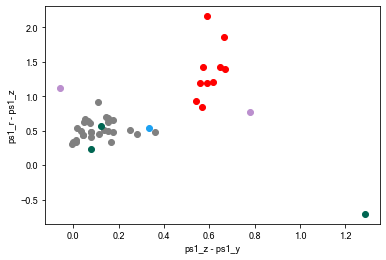

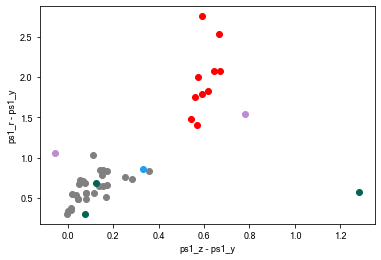

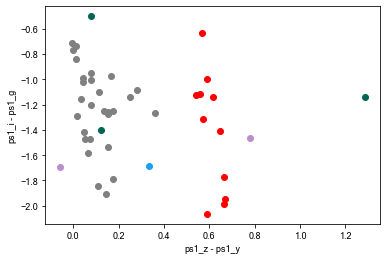

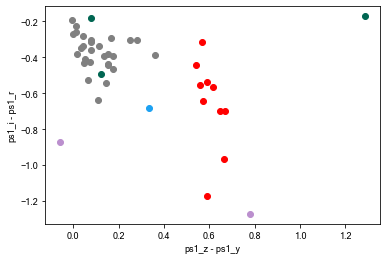

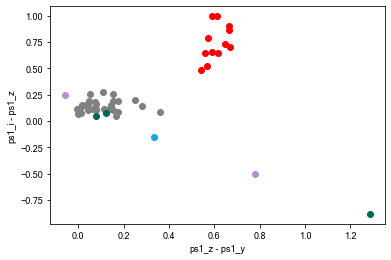

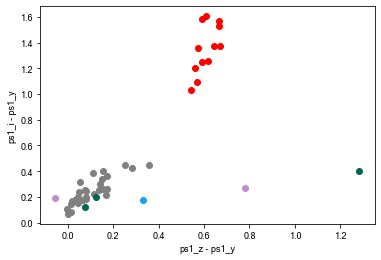

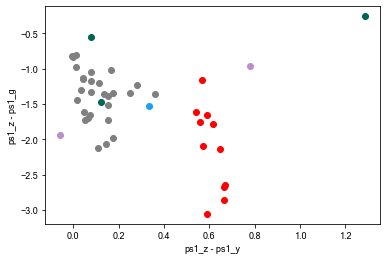

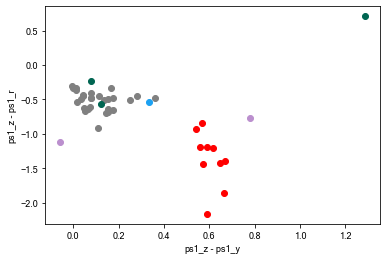

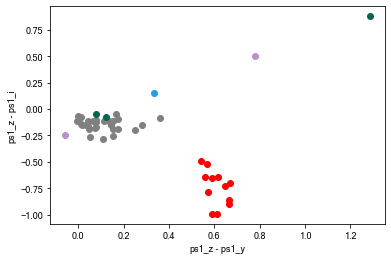

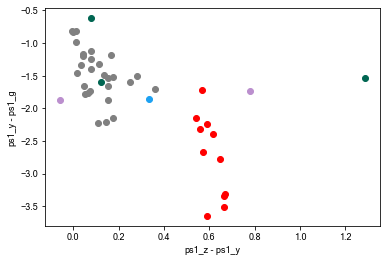

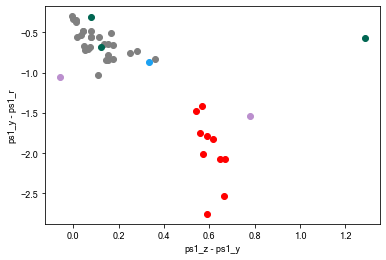

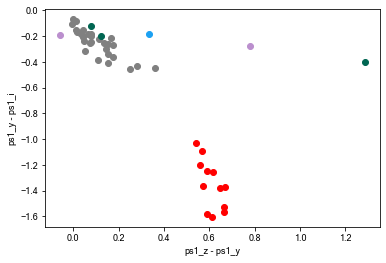

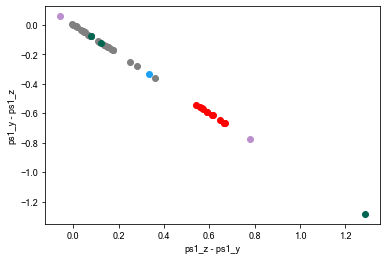

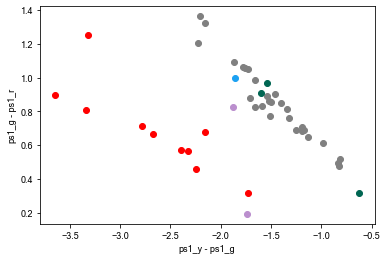

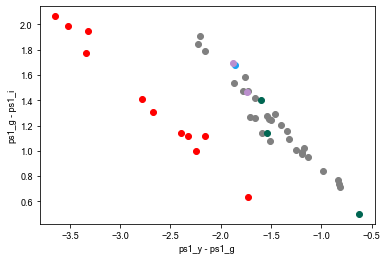

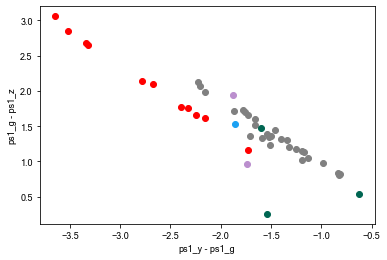

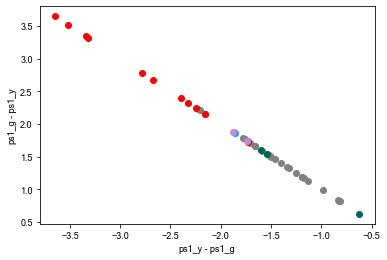

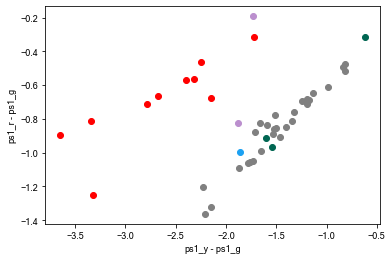

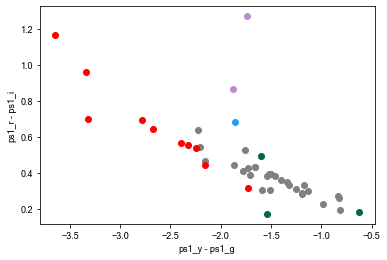

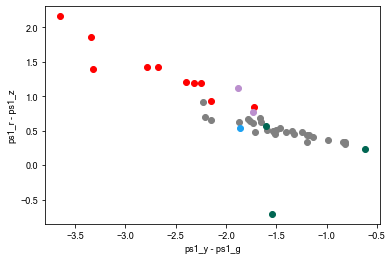

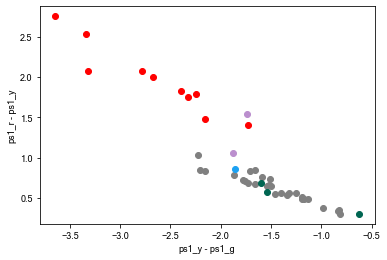

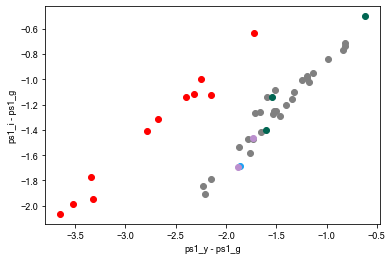

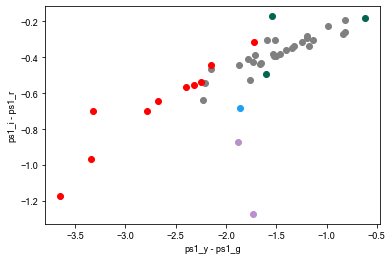

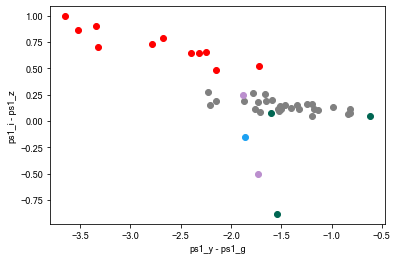

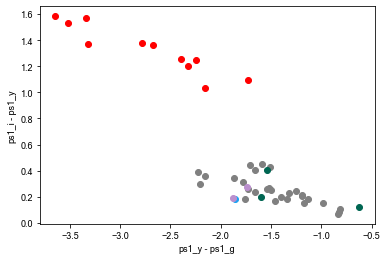

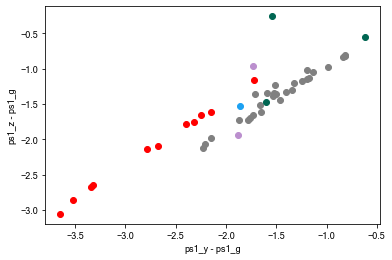

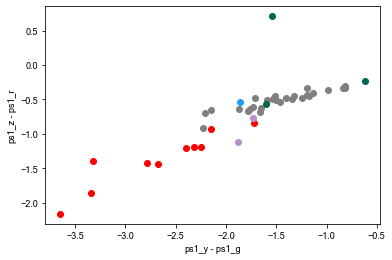

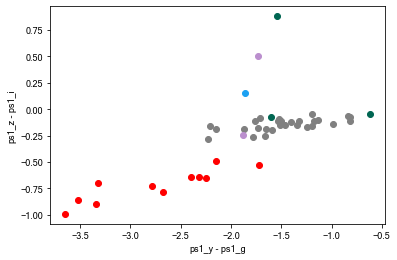

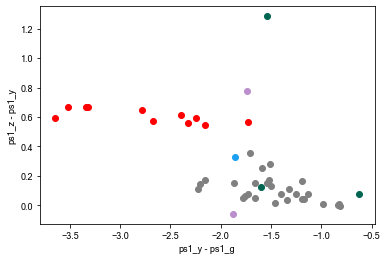

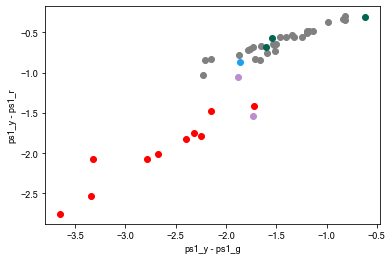

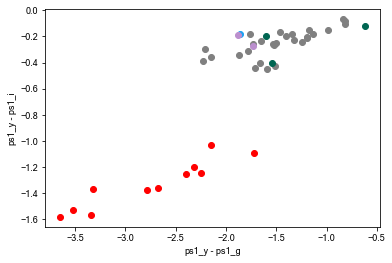

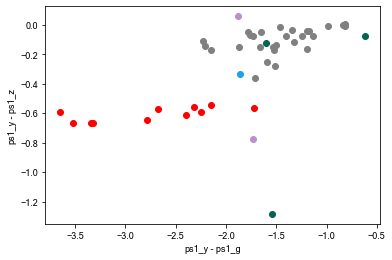

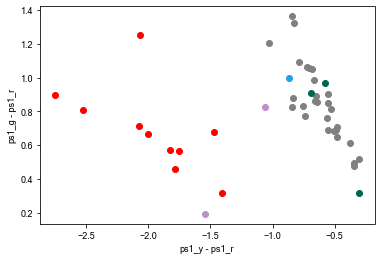

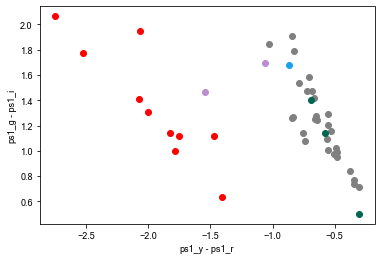

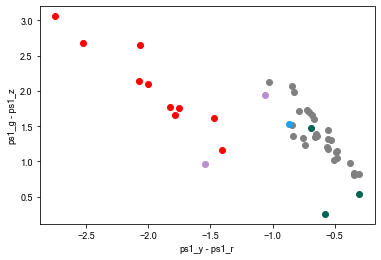

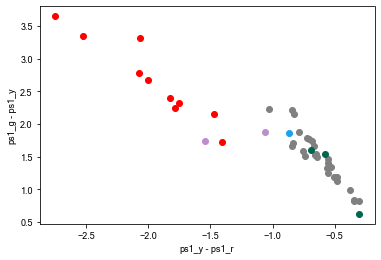

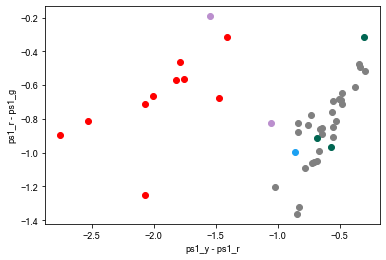

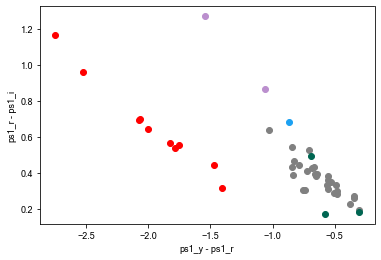

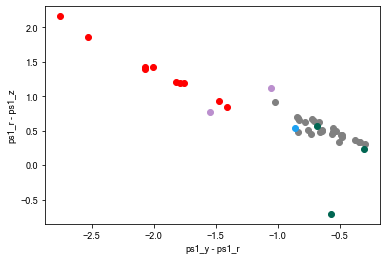

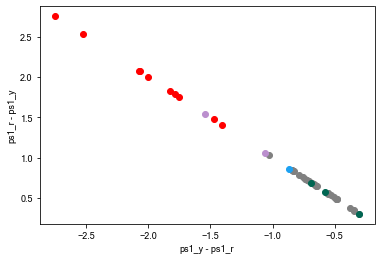

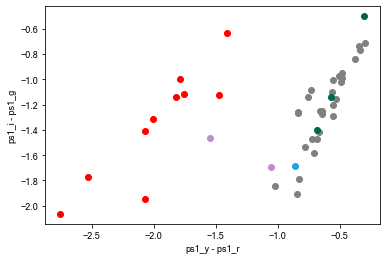

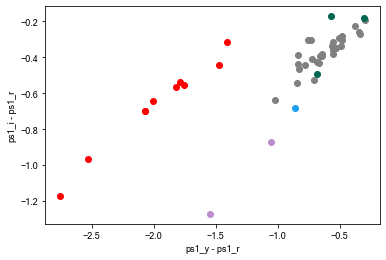

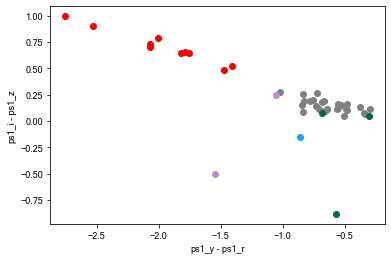

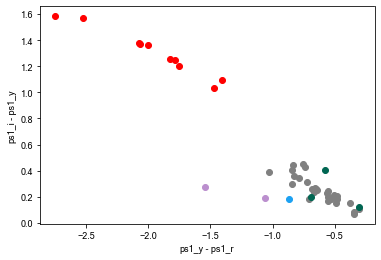

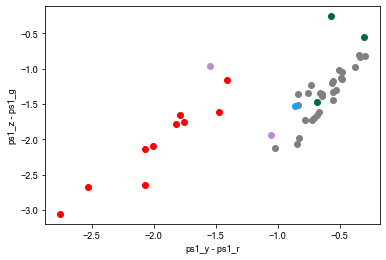

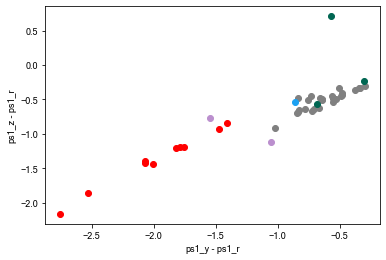

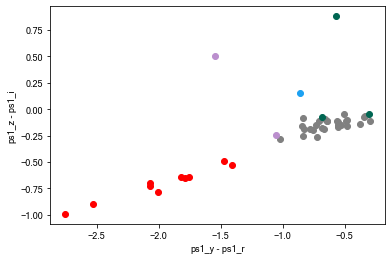

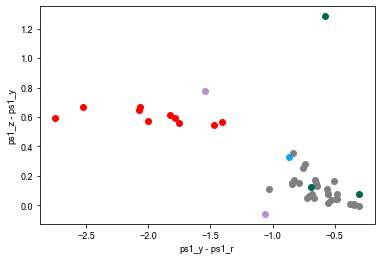

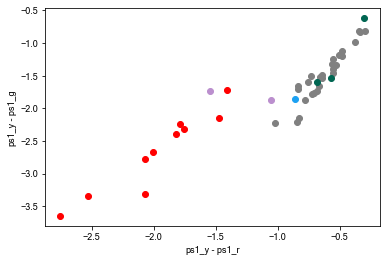

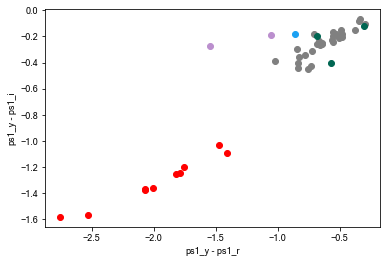

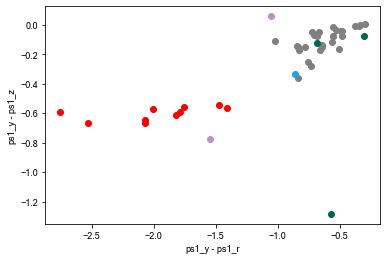

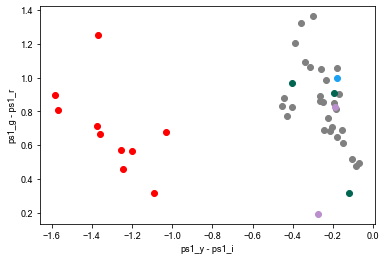

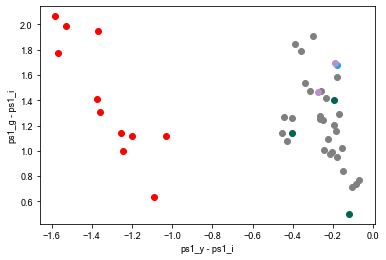

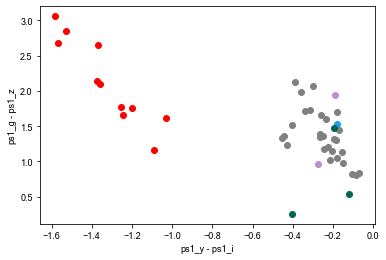

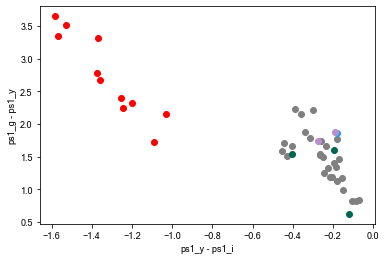

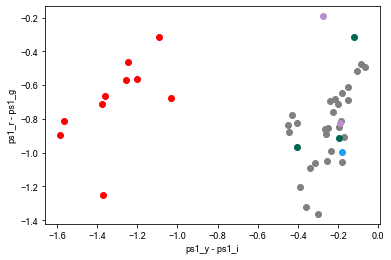

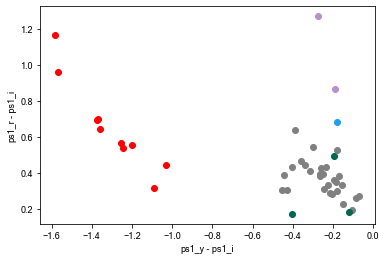

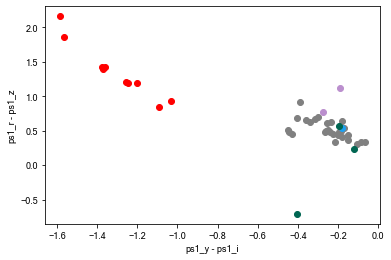

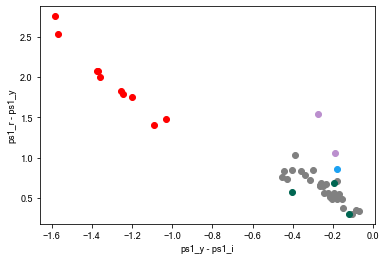

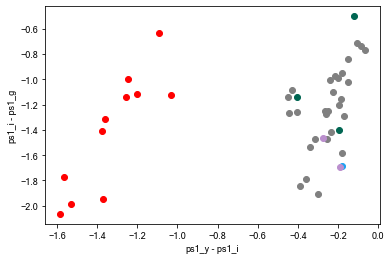

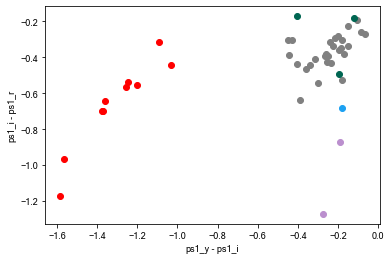

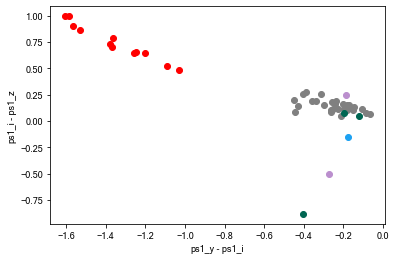

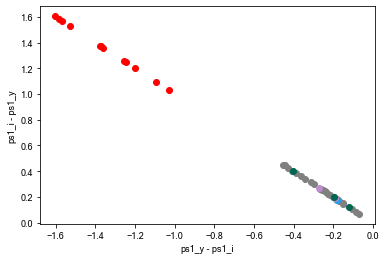

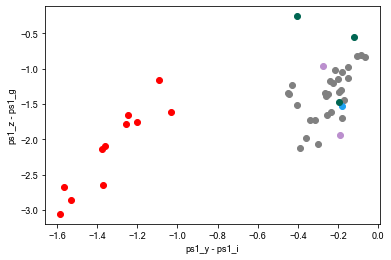

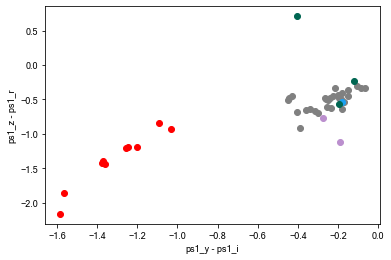

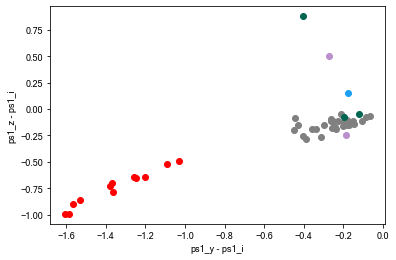

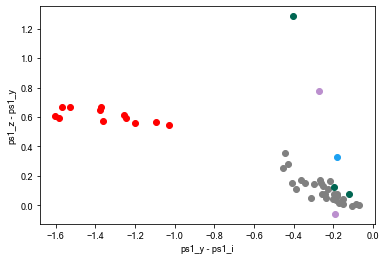

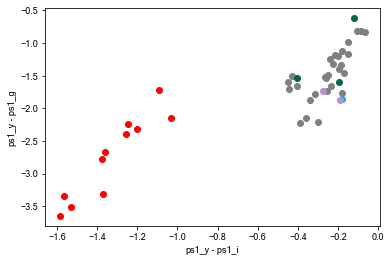

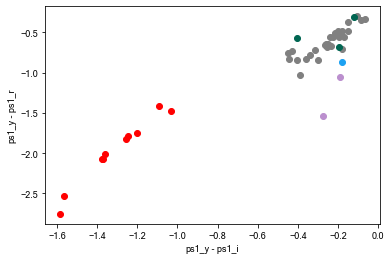

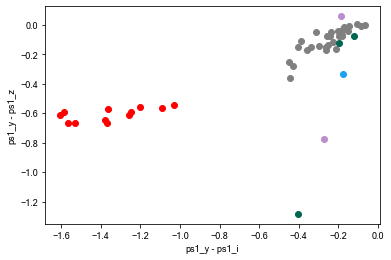

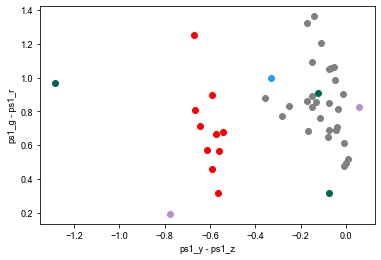

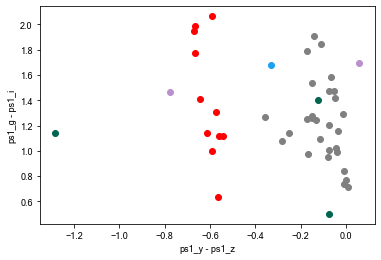

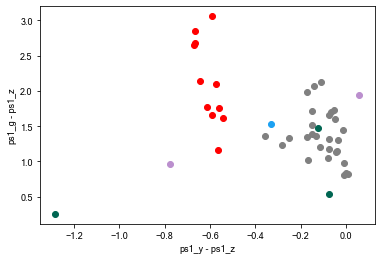

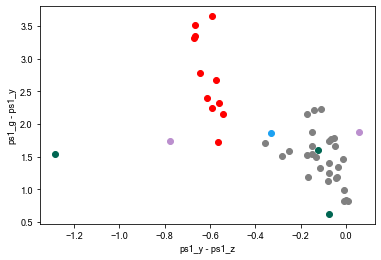

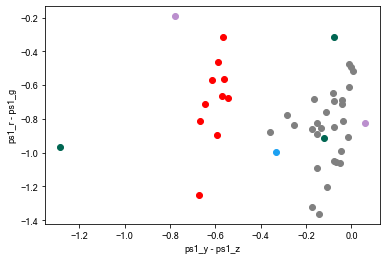

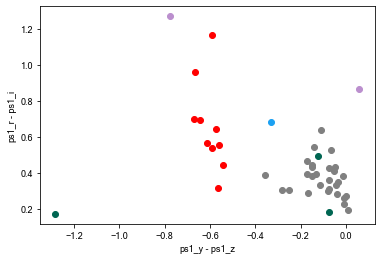

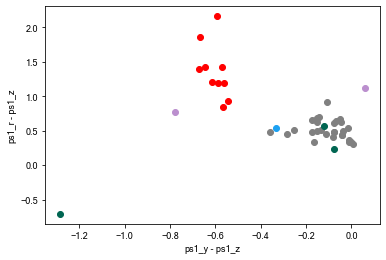

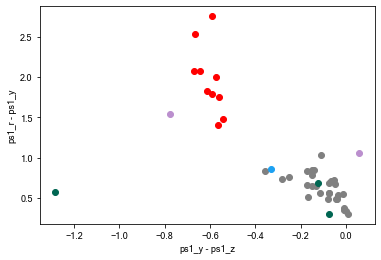

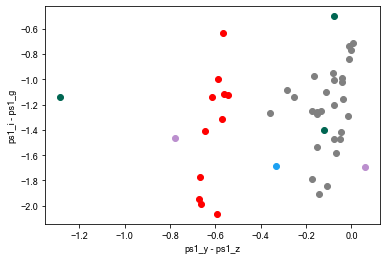

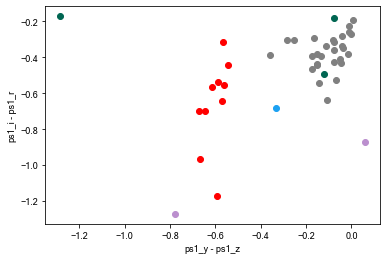

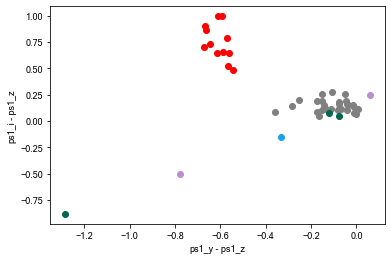

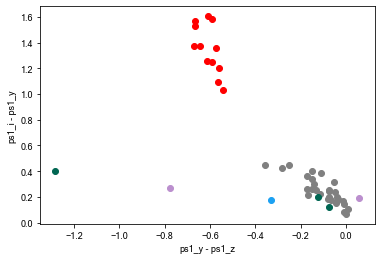

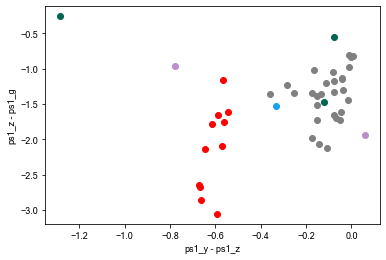

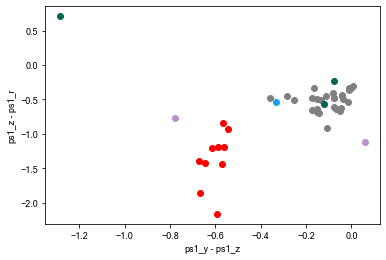

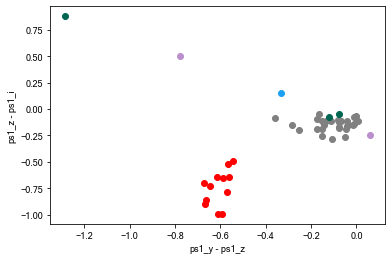

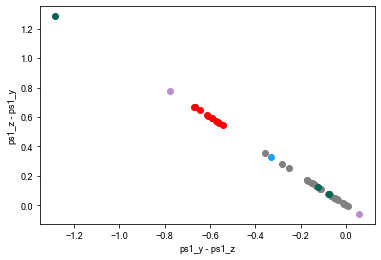

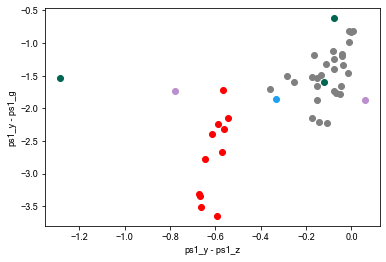

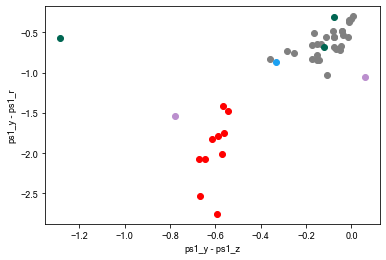

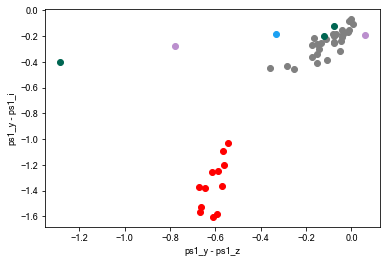

In [20]:
for thing in ps1_super_list:
    for otherthing in ps1_super_list:
        if ((thing[0]==thing[1])or (otherthing[0]==otherthing[1])or (thing==otherthing)):
            pass
        else:
            plot_sp_types(thing,otherthing)

In [21]:
print(ps1_super_list)

[[['g', 'ps1'], ['g', 'ps1']], [['g', 'ps1'], ['r', 'ps1']], [['g', 'ps1'], ['i', 'ps1']], [['g', 'ps1'], ['z', 'ps1']], [['g', 'ps1'], ['y', 'ps1']], [['r', 'ps1'], ['g', 'ps1']], [['r', 'ps1'], ['r', 'ps1']], [['r', 'ps1'], ['i', 'ps1']], [['r', 'ps1'], ['z', 'ps1']], [['r', 'ps1'], ['y', 'ps1']], [['i', 'ps1'], ['g', 'ps1']], [['i', 'ps1'], ['r', 'ps1']], [['i', 'ps1'], ['i', 'ps1']], [['i', 'ps1'], ['z', 'ps1']], [['i', 'ps1'], ['y', 'ps1']], [['z', 'ps1'], ['g', 'ps1']], [['z', 'ps1'], ['r', 'ps1']], [['z', 'ps1'], ['i', 'ps1']], [['z', 'ps1'], ['z', 'ps1']], [['z', 'ps1'], ['y', 'ps1']], [['y', 'ps1'], ['g', 'ps1']], [['y', 'ps1'], ['r', 'ps1']], [['y', 'ps1'], ['i', 'ps1']], [['y', 'ps1'], ['z', 'ps1']], [['y', 'ps1'], ['y', 'ps1']]]


[['u', 'sdss'], ['g', 'sdss'], ['r', 'sdss'], ['i', 'sdss'], ['z', 'sdss']]
[[['u', 'sdss'], ['u', 'sdss']], [['u', 'sdss'], ['g', 'sdss']], [['u', 'sdss'], ['r', 'sdss']], [['u', 'sdss'], ['i', 'sdss']], [['u', 'sdss'], ['z', 'sdss']], [['g', 'sdss'], ['u', 'sdss']], [['g', 'sdss'], ['g', 'sdss']], [['g', 'sdss'], ['r', 'sdss']], [['g', 'sdss'], ['i', 'sdss']], [['g', 'sdss'], ['z', 'sdss']], [['r', 'sdss'], ['u', 'sdss']], [['r', 'sdss'], ['g', 'sdss']], [['r', 'sdss'], ['r', 'sdss']], [['r', 'sdss'], ['i', 'sdss']], [['r', 'sdss'], ['z', 'sdss']], [['i', 'sdss'], ['u', 'sdss']], [['i', 'sdss'], ['g', 'sdss']], [['i', 'sdss'], ['r', 'sdss']], [['i', 'sdss'], ['i', 'sdss']], [['i', 'sdss'], ['z', 'sdss']], [['z', 'sdss'], ['u', 'sdss']], [['z', 'sdss'], ['g', 'sdss']], [['z', 'sdss'], ['r', 'sdss']], [['z', 'sdss'], ['i', 'sdss']], [['z', 'sdss'], ['z', 'sdss']]]
[['u', 'sdss'], ['u', 'sdss']]
[['u', 'sdss'], ['g', 'sdss']]
[['u', 'sdss'], ['r', 'sdss']]
[['u', 'sdss'], ['i', 'sdss']]

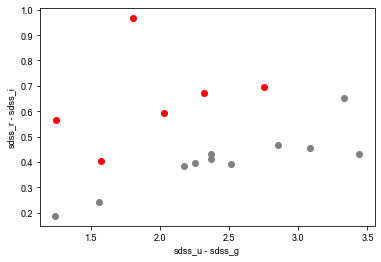

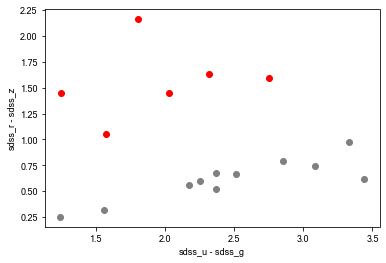

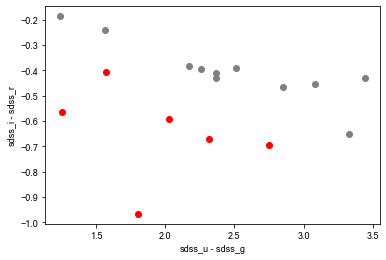

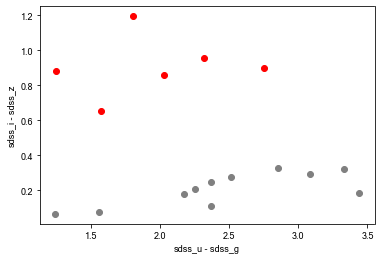

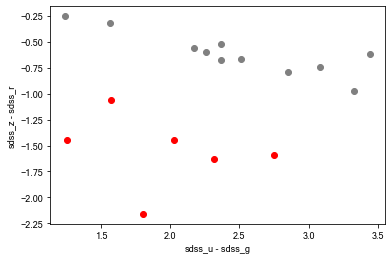

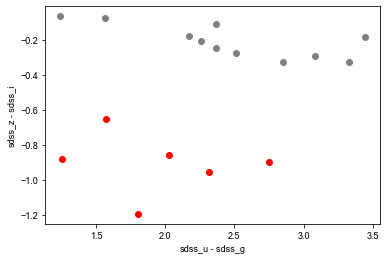

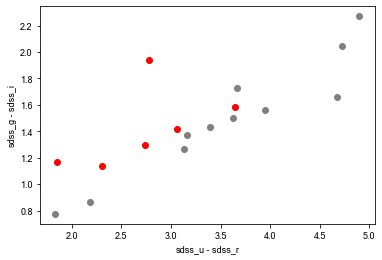

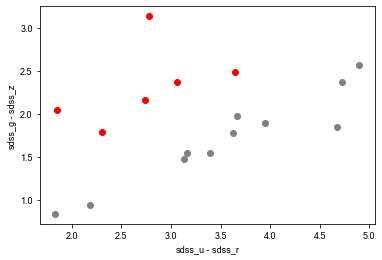

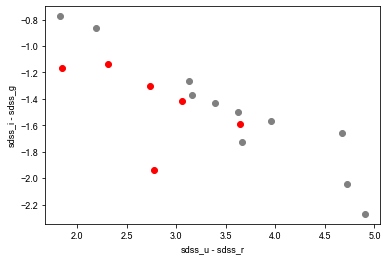

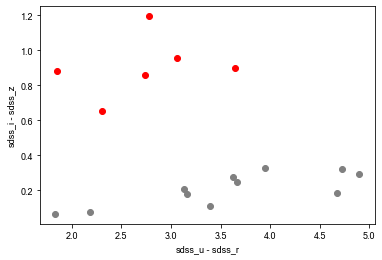

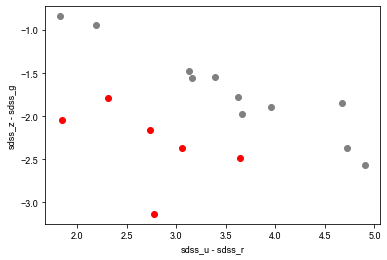

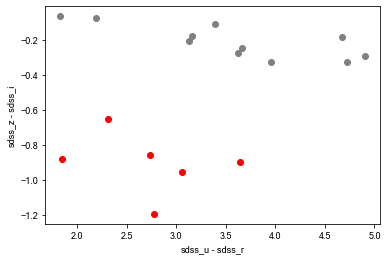

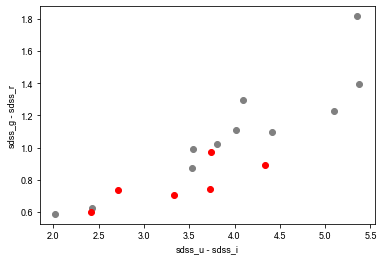

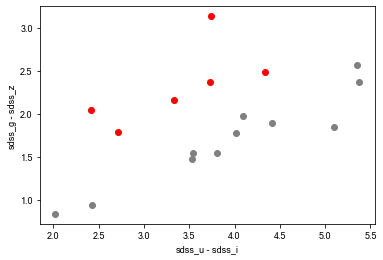

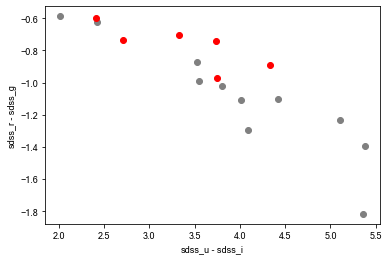

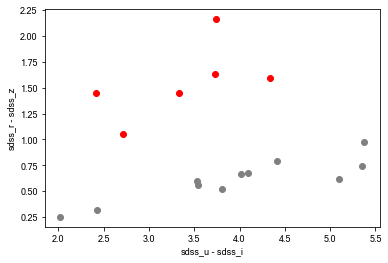

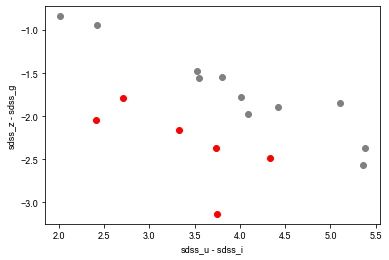

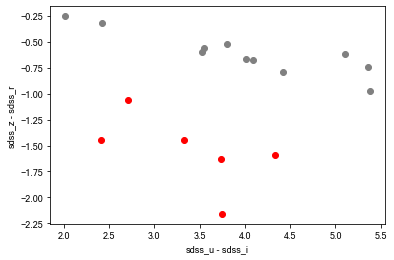

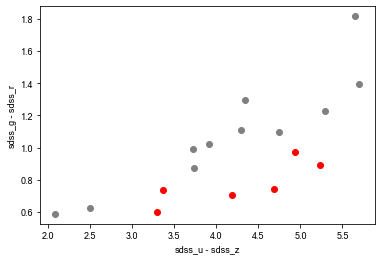

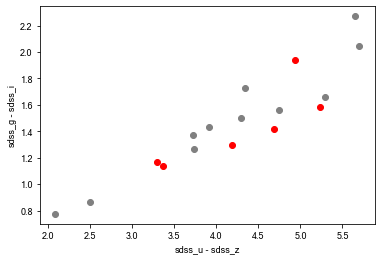

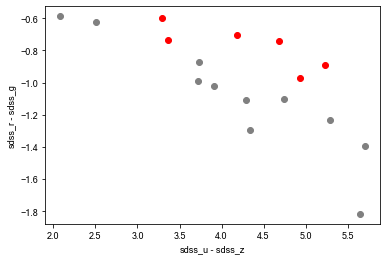

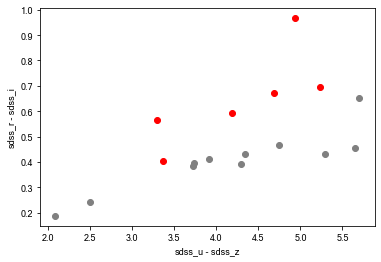

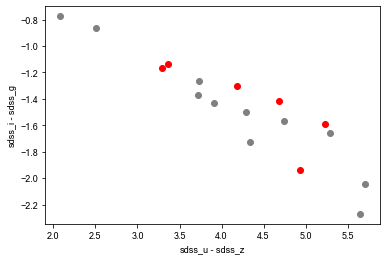

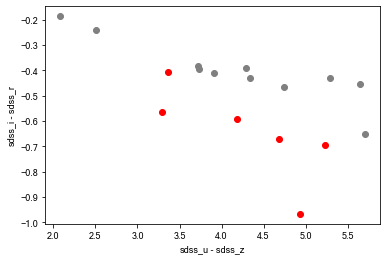

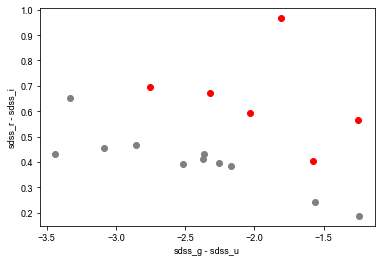

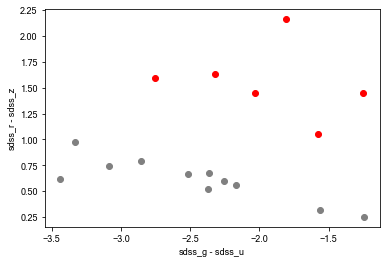

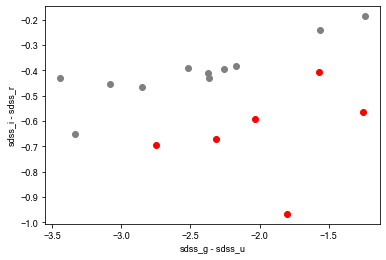

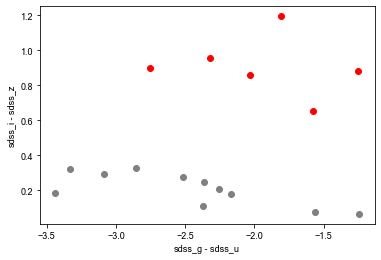

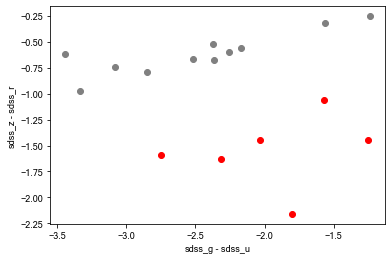

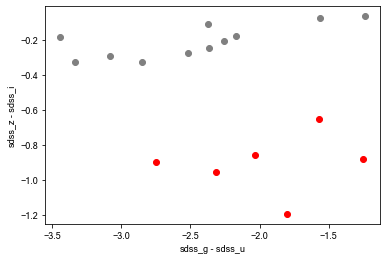

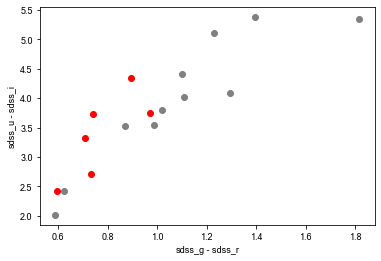

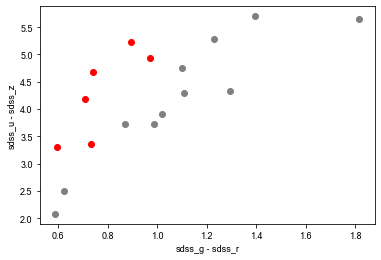

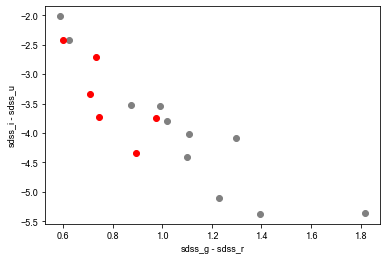

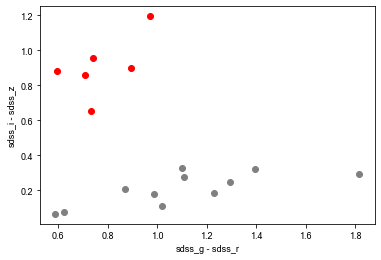

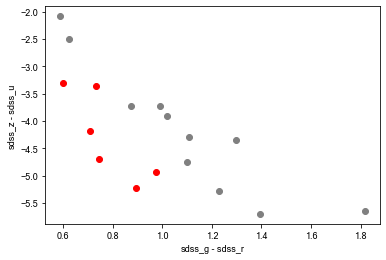

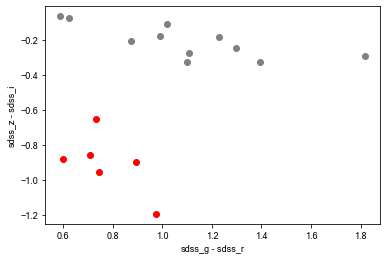

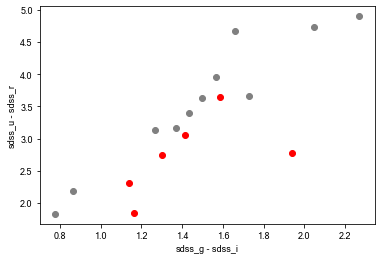

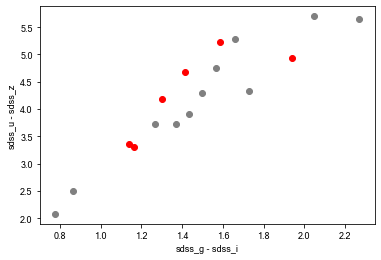

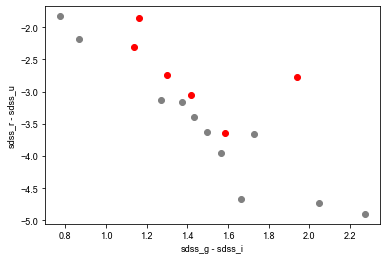

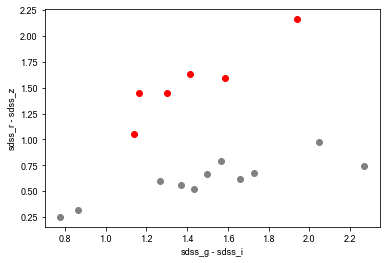

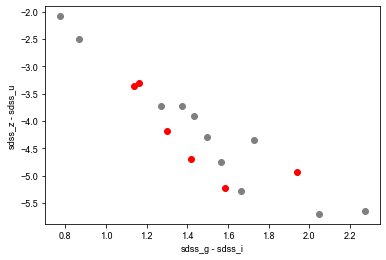

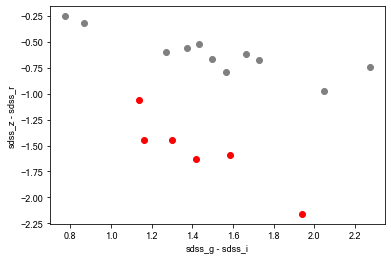

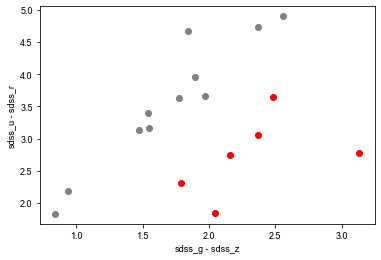

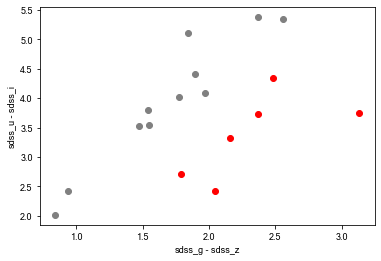

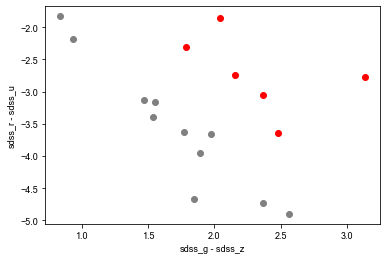

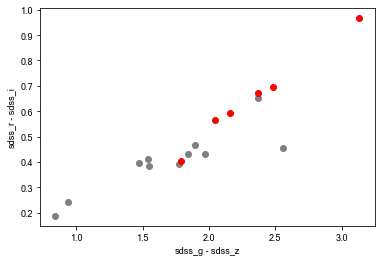

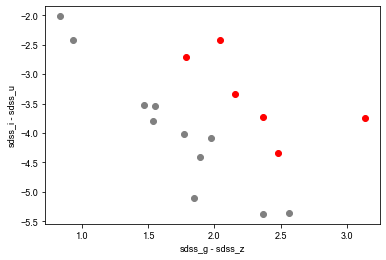

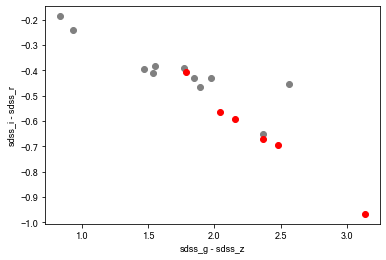

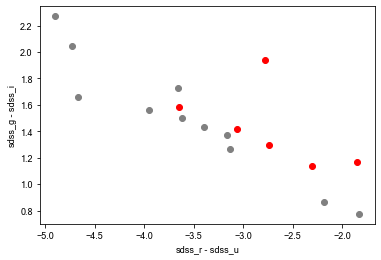

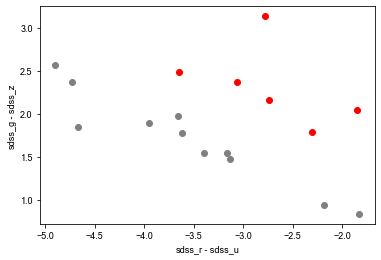

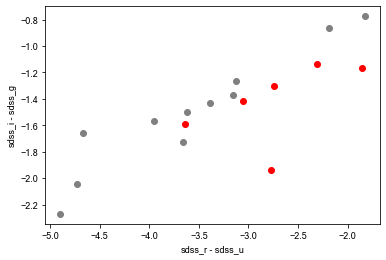

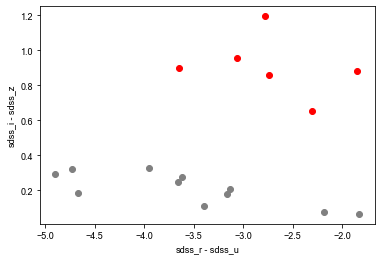

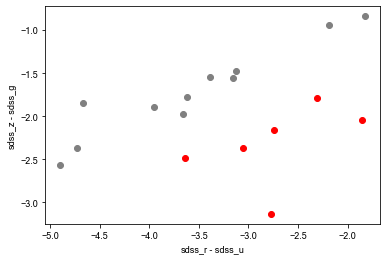

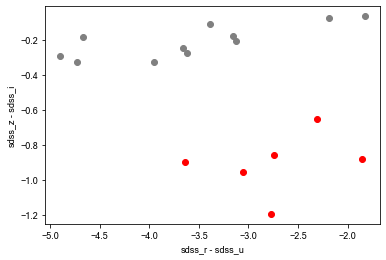

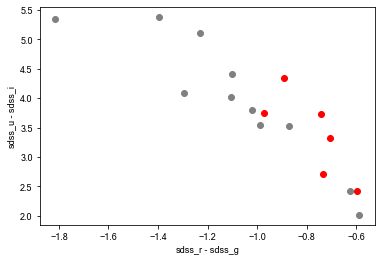

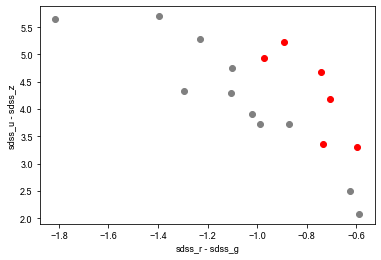

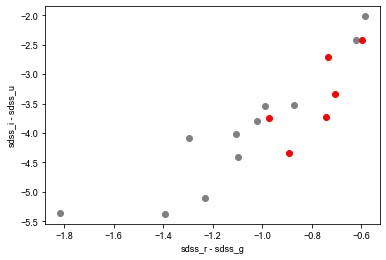

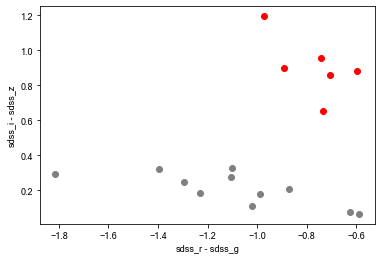

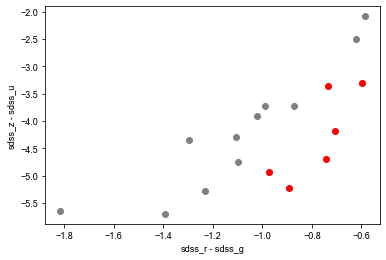

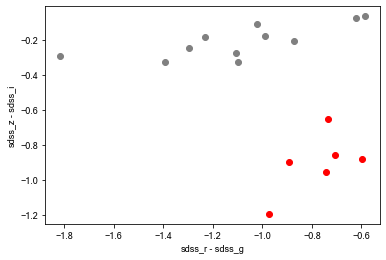

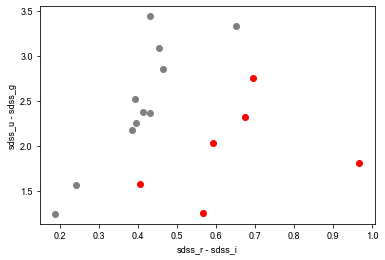

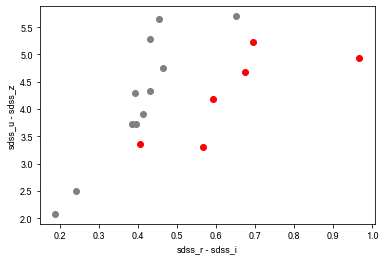

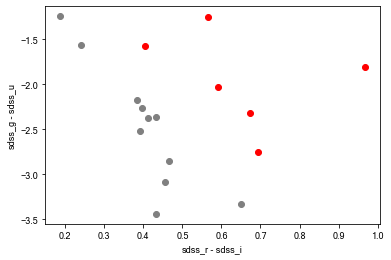

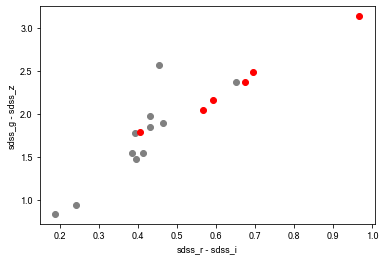

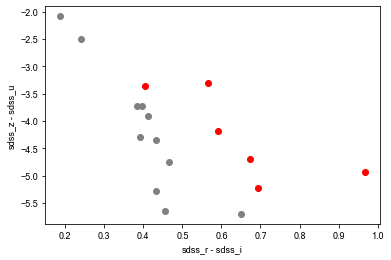

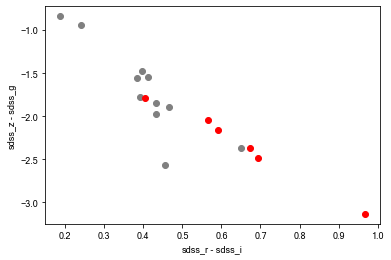

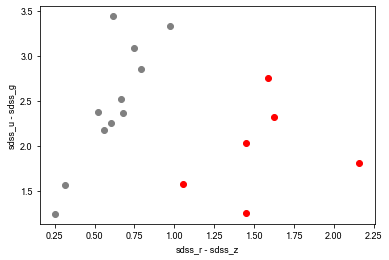

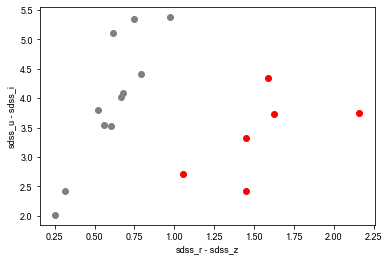

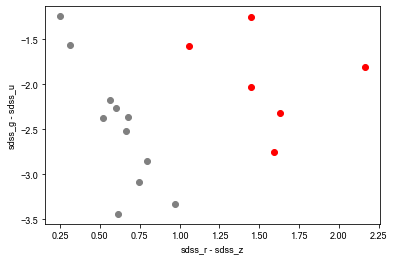

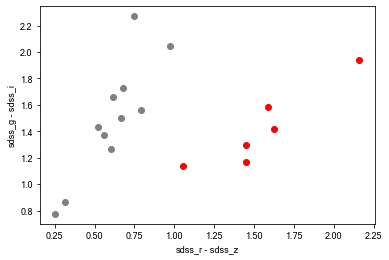

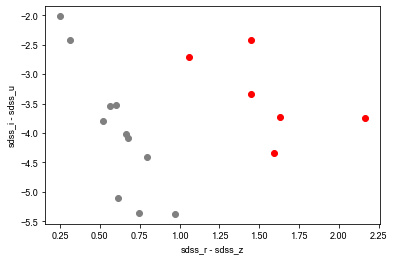

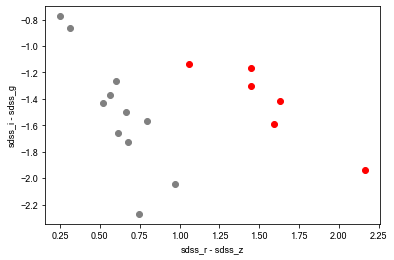

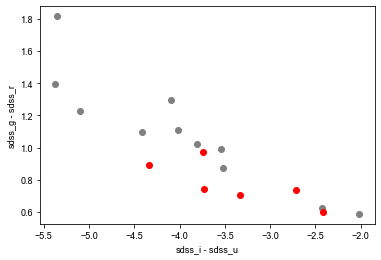

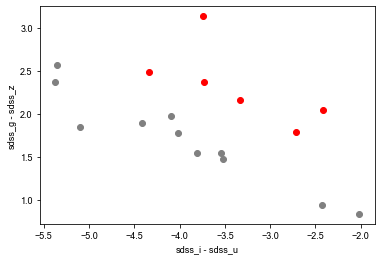

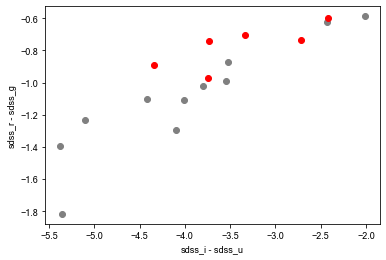

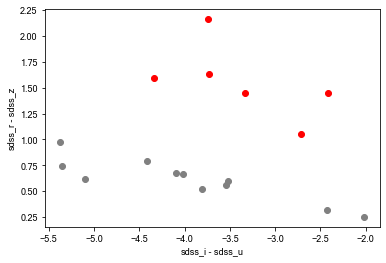

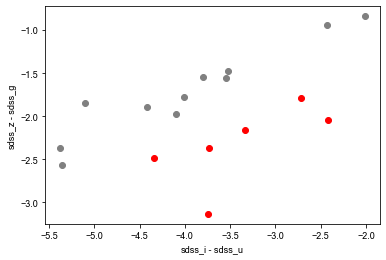

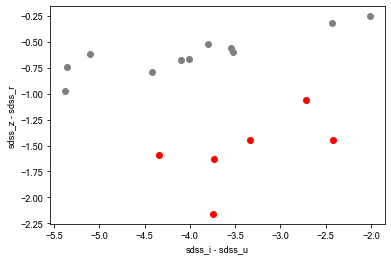

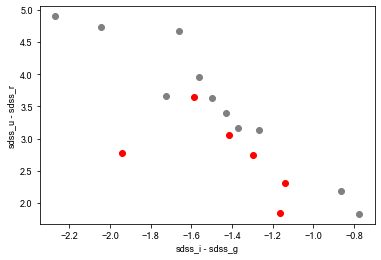

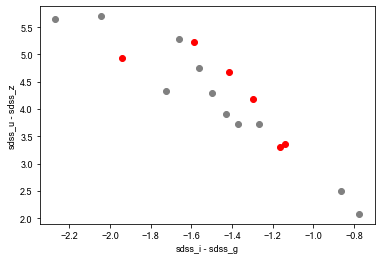

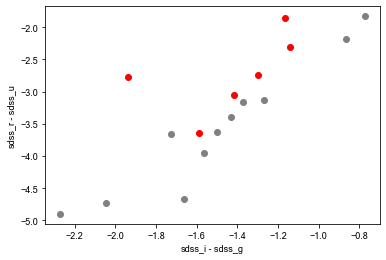

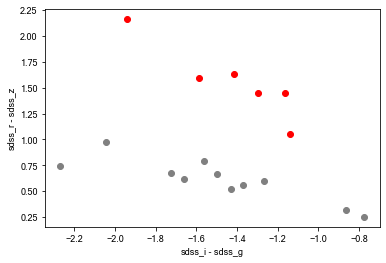

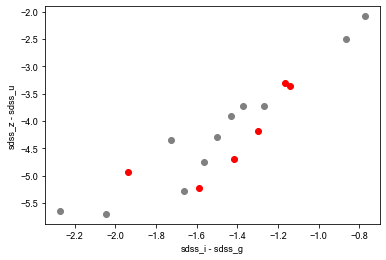

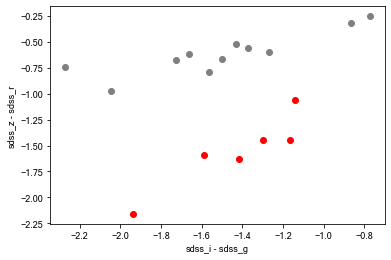

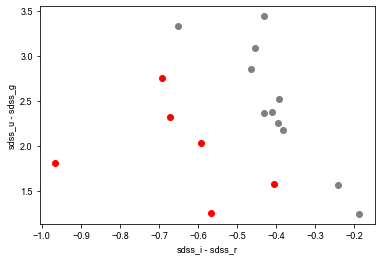

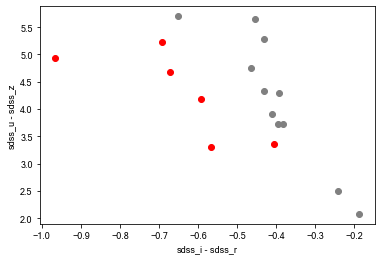

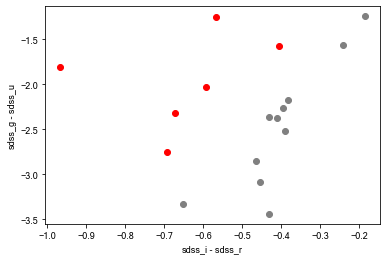

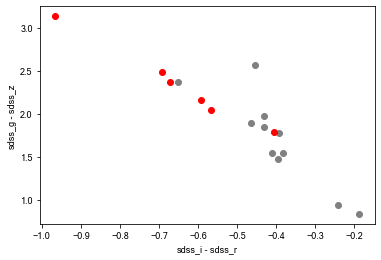

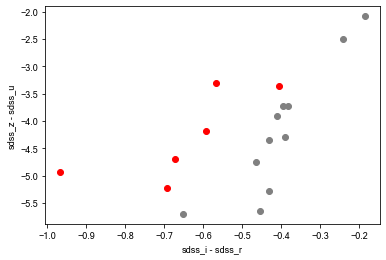

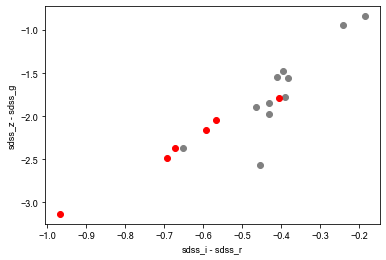

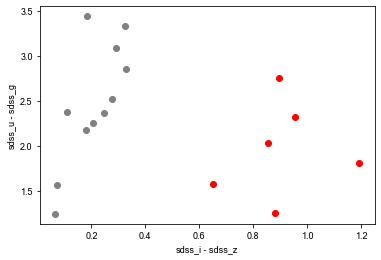

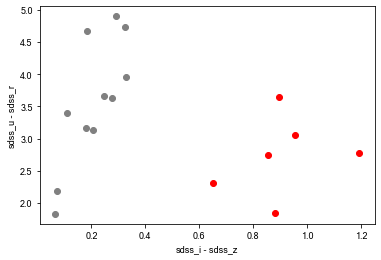

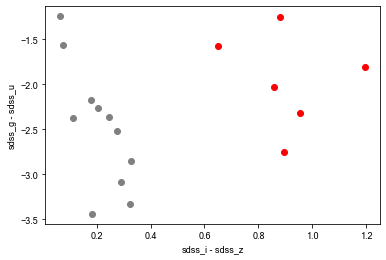

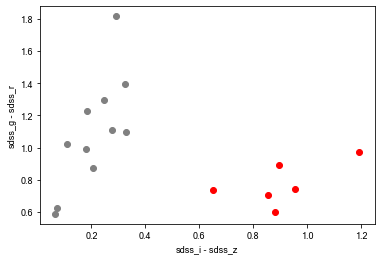

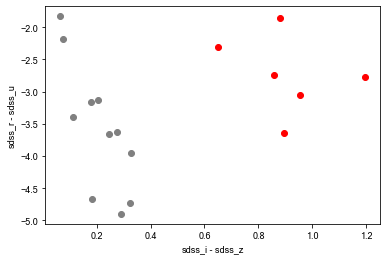

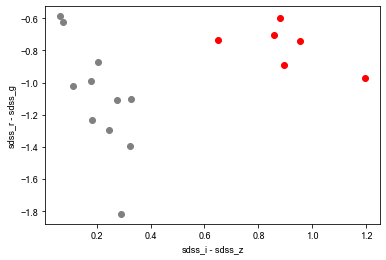

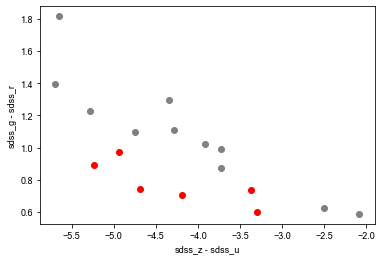

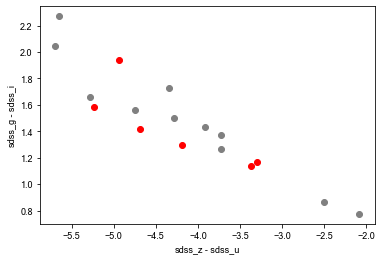

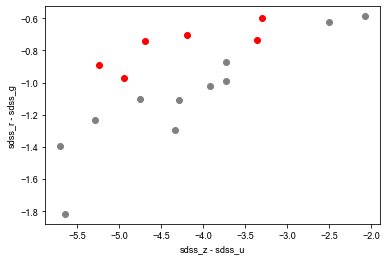

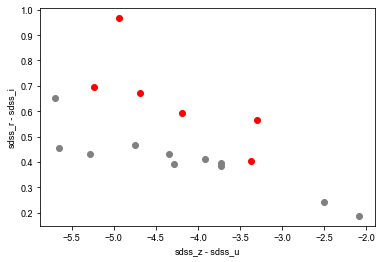

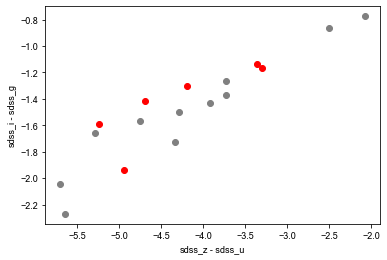

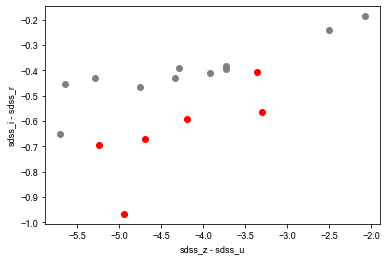

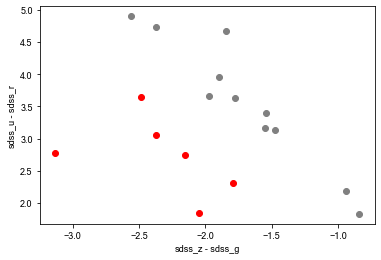

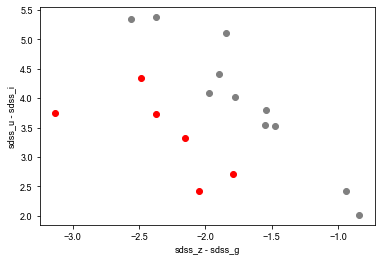

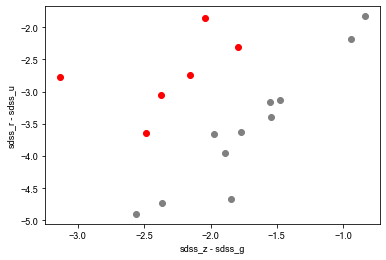

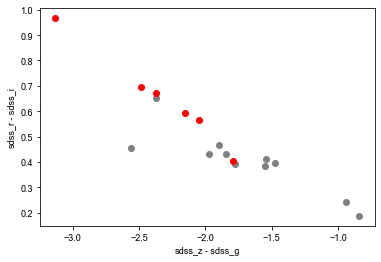

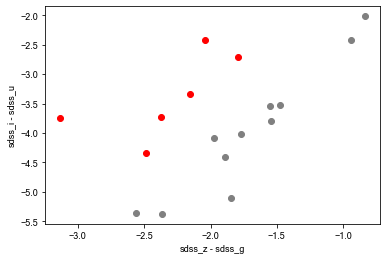

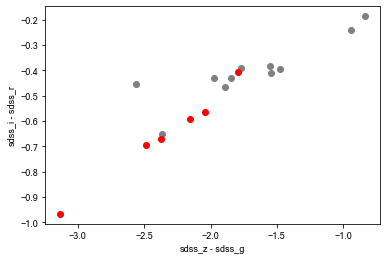

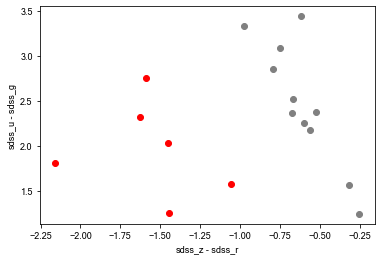

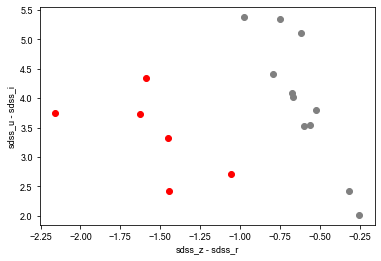

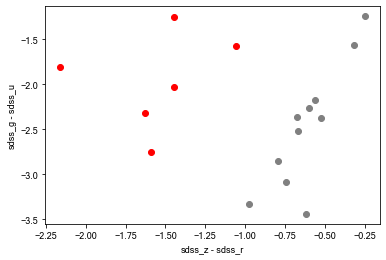

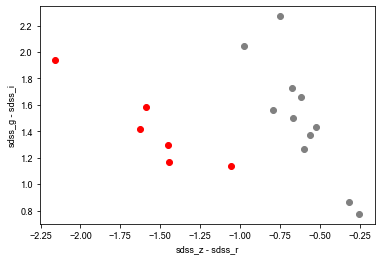

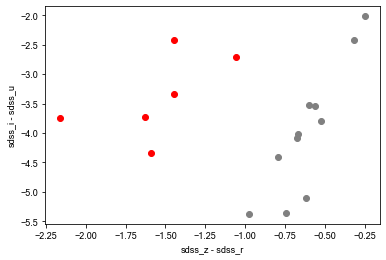

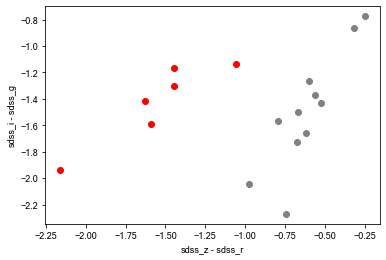

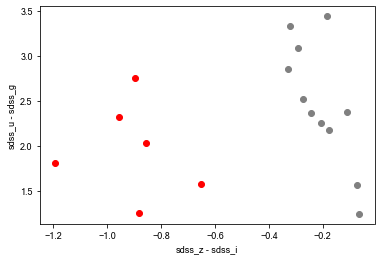

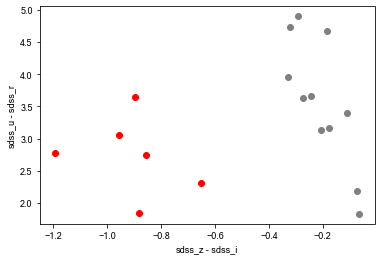

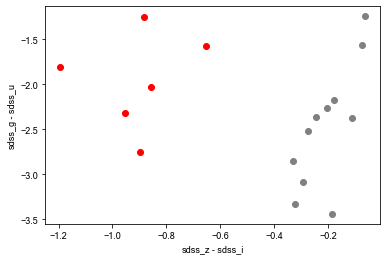

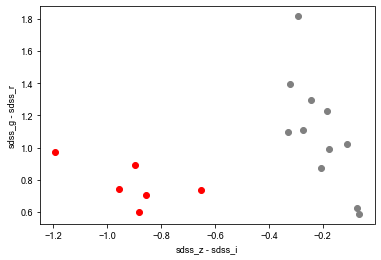

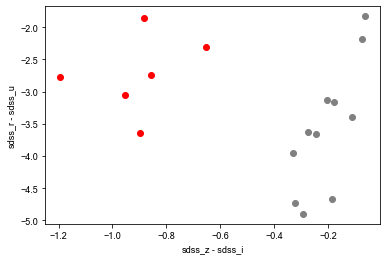

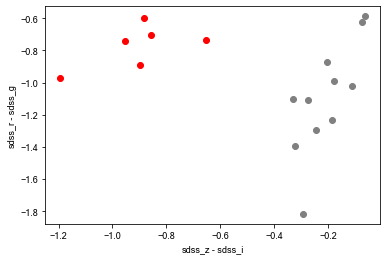

In [22]:
sdss_band_list=['u','g','r','i','z']
sdss_super_list=make_super_list('sdss',sdss_band_list)
for thing in sdss_super_list:
    for otherthing in sdss_super_list:
        if ((thing[0]==thing[1])or (otherthing[0]==otherthing[1])or (thing==otherthing) or (thing[0]in otherthing) or (thing[1] in otherthing)):
            pass
        else:
            plot_sp_types(thing,otherthing)

In [23]:
plot_sp_types([['jap3','vhs'],['hap3','vhs']],[['']])

IndexError: list index out of range